# Q-MedAI Benchmark B — Parkinson's Disease Classification

**SIH 2026 | PS 26139 — Hybrid Quantum Machine Learning Platform for Early Disease Detection**

This notebook is the **higher-dimensional companion benchmark** to the existing Q-MedAI breast-cancer experiment.

## Dataset

UCI **Parkinson's Disease Classification** dataset:

- 756 sustained-vowel recordings
- 252 subjects
- 188 Parkinson's disease subjects
- 64 healthy-control subjects
- 3 recordings per subject
- hundreds of acoustic / speech-derived variables, including MFCC, wavelet, vocal-fold and TQWT features
- target: `class` (`0 = healthy`, `1 = Parkinson's disease`)

Source: UCI Machine Learning Repository, Dataset 470  
DOI: `10.24432/C5MS4X`

## Why this benchmark is harder

The original Q-MedAI breast-cancer benchmark contains only 30 input variables and is already close to performance saturation for classical ML.

This dataset contains **hundreds of acoustic biomarkers**, making it a better test of the SIH architecture:

> high-dimensional biomedical data  
> → leakage-safe classical preprocessing  
> → train-only feature reduction  
> → quantum-compatible representation  
> → classical / VQC / quantum-kernel comparison

## Critical patient-level safeguard

The raw dataset contains **three recordings from each person**.

A naive random row split can put recordings from the same person in both train and test.

To avoid this, this notebook first constructs **one patient-level feature vector per subject** by averaging that subject's repeated acoustic measurements. The target label is verified to be constant within every subject.

Only after this patient-level representation is created do we perform the train/test split.

## Locked experimental hypothesis

This notebook does **not** assume that quantum ML will beat classical ML.

We test whether VQC and a fidelity-based Quantum Kernel SVM can provide competitive or complementary detection performance after reducing the high-dimensional acoustic representation to a fixed six-qubit feature space.

Primary screening-oriented evidence:

- sensitivity / Parkinson recall
- false negatives
- ROC-AUC
- specificity
- F1
- accuracy
- computational cost

`PennyLane default.qubit` is a **classical simulator of quantum circuits**, not physical quantum hardware.

This is a research benchmark and **not a medical diagnostic device or proof of pre-symptomatic diagnosis**.

In [7]:
# ============================================================
# CELL 1 — LOCATE PARKINSON DATASET ON KAGGLE
# Q-MedAI | SIH 2026 | PS 26139
# ============================================================

from pathlib import Path

SEARCH_ROOTS = [
    Path("/kaggle/input"),
    Path.cwd(),
    Path("/kaggle/working"),
]

all_csv = []

for root in SEARCH_ROOTS:
    if root.exists():
        all_csv.extend(root.rglob("*.csv"))

def dataset_score(path):
    name = path.name.lower()
    score = 0

    if name == "pd_speech_features.csv":
        score += 100
    if "parkinson" in name:
        score += 60
    if "pd_speech" in name:
        score += 50
    if "speech" in name and "feature" in name:
        score += 30

    return score

candidate_csv = [
    path for path in all_csv
    if dataset_score(path) > 0
]

candidate_csv = sorted(
    candidate_csv,
    key=lambda path: (
        -dataset_score(path),
        str(path),
    ),
)

if not candidate_csv:
    raise FileNotFoundError(
        "Could not find the Parkinson CSV. "
        "Attach an extracted copy of UCI Dataset 470 "
        "containing pd_speech_features.csv to this Kaggle notebook."
    )

DATASET_PATH = candidate_csv[0]

print("=" * 76)
print("Q-MedAI — PARKINSON DATASET INPUT")
print("=" * 76)
print("Dataset path:", DATASET_PATH)
print()
print("Candidate Parkinson CSV files:")

for path in candidate_csv[:10]:
    print(" -", path)

print()
print("INPUT CHECK PASSED")

Q-MedAI — PARKINSON DATASET INPUT
Dataset path: /kaggle/input/datasets/adityagp7/parkinsons-csv/pd_speech_features.csv

Candidate Parkinson CSV files:
 - /kaggle/input/datasets/adityagp7/parkinsons-csv/pd_speech_features.csv

INPUT CHECK PASSED


In [8]:
# ============================================================
# CELL 2 — DEPENDENCY SETUP + QUANTUM RUNTIME CHECK
# ============================================================

import sys
import subprocess
import importlib
import importlib.util

def ensure_package(import_name, pip_name):
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "--quiet",
                "--disable-pip-version-check",
                pip_name,
            ]
        )
        importlib.invalidate_caches()

ensure_package(
    "pennylane",
    "pennylane==0.45.1",
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import pennylane as qml
from pennylane import numpy as pnp

from IPython.display import display

print("=" * 76)
print("Q-MedAI — RUNTIME VERIFICATION")
print("=" * 76)

print("Python       :", sys.version.split()[0])
print("NumPy        :", np.__version__)
print("Pandas       :", pd.__version__)
print("scikit-learn :", sklearn.__version__)
print("PennyLane    :", qml.__version__)

smoke_device = qml.device(
    "default.qubit",
    wires=2,
)

@qml.qnode(smoke_device)
def smoke_circuit(theta):
    qml.RY(theta, wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.expval(
        qml.PauliZ(0)
    )

smoke_output = float(
    smoke_circuit(0.123)
)

assert np.isfinite(
    smoke_output
)

print()
print(
    "default.qubit output:",
    f"{smoke_output:.8f}",
)

print(
    "Backend: PennyLane default.qubit "
    "(classical simulation of quantum circuits)"
)

print()
print("QUANTUM RUNTIME CHECK PASSED")

Installing missing package: pennylane==0.45.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 111.8 MB/s eta 0:00:00
Q-MedAI — RUNTIME VERIFICATION
Python       : 3.12.13
NumPy        : 2.0.2
Pandas       : 2.3.3
scikit-learn : 1.6.1
PennyLane    : 0.45.1

default.qubit output: 0.99244503
Backend: PennyLane default.qubit (classical simulation of quantum circuits)

QUANTUM RUNTIME CHECK PASSED


In [9]:
# ============================================================
# CELL 3 — LOAD + AUDIT RAW PARKINSON SPEECH DATA
# ============================================================

import numpy as np
import pandas as pd

TARGET_CANDIDATES = [
    "class",
    "status",
    "target",
    "label",
]

SUBJECT_CANDIDATES = [
    "id",
    "subject",
    "subject_id",
    "patient_id",
]

def normalize_columns(frame):
    frame = frame.copy()
    frame.columns = [
        str(column).strip()
        for column in frame.columns
    ]
    return frame

def find_column(frame, candidates):
    lookup = {
        str(column).strip().lower(): column
        for column in frame.columns
    }

    for candidate in candidates:
        if candidate.lower() in lookup:
            return lookup[
                candidate.lower()
            ]

    return None

def load_parkinson_csv(path):
    attempts = []

    # Some copies of the UCI file have a grouped first header row
    # followed by the true variable-name header row.
    for header in [0, 1]:
        try:
            frame = pd.read_csv(
                path,
                header=header,
            )

            frame = normalize_columns(
                frame
            )

            target = find_column(
                frame,
                TARGET_CANDIDATES,
            )

            subject = find_column(
                frame,
                SUBJECT_CANDIDATES,
            )

            attempts.append(
                (
                    header,
                    frame.shape,
                    target,
                    subject,
                )
            )

            if (
                target is not None
                and subject is not None
            ):
                return (
                    frame,
                    target,
                    subject,
                    header,
                )

        except Exception as exc:
            attempts.append(
                (
                    header,
                    "FAILED",
                    type(exc).__name__,
                    str(exc),
                )
            )

    raise ValueError(
        "Could not identify both subject-ID and target columns. "
        f"Attempts: {attempts}"
    )

df_raw, TARGET_COLUMN, SUBJECT_COLUMN, USED_HEADER = (
    load_parkinson_csv(
        DATASET_PATH
    )
)

print("=" * 76)
print("Q-MedAI — RAW DATASET AUDIT")
print("=" * 76)

print("CSV header row used :", USED_HEADER)
print("Raw shape           :", df_raw.shape)
print("Subject column      :", SUBJECT_COLUMN)
print("Target column       :", TARGET_COLUMN)

# ------------------------------------------------------------
# Target cleanup
# ------------------------------------------------------------

y_raw = pd.to_numeric(
    df_raw[
        TARGET_COLUMN
    ],
    errors="coerce",
)

if y_raw.isna().any():
    raise ValueError(
        "Target column contains non-numeric values "
        "after parsing."
    )

y_raw = y_raw.astype(int)

if set(
    y_raw.unique()
) != {0, 1}:
    raise ValueError(
        "Expected binary target encoded as 0/1. "
        f"Observed: {sorted(y_raw.unique())}"
    )

df_raw[
    TARGET_COLUMN
] = y_raw

# ------------------------------------------------------------
# Subject-ID checks
# ------------------------------------------------------------

subject_ids_raw = (
    df_raw[
        SUBJECT_COLUMN
    ]
    .astype(str)
)

unique_subjects = (
    subject_ids_raw
    .nunique()
)

recordings_per_subject = (
    pd.Series(
        subject_ids_raw
    )
    .value_counts()
)

# Every subject must have one stable diagnosis label.
label_counts_per_subject = (
    df_raw
    .assign(
        __subject_id__=subject_ids_raw
    )
    .groupby(
        "__subject_id__"
    )[
        TARGET_COLUMN
    ]
    .nunique()
)

assert (
    label_counts_per_subject.max()
    == 1
), (
    "At least one subject has inconsistent "
    "diagnosis labels across recordings."
)

print()
print("Unique subjects      :", unique_subjects)
print(
    "Recordings / subject :",
    recordings_per_subject
    .value_counts()
    .sort_index()
    .to_dict(),
)

print(
    "Recording-level class distribution:",
    df_raw[
        TARGET_COLUMN
    ]
    .value_counts()
    .sort_index()
    .to_dict(),
)

subject_labels_audit = (
    df_raw
    .assign(
        __subject_id__=subject_ids_raw
    )
    .groupby(
        "__subject_id__"
    )[
        TARGET_COLUMN
    ]
    .first()
)

print(
    "Subject-level class distribution  :",
    subject_labels_audit
    .value_counts()
    .sort_index()
    .to_dict(),
)

print()
print("UCI reference expectations:")
print(" - approximately 756 recordings")
print(" - approximately 252 subjects")
print(" - three recordings per subject")
print(" - hundreds of speech/acoustic variables")

if len(df_raw) != 756:
    print(
        "WARNING: This CSV does not contain exactly "
        "756 recordings. Continue only if this is an "
        "intentional derivative of the UCI dataset."
    )

if unique_subjects != 252:
    print(
        "WARNING: This CSV does not contain exactly "
        "252 unique subjects."
    )

print()
display(
    df_raw.head()
)

print()
print("RAW DATASET VALIDATION PASSED")

Q-MedAI — RAW DATASET AUDIT
CSV header row used : 1
Raw shape           : (756, 755)
Subject column      : id
Target column       : class

Unique subjects      : 252
Recordings / subject : {3: 252}
Recording-level class distribution: {0: 192, 1: 564}
Subject-level class distribution  : {0: 64, 1: 188}

UCI reference expectations:
 - approximately 756 recordings
 - approximately 252 subjects
 - three recordings per subject
 - hundreds of speech/acoustic variables



,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1



RAW DATASET VALIDATION PASSED


In [10]:
# ============================================================
# CELL 4 — BUILD ONE PATIENT-LEVEL ROW PER SUBJECT
# ============================================================

import numpy as np
import pandas as pd

# We exclude gender by default so the benchmark focuses on
# acoustic biomarkers rather than demographic shortcuts.
EXCLUDE_DEMOGRAPHICS = True

exclude_columns = {
    SUBJECT_COLUMN,
    TARGET_COLUMN,
}

gender_column = find_column(
    df_raw,
    ["gender", "sex"],
)

if (
    EXCLUDE_DEMOGRAPHICS
    and gender_column is not None
):
    exclude_columns.add(
        gender_column
    )

candidate_feature_columns = [
    column
    for column in df_raw.columns
    if column not in exclude_columns
]

numeric_features = (
    df_raw[
        candidate_feature_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
)

# Remove columns that contain no usable numeric information.
usable_feature_columns = [
    column
    for column in numeric_features.columns
    if numeric_features[
        column
    ].notna().any()
]

numeric_features = numeric_features[
    usable_feature_columns
]

working = numeric_features.copy()

working[
    "__subject_id__"
] = (
    df_raw[
        SUBJECT_COLUMN
    ]
    .astype(str)
    .values
)

working[
    "__target__"
] = (
    df_raw[
        TARGET_COLUMN
    ]
    .astype(int)
    .values
)

# ------------------------------------------------------------
# Patient-level aggregation
#
# Each subject's three repeated voice measurements are averaged.
# This happens WITHIN subject only; no information is shared
# between subjects.
# ------------------------------------------------------------

feature_means = (
    working
    .groupby(
        "__subject_id__"
    )[
        usable_feature_columns
    ]
    .mean()
)

subject_targets = (
    working
    .groupby(
        "__subject_id__"
    )[
        "__target__"
    ]
    .first()
)

subject_df = (
    feature_means
    .copy()
)

subject_df[
    "__target__"
] = (
    subject_targets
)

subject_df = (
    subject_df
    .reset_index()
)

SUBJECT_ID_FINAL = (
    "__subject_id__"
)

TARGET_FINAL = (
    "__target__"
)

subject_feature_columns = [
    column
    for column in subject_df.columns
    if column not in {
        SUBJECT_ID_FINAL,
        TARGET_FINAL,
    }
]

print("=" * 76)
print("Q-MedAI — PATIENT-LEVEL DATASET")
print("=" * 76)

print(
    "Raw recording rows        :",
    len(
        df_raw
    ),
)

print(
    "Independent subject rows  :",
    len(
        subject_df
    ),
)

print(
    "Acoustic predictors       :",
    len(
        subject_feature_columns
    ),
)

print(
    "Target distribution       :",
    subject_df[
        TARGET_FINAL
    ]
    .value_counts()
    .sort_index()
    .to_dict(),
)

if (
    EXCLUDE_DEMOGRAPHICS
    and gender_column is not None
):
    print(
        "Excluded demographic col :",
        gender_column,
    )

assert (
    subject_df[
        SUBJECT_ID_FINAL
    ]
    .nunique()
    == len(
        subject_df
    )
)

assert set(
    subject_df[
        TARGET_FINAL
    ]
    .unique()
) == {0, 1}

assert (
    len(
        subject_feature_columns
    )
    >= 700
), (
    "Expected a high-dimensional Parkinson "
    "speech feature representation."
)

print()
print(
    "PATIENT-LEVEL AGGREGATION PASSED"
)
print(
    "Each person now appears exactly once "
    "before train/test splitting."
)

Q-MedAI — PATIENT-LEVEL DATASET
Raw recording rows        : 756
Independent subject rows  : 252
Acoustic predictors       : 752
Target distribution       : {0: 64, 1: 188}
Excluded demographic col : gender

PATIENT-LEVEL AGGREGATION PASSED
Each person now appears exactly once before train/test splitting.


In [11]:
# ============================================================
# CELL 5 — SUBJECT-LEVEL SPLIT + EXPERIMENT PROFILE
# ============================================================

from sklearn.model_selection import (
    train_test_split,
)

RANDOM_SEED = 42
TEST_SIZE = 0.20

PROFILE = "PARKINSON_SAFE_V1"

CFG = {
    "feature_count": 6,
    "matched_train_size": 100,
    "vqc_layers": 2,
    "vqc_iterations": 40,
    "vqc_batch_size": 20,
    "vqc_learning_rate": 0.03,
    "vqc_timeout_seconds": 240,
    "kernel_timeout_seconds": 300,
}

X_subject = (
    subject_df[
        subject_feature_columns
    ]
    .copy()
)

y_subject = (
    subject_df[
        TARGET_FINAL
    ]
    .astype(int)
    .copy()
)

subject_identity = (
    subject_df[
        SUBJECT_ID_FINAL
    ]
    .astype(str)
    .copy()
)

(
    train_indices,
    test_indices,
) = train_test_split(
    np.arange(
        len(
            subject_df
        )
    ),
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_subject,
)

X_train_raw = (
    X_subject.iloc[
        train_indices
    ]
    .reset_index(
        drop=True
    )
)

X_test_raw = (
    X_subject.iloc[
        test_indices
    ]
    .reset_index(
        drop=True
    )
)

y_train = (
    y_subject.iloc[
        train_indices
    ]
    .reset_index(
        drop=True
    )
)

y_test = (
    y_subject.iloc[
        test_indices
    ]
    .reset_index(
        drop=True
    )
)

train_subject_ids = (
    subject_identity.iloc[
        train_indices
    ]
    .reset_index(
        drop=True
    )
)

test_subject_ids = (
    subject_identity.iloc[
        test_indices
    ]
    .reset_index(
        drop=True
    )
)

subject_overlap = set(
    train_subject_ids
).intersection(
    set(
        test_subject_ids
    )
)

assert not subject_overlap

print("=" * 76)
print("Q-MedAI — LOCKED PARKINSON EXPERIMENT PROFILE")
print("=" * 76)

print("Profile             :", PROFILE)
print("Random seed         :", RANDOM_SEED)
print("Subject train rows  :", len(y_train))
print("Subject test rows   :", len(y_test))
print(
    "Train distribution  :",
    y_train
    .value_counts()
    .sort_index()
    .to_dict(),
)
print(
    "Test distribution   :",
    y_test
    .value_counts()
    .sort_index()
    .to_dict(),
)
print("Subject overlap     :", len(subject_overlap))
print("Selected features   :", CFG["feature_count"])
print("Qubits              :", CFG["feature_count"])
print("Matched train rows  :", CFG["matched_train_size"])
print("VQC layers          :", CFG["vqc_layers"])
print("VQC iterations      :", CFG["vqc_iterations"])

print()
print("SUBJECT-LEVEL SPLIT PASSED")

Q-MedAI — LOCKED PARKINSON EXPERIMENT PROFILE
Profile             : PARKINSON_SAFE_V1
Random seed         : 42
Subject train rows  : 201
Subject test rows   : 51
Train distribution  : {0: 51, 1: 150}
Test distribution   : {0: 13, 1: 38}
Subject overlap     : 0
Selected features   : 6
Qubits              : 6
Matched train rows  : 100
VQC layers          : 2
VQC iterations      : 40

SUBJECT-LEVEL SPLIT PASSED


In [12]:
# ============================================================
# CELL 6 — LEAKAGE-SAFE PREPROCESSING + MATCHED CONDITION
# ============================================================

from dataclasses import dataclass

from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
)
from sklearn.feature_selection import (
    VarianceThreshold,
)
from sklearn.impute import (
    SimpleImputer,
)
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
)

RESULTS_DIR = Path(
    "/kaggle/working/Q-MedAI-Parkinson/results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

@dataclass
class PreprocessorBundle:
    feature_names_in: list
    imputer: object
    variance_filter: object
    scaler: object
    selector: object
    quantum_scaler: object
    feature_names_after_variance: list
    feature_names_out: list

    def transform_classical(self, X):
        X_ordered = X[
            self.feature_names_in
        ]

        X_imp = self.imputer.transform(
            X_ordered
        )

        X_var = self.variance_filter.transform(
            X_imp
        )

        X_scaled = self.scaler.transform(
            X_var
        )

        return self.selector.transform(
            X_scaled
        )

    def transform_quantum(self, X):
        X_reduced = self.transform_classical(
            X
        )

        return self.quantum_scaler.transform(
            X_reduced
        )

def fit_preprocessor(
    X_train_frame,
    y_train_series,
    feature_count,
):
    feature_names = list(
        X_train_frame.columns
    )

    imputer = SimpleImputer(
        strategy="median"
    )

    X_imp = imputer.fit_transform(
        X_train_frame
    )

    variance_filter = VarianceThreshold(
        threshold=0.0
    )

    X_var = variance_filter.fit_transform(
        X_imp
    )

    feature_names_after_variance = (
        np.asarray(
            feature_names,
            dtype=object,
        )[
            variance_filter.get_support()
        ]
        .tolist()
    )

    if X_var.shape[1] < feature_count:
        raise ValueError(
            "Not enough non-constant features for "
            f"k={feature_count}."
        )

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(
        X_var
    )

    selector = SelectKBest(
        score_func=f_classif,
        k=feature_count,
    )

    X_reduced = selector.fit_transform(
        X_scaled,
        np.asarray(
            y_train_series,
            dtype=int,
        ),
    )

    selected_names = (
        np.asarray(
            feature_names_after_variance,
            dtype=object,
        )[
            selector.get_support()
        ]
        .tolist()
    )

    quantum_scaler = MinMaxScaler(
        feature_range=(
            -np.pi,
            np.pi,
        ),
        clip=True,
    )

    quantum_scaler.fit(
        X_reduced
    )

    return PreprocessorBundle(
        feature_names_in=feature_names,
        imputer=imputer,
        variance_filter=variance_filter,
        scaler=scaler,
        selector=selector,
        quantum_scaler=quantum_scaler,
        feature_names_after_variance=(
            feature_names_after_variance
        ),
        feature_names_out=selected_names,
    )

# ------------------------------------------------------------
# Full-data classical preprocessing
# ------------------------------------------------------------

full_preprocessor = fit_preprocessor(
    X_train_raw,
    y_train,
    CFG[
        "feature_count"
    ],
)

X_train_full = (
    full_preprocessor
    .transform_classical(
        X_train_raw
    )
)

X_test_full = (
    full_preprocessor
    .transform_classical(
        X_test_raw
    )
)

# ------------------------------------------------------------
# Matched 100-subject training condition
#
# The subset is drawn ONLY from training subjects.
# ------------------------------------------------------------

matched_indices, _ = train_test_split(
    np.arange(
        len(
            y_train
        )
    ),
    train_size=CFG[
        "matched_train_size"
    ],
    random_state=RANDOM_SEED,
    stratify=y_train,
)

X_train_match_raw = (
    X_train_raw.iloc[
        matched_indices
    ]
    .reset_index(
        drop=True
    )
)

y_train_match = (
    y_train.iloc[
        matched_indices
    ]
    .reset_index(
        drop=True
    )
)

matched_subject_ids = (
    train_subject_ids.iloc[
        matched_indices
    ]
    .reset_index(
        drop=True
    )
)

assert not set(
    matched_subject_ids
).intersection(
    set(
        test_subject_ids
    )
)

matched_preprocessor = fit_preprocessor(
    X_train_match_raw,
    y_train_match,
    CFG[
        "feature_count"
    ],
)

X_train_match_classical = (
    matched_preprocessor
    .transform_classical(
        X_train_match_raw
    )
)

X_test_match_classical = (
    matched_preprocessor
    .transform_classical(
        X_test_raw
    )
)

X_train_match_quantum = (
    matched_preprocessor
    .transform_quantum(
        X_train_match_raw
    )
)

X_test_match_quantum = (
    matched_preprocessor
    .transform_quantum(
        X_test_raw
    )
)

print("=" * 76)
print("Q-MedAI — LEAKAGE-SAFE FEATURE REDUCTION")
print("=" * 76)

print(
    "Original acoustic predictors:",
    X_train_raw.shape[1],
)

print(
    "Quantum-ready dimensions     :",
    CFG[
        "feature_count"
    ],
)

print()
print(
    "Matched selected features:"
)

for index, feature in enumerate(
    matched_preprocessor
    .feature_names_out,
    start=1,
):
    print(
        f" {index}. {feature}"
    )

print()
print(
    "X_train_full             :",
    X_train_full.shape,
)
print(
    "X_test_full              :",
    X_test_full.shape,
)
print(
    "X_train_match_classical  :",
    X_train_match_classical.shape,
)
print(
    "X_test_match_classical   :",
    X_test_match_classical.shape,
)
print(
    "X_train_match_quantum    :",
    X_train_match_quantum.shape,
)
print(
    "X_test_match_quantum     :",
    X_test_match_quantum.shape,
)

print()
print(
    "Matched class distribution:",
    y_train_match
    .value_counts()
    .sort_index()
    .to_dict(),
)

assert (
    X_train_match_quantum.shape
    ==
    (
        CFG[
            "matched_train_size"
        ],
        CFG[
            "feature_count"
        ],
    )
)

assert np.max(
    X_train_match_quantum
) <= np.pi + 1e-9

assert np.min(
    X_train_match_quantum
) >= -np.pi - 1e-9

print()
print("PREPROCESSING PASSED")

Q-MedAI — LEAKAGE-SAFE FEATURE REDUCTION
Original acoustic predictors: 752
Quantum-ready dimensions     : 6

Matched selected features:
 1. std_delta_log_energy
 2. std_8th_delta
 3. std_delta_delta_log_energy
 4. tqwt_stdValue_dec_7
 5. tqwt_minValue_dec_11
 6. tqwt_maxValue_dec_11

X_train_full             : (201, 6)
X_test_full              : (51, 6)
X_train_match_classical  : (100, 6)
X_test_match_classical   : (51, 6)
X_train_match_quantum    : (100, 6)
X_test_match_quantum     : (51, 6)

Matched class distribution: {0: 25, 1: 75}

PREPROCESSING PASSED


In [13]:
# ============================================================
# CELL 7 — EXPLICIT DATA-LEAKAGE SAFETY PROOF
# ============================================================

from sklearn.preprocessing import (
    StandardScaler,
)

print("=" * 76)
print("Q-MedAI — LEAKAGE SAFETY PROOF")
print("=" * 76)

# ------------------------------------------------------------
# 1. Patient identity isolation
# ------------------------------------------------------------

overlap = set(
    train_subject_ids
).intersection(
    set(
        test_subject_ids
    )
)

print(
    "Train subjects :",
    len(
        train_subject_ids
    ),
)
print(
    "Test subjects  :",
    len(
        test_subject_ids
    ),
)
print(
    "Overlap        :",
    len(
        overlap
    ),
)

assert not overlap

# ------------------------------------------------------------
# 2. Fitted scaler must not mutate when test data is transformed
# ------------------------------------------------------------

mean_before = (
    matched_preprocessor
    .scaler
    .mean_
    .copy()
)

scale_before = (
    matched_preprocessor
    .scaler
    .scale_
    .copy()
)

selector_scores_before = (
    matched_preprocessor
    .selector
    .scores_
    .copy()
)

_ = (
    matched_preprocessor
    .transform_classical(
        X_test_raw
    )
)

mean_after = (
    matched_preprocessor
    .scaler
    .mean_
)

scale_after = (
    matched_preprocessor
    .scaler
    .scale_
)

selector_scores_after = (
    matched_preprocessor
    .selector
    .scores_
)

assert np.allclose(
    mean_before,
    mean_after,
)

assert np.allclose(
    scale_before,
    scale_after,
)

assert np.allclose(
    selector_scores_before,
    selector_scores_after,
    equal_nan=True,
)

print()
print(
    "Scaler means unchanged after test transform: PASS"
)
print(
    "Scaler scales unchanged                  : PASS"
)
print(
    "SelectKBest scores unchanged             : PASS"
)

# ------------------------------------------------------------
# 3. Controlled demonstration that fitting on test changes stats
# ------------------------------------------------------------

# Recreate the matched imputed / variance-filtered representation.
X_match_imp = (
    matched_preprocessor
    .imputer
    .transform(
        X_train_match_raw
    )
)

X_test_imp = (
    matched_preprocessor
    .imputer
    .transform(
        X_test_raw
    )
)

X_match_var = (
    matched_preprocessor
    .variance_filter
    .transform(
        X_match_imp
    )
)

X_test_var = (
    matched_preprocessor
    .variance_filter
    .transform(
        X_test_imp
    )
)

correct_scaler = StandardScaler().fit(
    X_match_var
)

wrong_scaler = StandardScaler().fit(
    np.vstack(
        [
            X_match_var,
            X_test_var,
        ]
    )
)

max_mean_difference = float(
    np.max(
        np.abs(
            correct_scaler.mean_
            - wrong_scaler.mean_
        )
    )
)

print()
print("Controlled leakage demonstration:")
print(
    "Correct scaler fit rows:",
    len(
        X_train_match_raw
    ),
)
print(
    "Wrong scaler fit rows  :",
    len(
        X_train_match_raw
    )
    + len(
        X_test_raw
    ),
)
print(
    "Max scaler-mean difference:",
    f"{max_mean_difference:.12f}",
)

print()
print(
    "Quantum train angle range:",
    (
        float(
            np.min(
                X_train_match_quantum
            )
        ),
        float(
            np.max(
                X_train_match_quantum
            )
        ),
    ),
)

print(
    "Quantum test angle range :",
    (
        float(
            np.min(
                X_test_match_quantum
            )
        ),
        float(
            np.max(
                X_test_match_quantum
            )
        ),
    ),
)

print()
print("DATA LEAKAGE SAFETY TEST PASSED")

Q-MedAI — LEAKAGE SAFETY PROOF
Train subjects : 201
Test subjects  : 51
Overlap        : 0

Scaler means unchanged after test transform: PASS
Scaler scales unchanged                  : PASS
SelectKBest scores unchanged             : PASS

Controlled leakage demonstration:
Correct scaler fit rows: 100
Wrong scaler fit rows  : 151
Max scaler-mean difference: 371631455.395142555237

Quantum train angle range: (-3.141592653589793, 3.141592653589793)
Quantum test angle range : (-3.141592653589793, 3.141592653589793)

DATA LEAKAGE SAFETY TEST PASSED


In [14]:
# ============================================================
# CELL 8 — CLASSICAL BASELINES + EVALUATION FRAMEWORK
# ============================================================

import time

from sklearn.linear_model import (
    LogisticRegression,
)
from sklearn.svm import (
    SVC,
)
from sklearn.ensemble import (
    RandomForestClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
)

def compute_binary_metrics(
    y_true,
    y_pred,
    y_score,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    y_pred = np.asarray(
        y_pred,
        dtype=int,
    )

    y_score = np.asarray(
        y_score,
        dtype=float,
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[
            0,
            1,
        ],
    )

    tn, fp, fn, tp = (
        cm.ravel()
    )

    specificity = (
        tn / (tn + fp)
        if (
            tn + fp
        ) > 0
        else np.nan
    )

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_score,
    )

    return {
        "metrics": {
            "accuracy": accuracy_score(
                y_true,
                y_pred,
            ),
            "precision": precision_score(
                y_true,
                y_pred,
                zero_division=0,
            ),
            "recall_sensitivity": recall_score(
                y_true,
                y_pred,
                zero_division=0,
            ),
            "specificity": specificity,
            "f1": f1_score(
                y_true,
                y_pred,
                zero_division=0,
            ),
            "roc_auc": roc_auc_score(
                y_true,
                y_score,
            ),
        },
        "confusion_matrix": cm,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "false_negatives": int(
            fn
        ),
    }

def make_classical_models():
    return {
        "Logistic Regression":
            LogisticRegression(
                max_iter=5000,
                random_state=RANDOM_SEED,
            ),

        "RBF SVM":
            SVC(
                kernel="rbf",
                probability=False,
                random_state=RANDOM_SEED,
            ),

        "Random Forest":
            RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_SEED,
                n_jobs=-1,
            ),
    }

def model_continuous_score(
    estimator,
    X,
):
    if hasattr(
        estimator,
        "predict_proba",
    ):
        score = estimator.predict_proba(
            X
        )[:, 1]

        score_type = "probability"

    else:
        score = estimator.decision_function(
            X
        )

        score_type = "decision_function"

    return (
        np.asarray(
            score,
            dtype=float,
        ),
        score_type,
    )

def run_classical_model(
    name,
    estimator,
    X_train,
    y_train_values,
    X_test,
    y_test_values,
):
    start = time.perf_counter()

    estimator.fit(
        X_train,
        y_train_values,
    )

    training_seconds = (
        time.perf_counter()
        - start
    )

    y_pred = estimator.predict(
        X_test
    )

    y_score, score_type = (
        model_continuous_score(
            estimator,
            X_test,
        )
    )

    evaluation = compute_binary_metrics(
        y_test_values,
        y_pred,
        y_score,
    )

    return {
        "model": name,
        "status": "COMPLETED",
        "error": None,
        "training_seconds": float(
            training_seconds
        ),
        "metrics": evaluation[
            "metrics"
        ],
        "confusion_matrix": evaluation[
            "confusion_matrix"
        ],
        "fpr": evaluation[
            "fpr"
        ],
        "tpr": evaluation[
            "tpr"
        ],
        "thresholds": evaluation[
            "thresholds"
        ],
        "false_negatives": evaluation[
            "false_negatives"
        ],
        "y_pred": np.asarray(
            y_pred,
            dtype=int,
        ),
        "y_score": y_score,
        "score_type": score_type,
        "estimator": estimator,
    }

def run_classical_condition(
    X_train,
    y_train_values,
    X_test,
    y_test_values,
):
    results = {}

    for name, model in (
        make_classical_models()
        .items()
    ):
        result = run_classical_model(
            name,
            model,
            X_train,
            y_train_values,
            X_test,
            y_test_values,
        )

        results[
            name
        ] = result

    return results

# ------------------------------------------------------------
# Full-data classical reference
# ------------------------------------------------------------

classical_full_results = (
    run_classical_condition(
        X_train_full,
        np.asarray(
            y_train,
            dtype=int,
        ),
        X_test_full,
        np.asarray(
            y_test,
            dtype=int,
        ),
    )
)

# ------------------------------------------------------------
# FAIR matched 100-subject classical condition
# ------------------------------------------------------------

classical_matched_results = (
    run_classical_condition(
        X_train_match_classical,
        np.asarray(
            y_train_match,
            dtype=int,
        ),
        X_test_match_classical,
        np.asarray(
            y_test,
            dtype=int,
        ),
    )
)

def results_frame(
    result_dict,
    condition,
):
    rows = []

    for name, result in (
        result_dict.items()
    ):
        metrics = result[
            "metrics"
        ]

        rows.append(
            {
                "Condition": condition,
                "Model": name,
                "Training Rows": (
                    len(
                        y_train
                    )
                    if condition == "FULL DATA"
                    else len(
                        y_train_match
                    )
                ),
                "Accuracy": metrics[
                    "accuracy"
                ],
                "Precision": metrics[
                    "precision"
                ],
                "Sensitivity": metrics[
                    "recall_sensitivity"
                ],
                "Specificity": metrics[
                    "specificity"
                ],
                "F1": metrics[
                    "f1"
                ],
                "ROC-AUC": metrics[
                    "roc_auc"
                ],
                "False Negatives": result[
                    "false_negatives"
                ],
                "Training Time (s)": result[
                    "training_seconds"
                ],
            }
        )

    return pd.DataFrame(
        rows
    )

full_classical_table = results_frame(
    classical_full_results,
    "FULL DATA",
)

matched_classical_table = results_frame(
    classical_matched_results,
    "MATCHED DATA",
)

print("=" * 76)
print("FULL-DATA CLASSICAL REFERENCE")
print("=" * 76)
display(
    full_classical_table.round(4)
)

print()
print("=" * 76)
print(
    "FAIR MATCHED CLASSICAL BASELINES "
    f"({len(y_train_match)} subjects)"
)
print("=" * 76)
display(
    matched_classical_table.round(4)
)

for result in (
    list(
        classical_full_results.values()
    )
    +
    list(
        classical_matched_results.values()
    )
):
    assert len(
        np.unique(
            np.round(
                result[
                    "y_score"
                ],
                12,
            )
        )
    ) > 2

print()
print("CLASSICAL BENCHMARK PASSED")
print("CONTINUOUS ROC-AUC SCORE CHECK PASSED")

FULL-DATA CLASSICAL REFERENCE


,Condition,Model,Training Rows,Accuracy,Precision,Sensitivity,Specificity,F1,ROC-AUC,False Negatives,Training Time (s)
0,FULL DATA,Logistic Regression,201,0.8824,0.9000,0.9474,0.6923,0.9231,0.9028,2,0.0172
1,FULL DATA,RBF SVM,201,0.8431,0.8409,0.9737,0.4615,0.9024,0.8543,1,0.0054
2,FULL DATA,Random Forest,201,0.8235,0.8718,0.8947,0.6154,0.8831,0.8188,4,0.6326



FAIR MATCHED CLASSICAL BASELINES (100 subjects)


,Condition,Model,Training Rows,Accuracy,Precision,Sensitivity,Specificity,F1,ROC-AUC,False Negatives,Training Time (s)
0,MATCHED DATA,Logistic Regression,100,0.8627,0.8974,0.9211,0.6923,0.9091,0.9494,3,0.0033
1,MATCHED DATA,RBF SVM,100,0.8235,0.8919,0.8684,0.6923,0.8800,0.8887,5,0.0021
2,MATCHED DATA,Random Forest,100,0.8039,0.8684,0.8684,0.6154,0.8684,0.8846,5,0.6109



CLASSICAL BENCHMARK PASSED
CONTINUOUS ROC-AUC SCORE CHECK PASSED


In [15]:
# ============================================================
# CELL 9 — VQC CIRCUIT + AUTOGRADIENT SMOKE TEST
# ============================================================

import time

N_QUBITS = int(
    CFG[
        "feature_count"
    ]
)

VQC_LAYERS = int(
    CFG[
        "vqc_layers"
    ]
)

vqc_device = qml.device(
    "default.qubit",
    wires=N_QUBITS,
)

def encode_features(x):
    for wire in range(
        N_QUBITS
    ):
        qml.RY(
            x[wire],
            wires=wire,
        )

def variational_layer(
    layer_weights,
):
    for wire in range(
        N_QUBITS
    ):
        qml.RX(
            layer_weights[
                wire,
                0,
            ],
            wires=wire,
        )

        qml.RY(
            layer_weights[
                wire,
                1,
            ],
            wires=wire,
        )

        qml.RZ(
            layer_weights[
                wire,
                2,
            ],
            wires=wire,
        )

    for wire in range(
        N_QUBITS
    ):
        qml.CNOT(
            wires=[
                wire,
                (
                    wire + 1
                ) % N_QUBITS,
            ]
        )

@qml.qnode(
    vqc_device,
    interface="autograd",
    diff_method="backprop",
)
def vqc_circuit(
    x,
    weights,
):
    encode_features(
        x
    )

    for layer in range(
        VQC_LAYERS
    ):
        variational_layer(
            weights[
                layer
            ]
        )

    return qml.expval(
        qml.PauliZ(0)
    )

def expectation_to_probability(
    expectation,
):
    return (
        1.0
        + expectation
    ) / 2.0

def vqc_probability(
    x,
    weights,
):
    return expectation_to_probability(
        vqc_circuit(
            x,
            weights,
        )
    )

EPS = 1e-8

def binary_cross_entropy_from_score(
    score,
    target,
):
    score = pnp.clip(
        score,
        EPS,
        1.0 - EPS,
    )

    return -(
        target
        * pnp.log(
            score
        )
        +
        (
            1.0
            - target
        )
        * pnp.log(
            1.0
            - score
        )
    )

rng = np.random.default_rng(
    RANDOM_SEED
)

initial_weights_numpy = rng.normal(
    loc=0.0,
    scale=0.1,
    size=(
        VQC_LAYERS,
        N_QUBITS,
        3,
    ),
)

initial_weights = pnp.array(
    initial_weights_numpy,
    requires_grad=True,
)

x_smoke = pnp.array(
    X_train_match_quantum[
        0
    ],
    requires_grad=False,
)

y_smoke = float(
    y_train_match.iloc[
        0
    ]
)

def smoke_loss_weights_only(
    weights,
):
    score = vqc_probability(
        x_smoke,
        weights,
    )

    return binary_cross_entropy_from_score(
        score,
        y_smoke,
    )

start = time.perf_counter()

forward_score = float(
    vqc_probability(
        x_smoke,
        initial_weights,
    )
)

forward_seconds = (
    time.perf_counter()
    - start
)

loss_value = float(
    smoke_loss_weights_only(
        initial_weights
    )
)

gradient_fn = qml.grad(
    smoke_loss_weights_only
)

gradient = gradient_fn(
    initial_weights
)

gradient_array = np.asarray(
    gradient,
    dtype=float,
)

gradient_norm = float(
    np.linalg.norm(
        gradient_array
    )
)

manual_step = 0.05

updated_weights = pnp.array(
    np.asarray(
        initial_weights,
        dtype=float,
    )
    - manual_step
    * gradient_array,
    requires_grad=True,
)

updated_loss = float(
    smoke_loss_weights_only(
        updated_weights
    )
)

print("=" * 76)
print("Q-MedAI — VQC SMOKE TEST")
print("=" * 76)

print("Qubits       :", N_QUBITS)
print("Layers       :", VQC_LAYERS)
print("Weight shape :", initial_weights.shape)
print("Forward score:", f"{forward_score:.8f}")
print("Forward time :", f"{forward_seconds:.6f}s")
print("Loss         :", f"{loss_value:.10f}")
print("Gradient norm:", f"{gradient_norm:.10f}")
print("Updated loss :", f"{updated_loss:.10f}")

assert np.isfinite(
    forward_score
)

assert 0.0 <= forward_score <= 1.0

assert np.all(
    np.isfinite(
        gradient_array
    )
)

assert gradient_norm > 0.0

print()
print("VQC FORWARD PASS PASSED")
print("VQC GRADIENT PASSED")
print("VQC PARAMETER UPDATE PASSED")

Q-MedAI — VQC SMOKE TEST
Qubits       : 6
Layers       : 2
Weight shape : (2, 6, 3)
Forward score: 0.42227435
Forward time : 0.020813s
Loss         : 0.8621000586
Gradient norm: 0.8460770525
Updated loss : 0.8271529441

VQC FORWARD PASS PASSED
VQC GRADIENT PASSED
VQC PARAMETER UPDATE PASSED


In [16]:
# ============================================================
# CELL 10 — VQC TRAINING + HELD-OUT EVALUATION
# ============================================================

import time

VQC_ITERATIONS = int(
    CFG[
        "vqc_iterations"
    ]
)

VQC_BATCH_SIZE = int(
    CFG[
        "vqc_batch_size"
    ]
)

VQC_LEARNING_RATE = float(
    CFG[
        "vqc_learning_rate"
    ]
)

VQC_TIMEOUT_SECONDS = float(
    CFG[
        "vqc_timeout_seconds"
    ]
)

X_vqc_train = np.asarray(
    X_train_match_quantum,
    dtype=float,
)

y_vqc_train = np.asarray(
    y_train_match,
    dtype=float,
)

X_vqc_test = np.asarray(
    X_test_match_quantum,
    dtype=float,
)

y_vqc_test = np.asarray(
    y_test,
    dtype=int,
)

def make_batch_loss(
    batch_x,
    batch_y,
):
    batch_x = np.asarray(
        batch_x,
        dtype=float,
    )

    batch_y = np.asarray(
        batch_y,
        dtype=float,
    )

    def batch_loss_weights_only(
        weights,
    ):
        losses = []

        for row, target in zip(
            batch_x,
            batch_y,
        ):
            x_tensor = pnp.array(
                row,
                requires_grad=False,
            )

            target_float = float(
                target
            )

            score = vqc_probability(
                x_tensor,
                weights,
            )

            losses.append(
                binary_cross_entropy_from_score(
                    score,
                    target_float,
                )
            )

        return pnp.mean(
            pnp.stack(
                losses
            )
        )

    return batch_loss_weights_only

def vqc_predict_scores(
    X,
    weights,
):
    scores = []

    for row in np.asarray(
        X,
        dtype=float,
    ):
        row_tensor = pnp.array(
            row,
            requires_grad=False,
        )

        score = float(
            vqc_probability(
                row_tensor,
                weights,
            )
        )

        scores.append(
            score
        )

    return np.asarray(
        scores,
        dtype=float,
    )

vqc_weights = pnp.array(
    initial_weights_numpy.copy(),
    requires_grad=True,
)

adam_m = np.zeros_like(
    initial_weights_numpy,
    dtype=float,
)

adam_v = np.zeros_like(
    initial_weights_numpy,
    dtype=float,
)

ADAM_BETA1 = 0.9
ADAM_BETA2 = 0.999
ADAM_EPS = 1e-8

batch_rng = np.random.default_rng(
    RANDOM_SEED
)

vqc_result = {
    "model": "VQC",
    "status": "TRAINING",
    "error": None,
    "training_seconds": None,
    "iterations_requested": VQC_ITERATIONS,
    "iterations_completed": 0,
    "metrics": None,
    "confusion_matrix": None,
    "fpr": None,
    "tpr": None,
    "thresholds": None,
    "false_negatives": None,
    "y_pred": None,
    "y_score": None,
    "loss_history": [],
    "gradient_norm_history": [],
    "final_weights": None,
}

training_start = time.perf_counter()

try:
    for iteration in range(
        1,
        VQC_ITERATIONS + 1,
    ):
        elapsed = (
            time.perf_counter()
            - training_start
        )

        if elapsed >= VQC_TIMEOUT_SECONDS:
            raise TimeoutError(
                "VQC cooperative timeout reached "
                f"after {elapsed:.1f}s."
            )

        batch_size = min(
            VQC_BATCH_SIZE,
            len(
                X_vqc_train
            ),
        )

        batch_indices = (
            batch_rng.choice(
                len(
                    X_vqc_train
                ),
                size=batch_size,
                replace=False,
            )
        )

        batch_loss_fn = make_batch_loss(
            X_vqc_train[
                batch_indices
            ],
            y_vqc_train[
                batch_indices
            ],
        )

        current_loss = float(
            batch_loss_fn(
                vqc_weights
            )
        )

        grad_fn = qml.grad(
            batch_loss_fn
        )

        gradient = grad_fn(
            vqc_weights
        )

        gradient_np = np.asarray(
            gradient,
            dtype=float,
        )

        if not np.all(
            np.isfinite(
                gradient_np
            )
        ):
            raise FloatingPointError(
                "VQC gradient contains non-finite values."
            )

        gradient_norm = float(
            np.linalg.norm(
                gradient_np
            )
        )

        adam_m = (
            ADAM_BETA1
            * adam_m
            +
            (
                1.0
                - ADAM_BETA1
            )
            * gradient_np
        )

        adam_v = (
            ADAM_BETA2
            * adam_v
            +
            (
                1.0
                - ADAM_BETA2
            )
            * (
                gradient_np
                ** 2
            )
        )

        m_hat = (
            adam_m
            /
            (
                1.0
                - ADAM_BETA1
                ** iteration
            )
        )

        v_hat = (
            adam_v
            /
            (
                1.0
                - ADAM_BETA2
                ** iteration
            )
        )

        updated_numpy = (
            np.asarray(
                vqc_weights,
                dtype=float,
            )
            -
            VQC_LEARNING_RATE
            * m_hat
            /
            (
                np.sqrt(
                    v_hat
                )
                + ADAM_EPS
            )
        )

        vqc_weights = pnp.array(
            updated_numpy,
            requires_grad=True,
        )

        vqc_result[
            "loss_history"
        ].append(
            current_loss
        )

        vqc_result[
            "gradient_norm_history"
        ].append(
            gradient_norm
        )

        vqc_result[
            "iterations_completed"
        ] = iteration

        elapsed = (
            time.perf_counter()
            - training_start
        )

        print(
            f"Iteration {iteration:02d}/"
            f"{VQC_ITERATIONS} "
            f"| loss={current_loss:.6f} "
            f"| grad={gradient_norm:.6f} "
            f"| elapsed={elapsed:.1f}s"
        )

        if elapsed >= VQC_TIMEOUT_SECONDS:
            raise TimeoutError(
                "VQC cooperative timeout reached "
                "after completing the current iteration."
            )

    # --------------------------------------------------------
    # Held-out subject evaluation
    # --------------------------------------------------------

    y_vqc_score = vqc_predict_scores(
        X_vqc_test,
        vqc_weights,
    )

    y_vqc_pred = (
        y_vqc_score
        >= 0.5
    ).astype(int)

    if len(
        np.unique(
            np.round(
                y_vqc_score,
                12,
            )
        )
    ) <= 2:
        raise ValueError(
            "VQC ROC-AUC requires continuous scores."
        )

    vqc_evaluation = compute_binary_metrics(
        y_vqc_test,
        y_vqc_pred,
        y_vqc_score,
    )

    vqc_result.update(
        {
            "status": "COMPLETED",
            "training_seconds": float(
                time.perf_counter()
                - training_start
            ),
            "metrics": vqc_evaluation[
                "metrics"
            ],
            "confusion_matrix": vqc_evaluation[
                "confusion_matrix"
            ],
            "fpr": vqc_evaluation[
                "fpr"
            ],
            "tpr": vqc_evaluation[
                "tpr"
            ],
            "thresholds": vqc_evaluation[
                "thresholds"
            ],
            "false_negatives": vqc_evaluation[
                "false_negatives"
            ],
            "y_pred": y_vqc_pred,
            "y_score": y_vqc_score,
            "final_weights": np.asarray(
                vqc_weights,
                dtype=float,
            ),
        }
    )

except TimeoutError as exc:
    vqc_result[
        "status"
    ] = "TIMED OUT"

    vqc_result[
        "error"
    ] = f"TimeoutError: {exc}"

    vqc_result[
        "training_seconds"
    ] = float(
        time.perf_counter()
        - training_start
    )

    vqc_result[
        "metrics"
    ] = None

except Exception as exc:
    vqc_result[
        "status"
    ] = "FAILED"

    vqc_result[
        "error"
    ] = (
        f"{type(exc).__name__}: "
        f"{exc}"
    )

    vqc_result[
        "training_seconds"
    ] = float(
        time.perf_counter()
        - training_start
    )

    vqc_result[
        "metrics"
    ] = None

print()
print("=" * 76)
print("VQC RESULT")
print("=" * 76)
print("Status :", vqc_result["status"])
print(
    "Time   :",
    f"{vqc_result['training_seconds']:.3f}s",
)

if vqc_result[
    "status"
] == "COMPLETED":
    print(
        "Accuracy   :",
        f"{vqc_result['metrics']['accuracy']:.4f}",
    )
    print(
        "Sensitivity:",
        f"{vqc_result['metrics']['recall_sensitivity']:.4f}",
    )
    print(
        "Specificity:",
        f"{vqc_result['metrics']['specificity']:.4f}",
    )
    print(
        "F1         :",
        f"{vqc_result['metrics']['f1']:.4f}",
    )
    print(
        "ROC-AUC    :",
        f"{vqc_result['metrics']['roc_auc']:.4f}",
    )
    print(
        "False Neg. :",
        vqc_result[
            "false_negatives"
        ],
    )
else:
    print(
        "Error:",
        vqc_result[
            "error"
        ],
    )
    print(
        "No VQC metrics are reported for "
        "a failed/timed-out run."
    )

print()
print(
    "VQC STATUS HANDLING PASSED"
)

Iteration 01/40 | loss=0.735565 | grad=0.134641 | elapsed=1.4s
Iteration 02/40 | loss=0.682098 | grad=0.135177 | elapsed=2.7s
Iteration 03/40 | loss=0.732734 | grad=0.145413 | elapsed=4.2s
Iteration 04/40 | loss=0.669928 | grad=0.142259 | elapsed=5.4s
Iteration 05/40 | loss=0.721660 | grad=0.090567 | elapsed=6.8s
Iteration 06/40 | loss=0.692637 | grad=0.126068 | elapsed=8.0s
Iteration 07/40 | loss=0.684373 | grad=0.114179 | elapsed=9.4s
Iteration 08/40 | loss=0.700087 | grad=0.114692 | elapsed=10.7s
Iteration 09/40 | loss=0.673016 | grad=0.078419 | elapsed=12.1s
Iteration 10/40 | loss=0.672129 | grad=0.090975 | elapsed=13.3s
Iteration 11/40 | loss=0.739113 | grad=0.148892 | elapsed=14.8s
Iteration 12/40 | loss=0.705056 | grad=0.067827 | elapsed=16.0s
Iteration 13/40 | loss=0.680190 | grad=0.079154 | elapsed=17.4s
Iteration 14/40 | loss=0.643944 | grad=0.085592 | elapsed=18.7s
Iteration 15/40 | loss=0.643608 | grad=0.067519 | elapsed=20.1s
Iteration 16/40 | loss=0.732278 | grad=0.130366

In [17]:
# ============================================================
# CELL 11 — FIDELITY QUANTUM KERNEL SVM
# ============================================================

import time
from sklearn.svm import SVC

QK_N_QUBITS = int(
    CFG[
        "feature_count"
    ]
)

QK_TIMEOUT_SECONDS = float(
    CFG[
        "kernel_timeout_seconds"
    ]
)

X_qk_train = np.asarray(
    X_train_match_quantum,
    dtype=float,
)

y_qk_train = np.asarray(
    y_train_match,
    dtype=int,
)

X_qk_test = np.asarray(
    X_test_match_quantum,
    dtype=float,
)

y_qk_test = np.asarray(
    y_test,
    dtype=int,
)

qk_device = qml.device(
    "default.qubit",
    wires=QK_N_QUBITS,
)

def quantum_kernel_feature_map(
    x,
):
    # First data encoding.
    for wire in range(
        QK_N_QUBITS
    ):
        qml.RY(
            x[wire],
            wires=wire,
        )

    # Entangling ring.
    for wire in range(
        QK_N_QUBITS
    ):
        qml.CNOT(
            wires=[
                wire,
                (
                    wire + 1
                ) % QK_N_QUBITS,
            ]
        )

    # Data re-uploading after entanglement.
    for wire in range(
        QK_N_QUBITS
    ):
        next_wire = (
            wire + 1
        ) % QK_N_QUBITS

        qml.RY(
            0.5
            * x[
                wire
            ],
            wires=wire,
        )

        qml.RZ(
            0.25
            * x[
                wire
            ]
            * x[
                next_wire
            ],
            wires=wire,
        )

@qml.qnode(
    qk_device,
    interface=None,
)
def quantum_kernel_circuit(
    x1,
    x2,
):
    quantum_kernel_feature_map(
        x1
    )

    qml.adjoint(
        quantum_kernel_feature_map
    )(
        x2
    )

    return qml.probs(
        wires=range(
            QK_N_QUBITS
        )
    )

def quantum_kernel_value(
    x1,
    x2,
):
    probabilities = (
        quantum_kernel_circuit(
            np.asarray(
                x1,
                dtype=float,
            ),
            np.asarray(
                x2,
                dtype=float,
            ),
        )
    )

    return float(
        np.clip(
            probabilities[
                0
            ],
            0.0,
            1.0,
        )
    )

# ------------------------------------------------------------
# Kernel smoke test
# ------------------------------------------------------------

kernel_self = quantum_kernel_value(
    X_qk_train[
        0
    ],
    X_qk_train[
        0
    ],
)

kernel_cross = quantum_kernel_value(
    X_qk_train[
        0
    ],
    X_qk_train[
        1
    ],
)

print("=" * 76)
print("QUANTUM KERNEL SMOKE TEST")
print("=" * 76)

print(
    "K(x0,x0):",
    f"{kernel_self:.10f}",
)

print(
    "K(x0,x1):",
    f"{kernel_cross:.10f}",
)

assert np.isclose(
    kernel_self,
    1.0,
    atol=1e-7,
)

assert 0.0 <= kernel_cross <= 1.0

def build_train_kernel_matrix(
    X,
    timeout_seconds,
):
    X = np.asarray(
        X,
        dtype=float,
    )

    n = len(
        X
    )

    K = np.empty(
        (
            n,
            n,
        ),
        dtype=float,
    )

    start = time.perf_counter()

    for i in range(
        n
    ):
        if (
            time.perf_counter()
            - start
        ) >= timeout_seconds:
            raise TimeoutError(
                "Training-kernel timeout."
            )

        K[
            i,
            i,
        ] = 1.0

        for j in range(
            i + 1,
            n,
        ):
            if (
                time.perf_counter()
                - start
            ) >= timeout_seconds:
                raise TimeoutError(
                    "Training-kernel timeout."
                )

            value = (
                quantum_kernel_value(
                    X[
                        i
                    ],
                    X[
                        j
                    ],
                )
            )

            K[
                i,
                j,
            ] = value

            K[
                j,
                i,
            ] = value

        if (
            i == 0
            or (
                i + 1
            ) % 10 == 0
            or i + 1 == n
        ):
            print(
                f"Train kernel row "
                f"{i + 1:03d}/{n}"
            )

    return (
        K,
        time.perf_counter()
        - start,
    )

def build_test_train_kernel_matrix(
    X_test,
    X_train,
    timeout_seconds,
):
    X_test = np.asarray(
        X_test,
        dtype=float,
    )

    X_train = np.asarray(
        X_train,
        dtype=float,
    )

    K = np.empty(
        (
            len(
                X_test
            ),
            len(
                X_train
            ),
        ),
        dtype=float,
    )

    start = time.perf_counter()

    for i in range(
        len(
            X_test
        )
    ):
        for j in range(
            len(
                X_train
            )
        ):
            if (
                time.perf_counter()
                - start
            ) >= timeout_seconds:
                raise TimeoutError(
                    "Test-train kernel timeout."
                )

            K[
                i,
                j,
            ] = (
                quantum_kernel_value(
                    X_test[
                        i
                    ],
                    X_train[
                        j
                    ],
                )
            )

        if (
            i == 0
            or (
                i + 1
            ) % 10 == 0
            or i + 1 == len(
                X_test
            )
        ):
            print(
                f"Test kernel row "
                f"{i + 1:03d}/"
                f"{len(X_test)}"
            )

    return (
        K,
        time.perf_counter()
        - start,
    )

quantum_kernel_result = {
    "model": "Quantum Kernel SVM",
    "status": "TRAINING",
    "error": None,
    "training_seconds": None,
    "kernel_train_seconds": None,
    "kernel_test_seconds": None,
    "svm_fit_seconds": None,
    "metrics": None,
    "confusion_matrix": None,
    "fpr": None,
    "tpr": None,
    "thresholds": None,
    "false_negatives": None,
    "y_pred": None,
    "y_score": None,
    "K_train": None,
    "K_test": None,
}

overall_start = time.perf_counter()

try:
    print()
    print("Building train × train quantum kernel...")

    K_train, kernel_train_seconds = (
        build_train_kernel_matrix(
            X_qk_train,
            QK_TIMEOUT_SECONDS,
        )
    )

    assert K_train.shape == (
        len(
            X_qk_train
        ),
        len(
            X_qk_train
        ),
    )

    assert np.allclose(
        K_train,
        K_train.T,
        atol=1e-8,
    )

    assert np.allclose(
        np.diag(
            K_train
        ),
        1.0,
        atol=1e-7,
    )

    qk_svm = SVC(
        kernel="precomputed",
        random_state=RANDOM_SEED,
    )

    svm_fit_start = (
        time.perf_counter()
    )

    qk_svm.fit(
        K_train,
        y_qk_train,
    )

    svm_fit_seconds = (
        time.perf_counter()
        - svm_fit_start
    )

    remaining = (
        QK_TIMEOUT_SECONDS
        -
        (
            time.perf_counter()
            - overall_start
        )
    )

    if remaining <= 0:
        raise TimeoutError(
            "Timeout reached before test kernel."
        )

    print()
    print("Building test × train quantum kernel...")

    K_test, kernel_test_seconds = (
        build_test_train_kernel_matrix(
            X_qk_test,
            X_qk_train,
            remaining,
        )
    )

    assert K_test.shape == (
        len(
            X_qk_test
        ),
        len(
            X_qk_train
        ),
    )

    y_qk_pred = qk_svm.predict(
        K_test
    )

    y_qk_score = (
        qk_svm
        .decision_function(
            K_test
        )
    )

    y_qk_score = np.asarray(
        y_qk_score,
        dtype=float,
    )

    assert len(
        np.unique(
            np.round(
                y_qk_score,
                12,
            )
        )
    ) > 2

    qk_eval = compute_binary_metrics(
        y_qk_test,
        y_qk_pred,
        y_qk_score,
    )

    quantum_kernel_result.update(
        {
            "status": "COMPLETED",
            "training_seconds": float(
                time.perf_counter()
                - overall_start
            ),
            "kernel_train_seconds": float(
                kernel_train_seconds
            ),
            "kernel_test_seconds": float(
                kernel_test_seconds
            ),
            "svm_fit_seconds": float(
                svm_fit_seconds
            ),
            "metrics": qk_eval[
                "metrics"
            ],
            "confusion_matrix": qk_eval[
                "confusion_matrix"
            ],
            "fpr": qk_eval[
                "fpr"
            ],
            "tpr": qk_eval[
                "tpr"
            ],
            "thresholds": qk_eval[
                "thresholds"
            ],
            "false_negatives": qk_eval[
                "false_negatives"
            ],
            "y_pred": np.asarray(
                y_qk_pred,
                dtype=int,
            ),
            "y_score": y_qk_score,
            "K_train": K_train,
            "K_test": K_test,
        }
    )

except TimeoutError as exc:
    quantum_kernel_result[
        "status"
    ] = "TIMED OUT"

    quantum_kernel_result[
        "error"
    ] = f"TimeoutError: {exc}"

    quantum_kernel_result[
        "training_seconds"
    ] = float(
        time.perf_counter()
        - overall_start
    )

    quantum_kernel_result[
        "metrics"
    ] = None

except Exception as exc:
    quantum_kernel_result[
        "status"
    ] = "FAILED"

    quantum_kernel_result[
        "error"
    ] = (
        f"{type(exc).__name__}: "
        f"{exc}"
    )

    quantum_kernel_result[
        "training_seconds"
    ] = float(
        time.perf_counter()
        - overall_start
    )

    quantum_kernel_result[
        "metrics"
    ] = None

print()
print("=" * 76)
print("QUANTUM KERNEL SVM RESULT")
print("=" * 76)

print(
    "Status:",
    quantum_kernel_result[
        "status"
    ],
)

print(
    "Total time:",
    f"{quantum_kernel_result['training_seconds']:.3f}s",
)

if (
    quantum_kernel_result[
        "status"
    ]
    == "COMPLETED"
):
    metrics = (
        quantum_kernel_result[
            "metrics"
        ]
    )

    print(
        "Accuracy   :",
        f"{metrics['accuracy']:.4f}",
    )
    print(
        "Sensitivity:",
        f"{metrics['recall_sensitivity']:.4f}",
    )
    print(
        "Specificity:",
        f"{metrics['specificity']:.4f}",
    )
    print(
        "F1         :",
        f"{metrics['f1']:.4f}",
    )
    print(
        "ROC-AUC    :",
        f"{metrics['roc_auc']:.4f}",
    )
    print(
        "False Neg. :",
        quantum_kernel_result[
            "false_negatives"
        ],
    )
    print(
        "K_train    :",
        quantum_kernel_result[
            "K_train"
        ].shape,
    )
    print(
        "K_test     :",
        quantum_kernel_result[
            "K_test"
        ].shape,
    )
else:
    print(
        "Error:",
        quantum_kernel_result[
            "error"
        ],
    )
    print(
        "No quantum-kernel metrics were fabricated."
    )

print()
print(
    "QUANTUM KERNEL STATUS HANDLING PASSED"
)

QUANTUM KERNEL SMOKE TEST
K(x0,x0): 1.0000000000
K(x0,x1): 0.0034839626

Building train × train quantum kernel...
Train kernel row 001/100
Train kernel row 010/100
Train kernel row 020/100
Train kernel row 030/100
Train kernel row 040/100
Train kernel row 050/100
Train kernel row 060/100
Train kernel row 070/100
Train kernel row 080/100
Train kernel row 090/100
Train kernel row 100/100

Building test × train quantum kernel...
Test kernel row 001/51
Test kernel row 010/51
Test kernel row 020/51
Test kernel row 030/51
Test kernel row 040/51
Test kernel row 050/51
Test kernel row 051/51

QUANTUM KERNEL SVM RESULT
Status: COMPLETED
Total time: 65.283s
Accuracy   : 0.7451
Sensitivity: 0.8947
Specificity: 0.3077
F1         : 0.8395
ROC-AUC    : 0.8563
False Neg. : 4
K_train    : (100, 100)
K_test     : (51, 100)

QUANTUM KERNEL STATUS HANDLING PASSED


In [18]:
# ============================================================
# CELL 12 — FINAL FAIR FIVE-MODEL COMPARISON
# ============================================================

def result_row(
    name,
    family,
    result,
):
    row = {
        "Model": name,
        "Family": family,
        "Status": result[
            "status"
        ],
        "Training Rows": len(
            y_train_match
        ),
        "Accuracy": np.nan,
        "Precision": np.nan,
        "Sensitivity": np.nan,
        "Specificity": np.nan,
        "F1": np.nan,
        "ROC-AUC": np.nan,
        "False Negatives": np.nan,
        "Training Time (s)": result.get(
            "training_seconds",
            np.nan,
        ),
    }

    metrics = result.get(
        "metrics"
    )

    if metrics is not None:
        row.update(
            {
                "Accuracy": metrics[
                    "accuracy"
                ],
                "Precision": metrics[
                    "precision"
                ],
                "Sensitivity": metrics[
                    "recall_sensitivity"
                ],
                "Specificity": metrics[
                    "specificity"
                ],
                "F1": metrics[
                    "f1"
                ],
                "ROC-AUC": metrics[
                    "roc_auc"
                ],
                "False Negatives": result.get(
                    "false_negatives",
                    np.nan,
                ),
            }
        )

    return row

rows = []

for name in [
    "Logistic Regression",
    "RBF SVM",
    "Random Forest",
]:
    rows.append(
        result_row(
            name,
            "Classical",
            classical_matched_results[
                name
            ],
        )
    )

rows.append(
    result_row(
        "VQC",
        "Quantum",
        vqc_result,
    )
)

rows.append(
    result_row(
        "Quantum Kernel SVM",
        "Quantum",
        quantum_kernel_result,
    )
)

final_matched_table = pd.DataFrame(
    rows
)

print("=" * 76)
print(
    "FAIR FIVE-MODEL PARKINSON COMPARISON"
)
print("=" * 76)

print(
    f"All models use the same "
    f"{len(y_train_match)} training subjects "
    f"and the same {len(y_test)} held-out subjects."
)

print()

display(
    final_matched_table.round(4)
)

# ------------------------------------------------------------
# Full-data classical results shown separately.
# ------------------------------------------------------------

print()
print("=" * 76)
print("FULL-DATA CLASSICAL REFERENCE")
print("=" * 76)

display(
    full_classical_table.round(4)
)

# ------------------------------------------------------------
# Save real outputs.
# ------------------------------------------------------------

final_matched_table.to_csv(
    RESULTS_DIR
    / "final_matched_five_model_comparison.csv",
    index=False,
)

full_classical_table.to_csv(
    RESULTS_DIR
    / "full_classical_reference.csv",
    index=False,
)

print()
print(
    "IMPORTANT:"
)
print(
    "Do not mix FULL DATA and MATCHED DATA "
    "rows in one fairness claim."
)

print(
    "The matched table is the direct "
    "classical-vs-quantum comparison."
)

print()
print(
    "No claim of quantum advantage is made "
    "unless the observed results support it."
)

FAIR FIVE-MODEL PARKINSON COMPARISON
All models use the same 100 training subjects and the same 51 held-out subjects.



,Model,Family,Status,Training Rows,Accuracy,Precision,Sensitivity,Specificity,F1,ROC-AUC,False Negatives,Training Time (s)
0,Logistic Regression,Classical,COMPLETED,100,0.8627,0.8974,0.9211,0.6923,0.9091,0.9494,3,0.0033
1,RBF SVM,Classical,COMPLETED,100,0.8235,0.8919,0.8684,0.6923,0.8800,0.8887,5,0.0021
2,Random Forest,Classical,COMPLETED,100,0.8039,0.8684,0.8684,0.6154,0.8684,0.8846,5,0.6109
3,VQC,Quantum,COMPLETED,100,0.5294,0.7500,0.5526,0.4615,0.6364,0.5931,17,54.1241
4,Quantum Kernel SVM,Quantum,COMPLETED,100,0.7451,0.7907,0.8947,0.3077,0.8395,0.8563,4,65.2829



FULL-DATA CLASSICAL REFERENCE


,Condition,Model,Training Rows,Accuracy,Precision,Sensitivity,Specificity,F1,ROC-AUC,False Negatives,Training Time (s)
0,FULL DATA,Logistic Regression,201,0.8824,0.9000,0.9474,0.6923,0.9231,0.9028,2,0.0172
1,FULL DATA,RBF SVM,201,0.8431,0.8409,0.9737,0.4615,0.9024,0.8543,1,0.0054
2,FULL DATA,Random Forest,201,0.8235,0.8718,0.8947,0.6154,0.8831,0.8188,4,0.6326



IMPORTANT:
Do not mix FULL DATA and MATCHED DATA rows in one fairness claim.
The matched table is the direct classical-vs-quantum comparison.

No claim of quantum advantage is made unless the observed results support it.


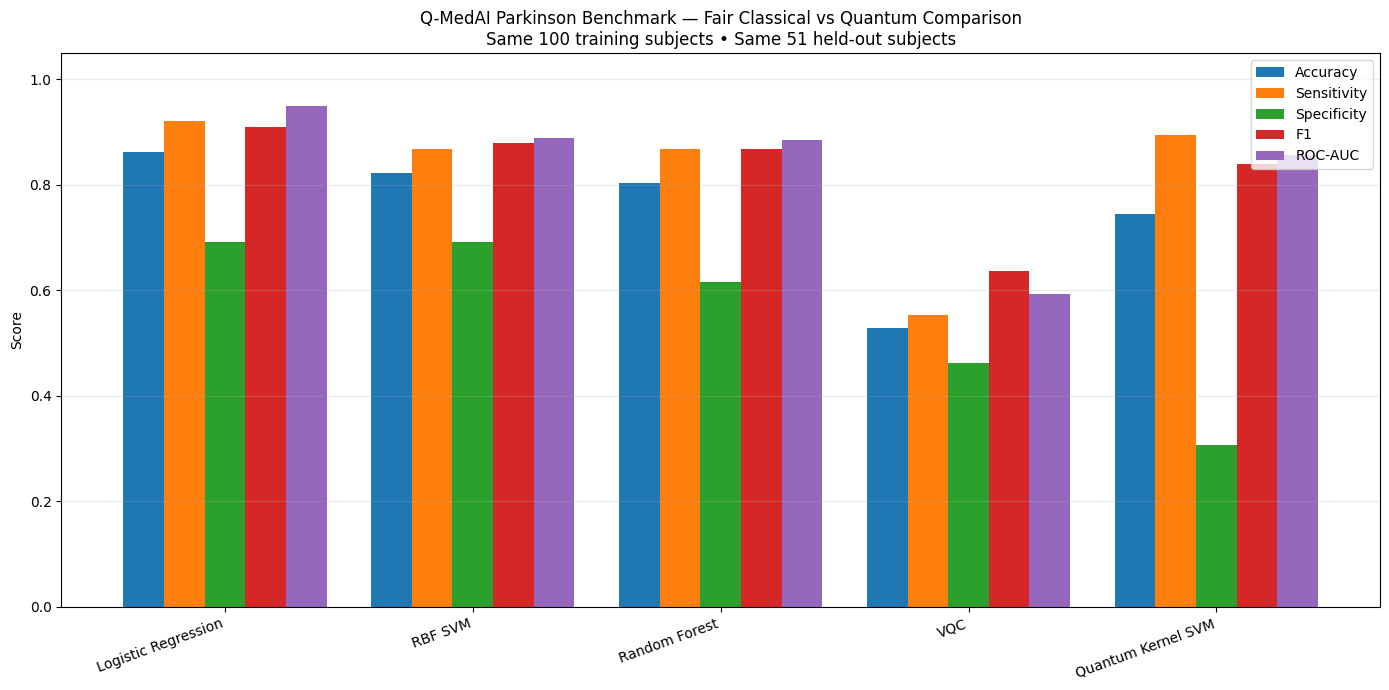

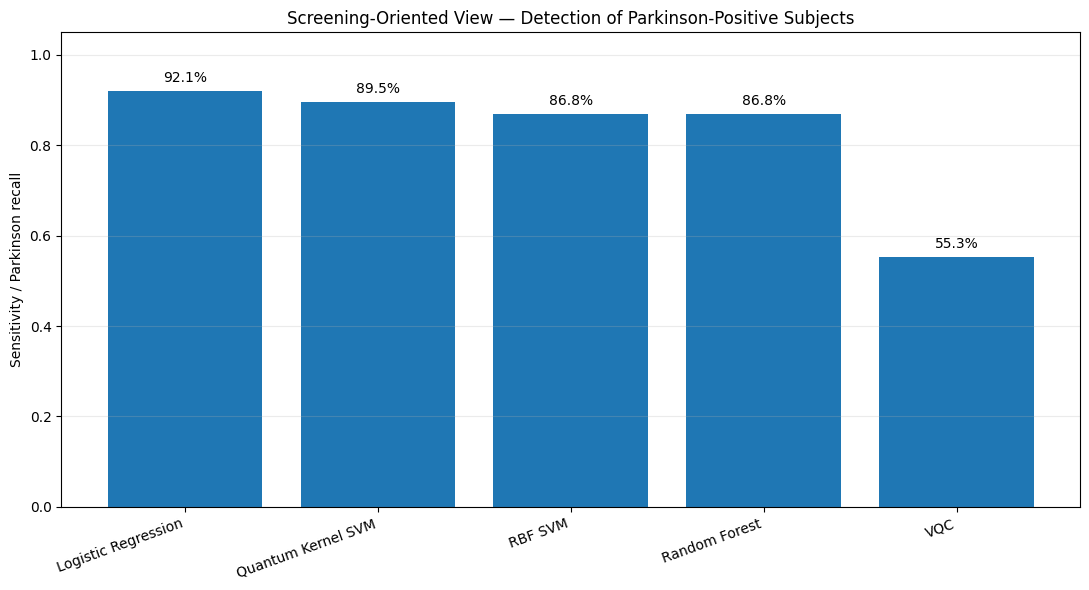

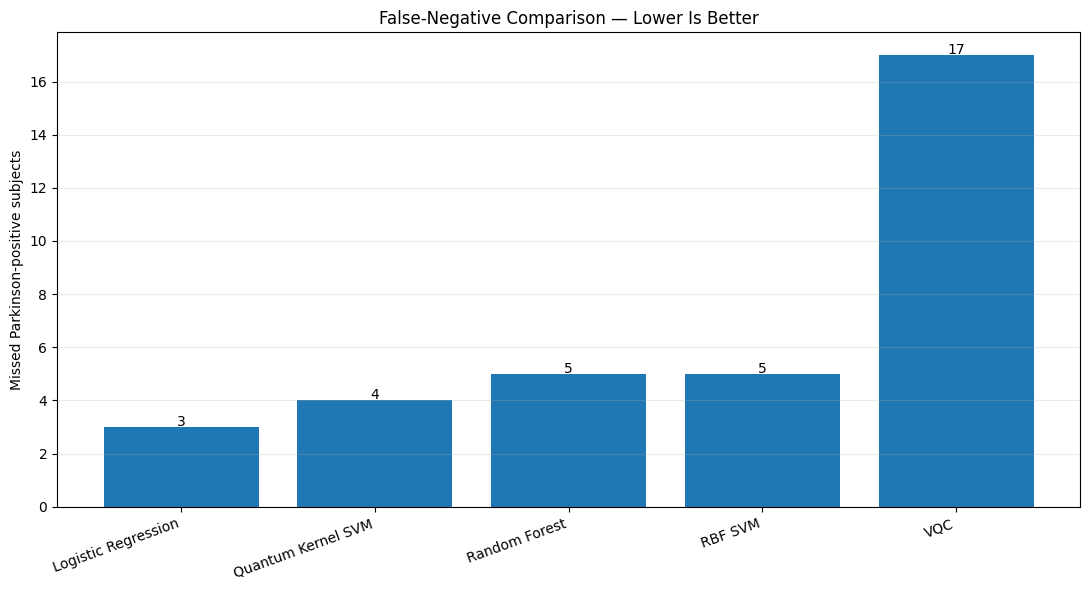

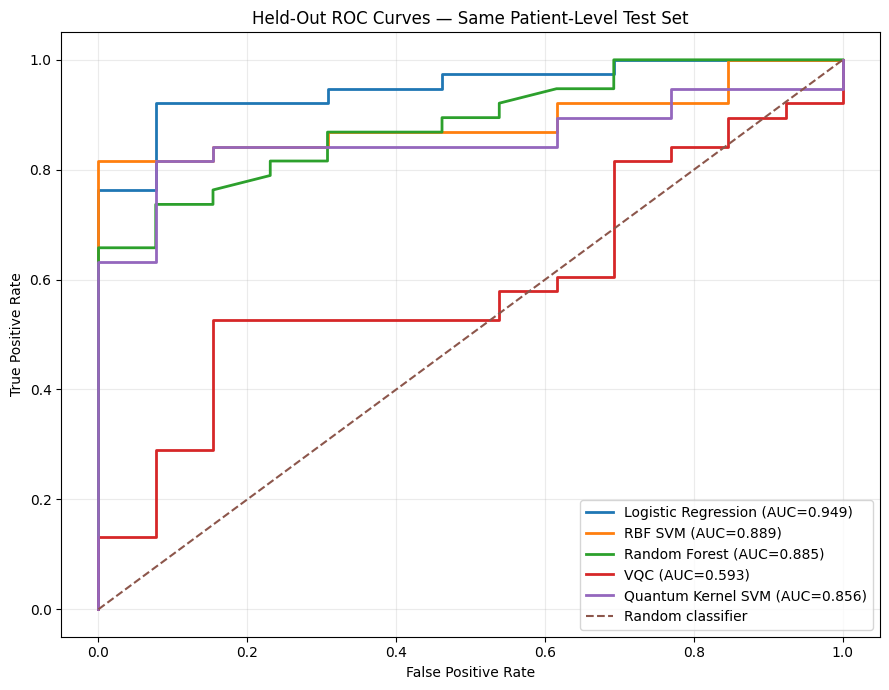

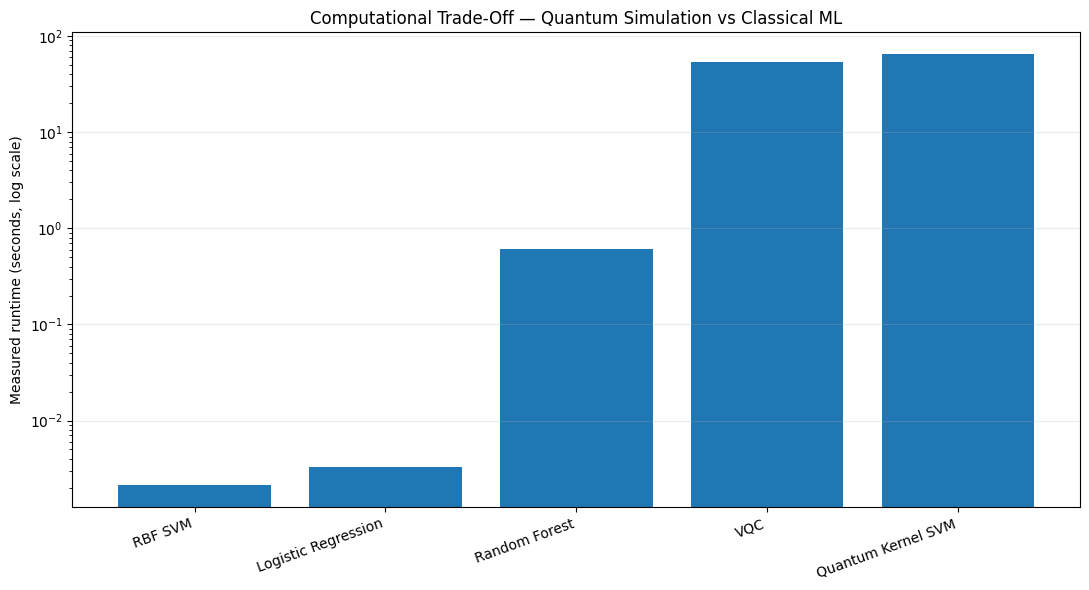


JUDGE-FACING VISUALS SAVED TO:
/kaggle/working/Q-MedAI-Parkinson/results/figures


In [19]:
# ============================================================
# CELL 13 — JUDGE-FACING VISUAL COMPARISON
# ============================================================

FIGURES_DIR = (
    RESULTS_DIR
    / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

completed = (
    final_matched_table[
        final_matched_table[
            "Status"
        ]
        == "COMPLETED"
    ]
    .copy()
)

# ------------------------------------------------------------
# 1. Multi-metric fair comparison
# ------------------------------------------------------------

metric_plot = (
    completed
    .set_index(
        "Model"
    )[
        [
            "Accuracy",
            "Sensitivity",
            "Specificity",
            "F1",
            "ROC-AUC",
        ]
    ]
)

ax = metric_plot.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.82,
)

ax.set_ylim(
    0.0,
    1.05,
)

ax.set_ylabel(
    "Score"
)

ax.set_xlabel(
    ""
)

ax.set_title(
    "Q-MedAI Parkinson Benchmark — "
    "Fair Classical vs Quantum Comparison\n"
    f"Same {len(y_train_match)} training subjects • "
    f"Same {len(y_test)} held-out subjects"
)

ax.grid(
    axis="y",
    alpha=0.25,
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

metric_path = (
    FIGURES_DIR
    / "01_fair_five_model_comparison.png"
)

plt.savefig(
    metric_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------
# 2. Sensitivity — screening-oriented view
# ------------------------------------------------------------

sensitivity_df = (
    completed[
        [
            "Model",
            "Sensitivity",
        ]
    ]
    .sort_values(
        "Sensitivity",
        ascending=False,
    )
)

plt.figure(
    figsize=(11, 6)
)

bars = plt.bar(
    sensitivity_df[
        "Model"
    ],
    sensitivity_df[
        "Sensitivity"
    ],
)

plt.ylim(
    0.0,
    1.05,
)

plt.ylabel(
    "Sensitivity / Parkinson recall"
)

plt.title(
    "Screening-Oriented View — "
    "Detection of Parkinson-Positive Subjects"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.grid(
    axis="y",
    alpha=0.25,
)

for bar, value in zip(
    bars,
    sensitivity_df[
        "Sensitivity"
    ],
):
    plt.text(
        bar.get_x()
        + bar.get_width()
        / 2,
        value
        + 0.02,
        f"{value:.1%}",
        ha="center",
    )

plt.tight_layout()

sensitivity_path = (
    FIGURES_DIR
    / "02_sensitivity_comparison.png"
)

plt.savefig(
    sensitivity_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------
# 3. False-negative comparison
# ------------------------------------------------------------

fn_df = (
    completed[
        [
            "Model",
            "False Negatives",
        ]
    ]
    .sort_values(
        "False Negatives"
    )
)

plt.figure(
    figsize=(11, 6)
)

bars = plt.bar(
    fn_df[
        "Model"
    ],
    fn_df[
        "False Negatives"
    ],
)

plt.ylabel(
    "Missed Parkinson-positive subjects"
)

plt.title(
    "False-Negative Comparison — Lower Is Better"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.grid(
    axis="y",
    alpha=0.25,
)

for bar, value in zip(
    bars,
    fn_df[
        "False Negatives"
    ],
):
    plt.text(
        bar.get_x()
        + bar.get_width()
        / 2,
        value
        + 0.05,
        str(
            int(
                value
            )
        ),
        ha="center",
    )

plt.tight_layout()

fn_path = (
    FIGURES_DIR
    / "03_false_negative_comparison.png"
)

plt.savefig(
    fn_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------
# 4. ROC curves
# ------------------------------------------------------------

result_lookup = {
    **classical_matched_results,
    "VQC": vqc_result,
    "Quantum Kernel SVM":
        quantum_kernel_result,
}

plt.figure(
    figsize=(9, 7)
)

for name, result in (
    result_lookup.items()
):
    if result[
        "status"
    ] != "COMPLETED":
        continue

    plt.plot(
        result[
            "fpr"
        ],
        result[
            "tpr"
        ],
        linewidth=2,
        label=(
            f"{name} "
            f"(AUC="
            f"{result['metrics']['roc_auc']:.3f})"
        ),
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier",
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Held-Out ROC Curves — "
    "Same Patient-Level Test Set"
)

plt.legend(
    loc="lower right",
)

plt.grid(
    alpha=0.25,
)

plt.tight_layout()

roc_path = (
    FIGURES_DIR
    / "04_roc_curves.png"
)

plt.savefig(
    roc_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------
# 5. Runtime
# ------------------------------------------------------------

runtime_df = (
    completed[
        [
            "Model",
            "Training Time (s)",
        ]
    ]
    .sort_values(
        "Training Time (s)"
    )
)

plt.figure(
    figsize=(11, 6)
)

plt.bar(
    runtime_df[
        "Model"
    ],
    runtime_df[
        "Training Time (s)"
    ],
)

plt.yscale(
    "log"
)

plt.ylabel(
    "Measured runtime (seconds, log scale)"
)

plt.title(
    "Computational Trade-Off — "
    "Quantum Simulation vs Classical ML"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()

runtime_path = (
    FIGURES_DIR
    / "05_runtime_tradeoff.png"
)

plt.savefig(
    runtime_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

print()
print("JUDGE-FACING VISUALS SAVED TO:")
print(FIGURES_DIR)

Q-MedAI — HIGH-DIMENSIONAL → QUANTUM-READY PROOF
Raw acoustic predictors : 752
Selected quantum inputs : 6
Required qubits         : 6

Selected features:
1. std_delta_log_energy
2. std_8th_delta
3. std_delta_delta_log_energy
4. tqwt_stdValue_dec_7
5. tqwt_minValue_dec_11
6. tqwt_maxValue_dec_11


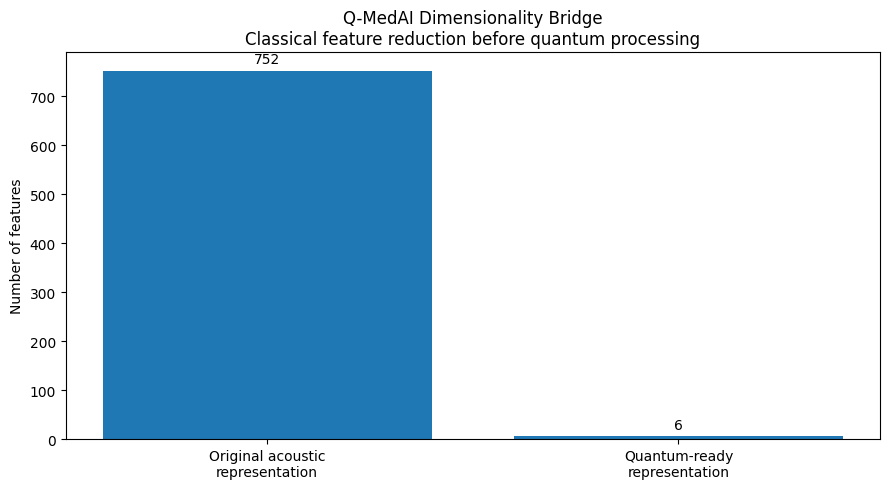

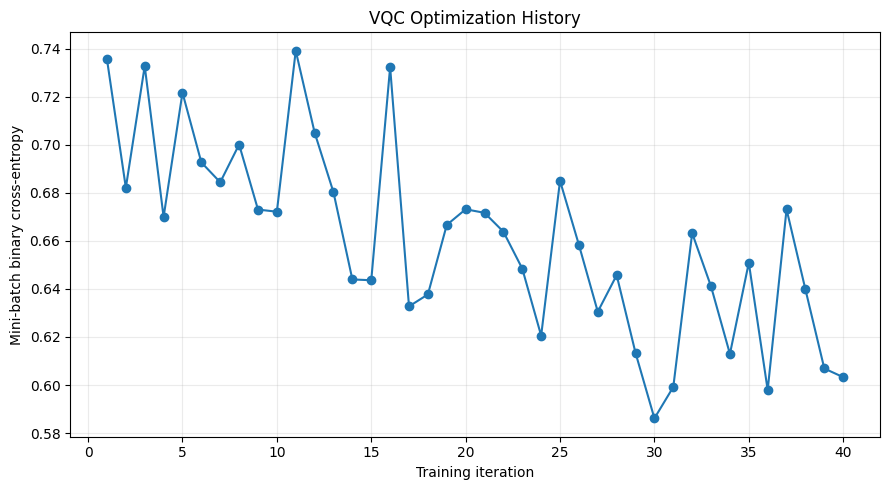

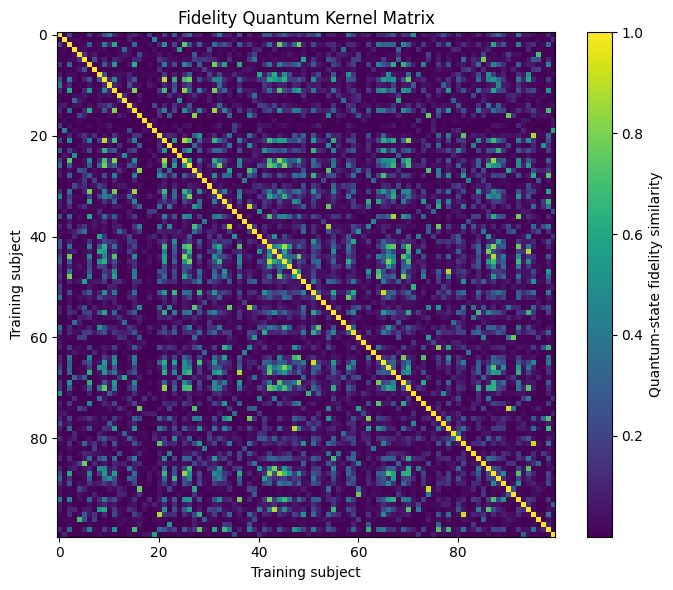


TRAINED VQC CIRCUIT EXAMPLE
0: ──RY(-2.56)──RX(0.35)───RY(0.26)───RZ(-0.01)─╭●─────────────╭X──RX(0.09)───RY(-0.00) ···
1: ──RY(-2.60)──RX(0.52)───RY(-0.52)──RZ(0.19)──╰X─╭●──────────│───RX(-0.25)──RY(0.42)─ ···
2: ──RY(-2.58)──RX(1.08)───RY(-0.56)──RZ(0.69)─────╰X─╭●───────│───RX(-0.82)──RY(-1.04) ···
3: ──RY(0.44)───RX(-0.87)──RY(0.37)───RZ(0.82)────────╰X─╭●────│───RX(-0.08)──RY(-0.12) ···
4: ──RY(1.74)───RX(0.66)───RY(0.71)───RZ(0.72)───────────╰X─╭●─│───RX(0.12)───RY(0.19)─ ···
5: ──RY(-1.86)──RX(-0.24)──RY(0.16)───RZ(0.50)──────────────╰X─╰●──RX(-0.48)──RY(0.35)─ ···

0: ··· ──RZ(-0.02)─╭●─────────────╭X─┤  <Z>
1: ··· ──RZ(-0.02)─╰X─╭●──────────│──┤     
2: ··· ──RZ(0.05)─────╰X─╭●───────│──┤     
3: ··· ──RZ(0.04)────────╰X─╭●────│──┤     
4: ··· ──RZ(-0.05)──────────╰X─╭●─│──┤     
5: ··· ──RZ(0.11)──────────────╰X─╰●─┤     

Backend disclosure: PennyLane default.qubit is a classical simulator of quantum circuits.


In [20]:
# ============================================================
# CELL 14 — HIGH-DIMENSIONAL REDUCTION + QUANTUM PROOF
# ============================================================

print("=" * 76)
print("Q-MedAI — HIGH-DIMENSIONAL → QUANTUM-READY PROOF")
print("=" * 76)

print(
    "Raw acoustic predictors :",
    X_train_raw.shape[
        1
    ],
)

print(
    "Selected quantum inputs :",
    CFG[
        "feature_count"
    ],
)

print(
    "Required qubits         :",
    CFG[
        "feature_count"
    ],
)

print()
print("Selected features:")

for index, feature in enumerate(
    matched_preprocessor
    .feature_names_out,
    start=1,
):
    print(
        f"{index}. {feature}"
    )

# ------------------------------------------------------------
# Reduction visualization
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)

labels = [
    "Original acoustic\nrepresentation",
    "Quantum-ready\nrepresentation",
]

values = [
    X_train_raw.shape[
        1
    ],
    CFG[
        "feature_count"
    ],
]

bars = plt.bar(
    labels,
    values,
)

plt.ylabel(
    "Number of features"
)

plt.title(
    "Q-MedAI Dimensionality Bridge\n"
    "Classical feature reduction before quantum processing"
)

for bar, value in zip(
    bars,
    values,
):
    plt.text(
        bar.get_x()
        + bar.get_width()
        / 2,
        value
        + max(
            values
        )
        * 0.02,
        str(
            int(
                value
            )
        ),
        ha="center",
    )

plt.tight_layout()

reduction_path = (
    FIGURES_DIR
    / "06_high_dimensional_to_quantum.png"
)

plt.savefig(
    reduction_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------
# VQC loss history
# ------------------------------------------------------------

if (
    vqc_result[
        "loss_history"
    ]
):
    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        np.arange(
            1,
            len(
                vqc_result[
                    "loss_history"
                ]
            )
            + 1,
        ),
        vqc_result[
            "loss_history"
        ],
        marker="o",
    )

    plt.xlabel(
        "Training iteration"
    )

    plt.ylabel(
        "Mini-batch binary cross-entropy"
    )

    plt.title(
        "VQC Optimization History"
    )

    plt.grid(
        alpha=0.25,
    )

    plt.tight_layout()

    vqc_loss_path = (
        FIGURES_DIR
        / "07_vqc_training_loss.png"
    )

    plt.savefig(
        vqc_loss_path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()

# ------------------------------------------------------------
# Quantum-kernel heatmap
# ------------------------------------------------------------

if (
    quantum_kernel_result[
        "status"
    ]
    == "COMPLETED"
):
    plt.figure(
        figsize=(7, 6)
    )

    plt.imshow(
        quantum_kernel_result[
            "K_train"
        ],
        aspect="auto",
    )

    plt.colorbar(
        label="Quantum-state fidelity similarity"
    )

    plt.xlabel(
        "Training subject"
    )

    plt.ylabel(
        "Training subject"
    )

    plt.title(
        "Fidelity Quantum Kernel Matrix"
    )

    plt.tight_layout()

    kernel_path = (
        FIGURES_DIR
        / "08_quantum_kernel_matrix.png"
    )

    plt.savefig(
        kernel_path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()

# ------------------------------------------------------------
# Actual VQC circuit text
# ------------------------------------------------------------

if (
    vqc_result[
        "status"
    ]
    == "COMPLETED"
):
    try:
        circuit_text = qml.draw(
            vqc_circuit
        )(
            pnp.array(
                X_train_match_quantum[
                    0
                ],
                requires_grad=False,
            ),
            pnp.array(
                vqc_result[
                    "final_weights"
                ],
                requires_grad=False,
            ),
        )

        print()
        print("=" * 76)
        print("TRAINED VQC CIRCUIT EXAMPLE")
        print("=" * 76)
        print(
            circuit_text
        )

    except Exception as exc:
        print(
            "Circuit text unavailable:",
            type(
                exc
            ).__name__,
            exc,
        )

print()
print(
    "Backend disclosure: PennyLane default.qubit "
    "is a classical simulator of quantum circuits."
)

In [21]:
# ============================================================
# CELL 15 — JUDGE INTERPRETATION
# ============================================================

print("""
============================================================================
                    Q-MedAI — PARKINSON BENCHMARK INTERPRETATION
============================================================================

WHY THIS DATASET IS A STRONGER TEST
-----------------------------------
The original breast-cancer benchmark begins with only 30 variables.

This Parkinson speech benchmark begins with hundreds of acoustic descriptors,
including nonlinear, spectral, wavelet and cepstral information.

Q-MedAI therefore has to solve the SIH-relevant dimensionality problem:

    HIGH-DIMENSIONAL BIOMEDICAL DATA
                  ↓
    LEAKAGE-SAFE CLASSICAL PREPROCESSING
                  ↓
    TRAIN-ONLY FEATURE REDUCTION
                  ↓
    QUANTUM-COMPATIBLE REPRESENTATION
                  ↓
    CLASSICAL / QUANTUM COMPARISON


PATIENT-LEVEL FAIRNESS
----------------------
The raw dataset contains three recordings per person.

This notebook does NOT randomly split those repeated recordings.

Instead, it first creates one patient-level acoustic representation and then
splits subjects into training and held-out testing groups.

That prevents the same patient's speech from leaking into both sides.


WHAT THE RESULT SHOULD BE USED TO TEST
--------------------------------------
The research question is NOT:

    "Can we force quantum ML to beat classical ML?"

The research question is:

    "On a substantially higher-dimensional biomedical representation,
     do quantum feature spaces provide competitive or complementary
     detection behavior after a fixed, leakage-safe reduction?"


SCREENING INTERPRETATION
------------------------
Sensitivity and false negatives are highlighted because failing to identify
a disease-positive subject is relevant to screening-oriented evaluation.

However, this dataset does NOT contain longitudinal evidence proving that
Q-MedAI predicts Parkinson's disease before clinical onset.

Therefore this notebook demonstrates disease-classification / screening
research, not proven pre-symptomatic diagnosis.


SCIENTIFIC DISCLOSURE
---------------------
PennyLane default.qubit is a classical simulator of quantum circuits.

No quantum-advantage claim should be made unless the actual observed results
support a statistically and methodologically defensible conclusion.

Q-MedAI is a research prototype, not a medical diagnostic device.
============================================================================
""")

print()
print("Observed matched-data ranking:")
print(
    final_matched_table[
        [
            "Model",
            "Status",
            "Accuracy",
            "Sensitivity",
            "Specificity",
            "F1",
            "ROC-AUC",
            "False Negatives",
        ]
    ]
    .sort_values(
        "ROC-AUC",
        ascending=False,
        na_position="last",
    )
    .round(4)
    .to_string(
        index=False
    )
)


                    Q-MedAI — PARKINSON BENCHMARK INTERPRETATION

WHY THIS DATASET IS A STRONGER TEST
-----------------------------------
The original breast-cancer benchmark begins with only 30 variables.

This Parkinson speech benchmark begins with hundreds of acoustic descriptors,
including nonlinear, spectral, wavelet and cepstral information.

Q-MedAI therefore has to solve the SIH-relevant dimensionality problem:

    HIGH-DIMENSIONAL BIOMEDICAL DATA
                  ↓
    LEAKAGE-SAFE CLASSICAL PREPROCESSING
                  ↓
    TRAIN-ONLY FEATURE REDUCTION
                  ↓
    QUANTUM-COMPATIBLE REPRESENTATION
                  ↓
    CLASSICAL / QUANTUM COMPARISON


PATIENT-LEVEL FAIRNESS
----------------------
The raw dataset contains three recordings per person.

This notebook does NOT randomly split those repeated recordings.

Instead, it first creates one patient-level acoustic representation and then
splits subjects into training and held-out testing groups.

That 

In [22]:
# ============================================================
# CELL 16 — BUILD KAGGLE / SIH EVIDENCE PACKAGE
# ============================================================

import json
import shutil
from pathlib import Path

EVIDENCE_DIR = Path(
    "/kaggle/working/Q-MedAI_Parkinson_Evidence"
)

if EVIDENCE_DIR.exists():
    shutil.rmtree(
        EVIDENCE_DIR
    )

EVIDENCE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# ------------------------------------------------------------
# Save structured experiment summary
# ------------------------------------------------------------

def serializable_metrics(
    result,
):
    metrics = result.get(
        "metrics"
    )

    if metrics is None:
        return None

    return {
        key: float(
            value
        )
        for key, value in metrics.items()
    }

summary = {
    "project": "Q-MedAI",
    "benchmark": (
        "UCI Parkinson's Disease Classification"
    ),
    "profile": PROFILE,
    "random_seed": RANDOM_SEED,
    "raw_recordings": int(
        len(
            df_raw
        )
    ),
    "subjects": int(
        len(
            subject_df
        )
    ),
    "raw_predictors_after_exclusions": int(
        X_train_raw.shape[
            1
        ]
    ),
    "selected_features": list(
        matched_preprocessor
        .feature_names_out
    ),
    "qubits": int(
        CFG[
            "feature_count"
        ]
    ),
    "full_training_subjects": int(
        len(
            y_train
        )
    ),
    "matched_training_subjects": int(
        len(
            y_train_match
        )
    ),
    "held_out_test_subjects": int(
        len(
            y_test
        )
    ),
    "backend": (
        "PennyLane default.qubit "
        "classical simulation"
    ),
    "vqc_status": vqc_result[
        "status"
    ],
    "vqc_metrics": serializable_metrics(
        vqc_result
    ),
    "quantum_kernel_status": (
        quantum_kernel_result[
            "status"
        ]
    ),
    "quantum_kernel_metrics": (
        serializable_metrics(
            quantum_kernel_result
        )
    ),
    "quantum_advantage_claimed": False,
    "medical_diagnostic_device": False,
}

summary_path = (
    RESULTS_DIR
    / "parkinson_benchmark_summary.json"
)

summary_path.write_text(
    json.dumps(
        summary,
        indent=2,
    ),
    encoding="utf-8",
)

# ------------------------------------------------------------
# Copy artifacts
# ------------------------------------------------------------

for source in [
    RESULTS_DIR
    / "final_matched_five_model_comparison.csv",

    RESULTS_DIR
    / "full_classical_reference.csv",

    summary_path,
]:
    if source.exists():
        shutil.copy2(
            source,
            EVIDENCE_DIR
            / source.name,
        )

if FIGURES_DIR.exists():
    shutil.copytree(
        FIGURES_DIR,
        EVIDENCE_DIR
        / "figures",
    )

if (
    quantum_kernel_result[
        "status"
    ]
    == "COMPLETED"
):
    np.save(
        EVIDENCE_DIR
        / "quantum_kernel_train.npy",
        quantum_kernel_result[
            "K_train"
        ],
    )

    np.save(
        EVIDENCE_DIR
        / "quantum_kernel_test.npy",
        quantum_kernel_result[
            "K_test"
        ],
    )

# ------------------------------------------------------------
# Human-readable README
# ------------------------------------------------------------

readme = f"""
Q-MedAI Parkinson Benchmark Evidence
====================================

Dataset:
UCI Parkinson's Disease Classification (Dataset 470)

Raw recordings:
{len(df_raw)}

Independent patient-level subjects:
{len(subject_df)}

High-dimensional predictors after exclusions:
{X_train_raw.shape[1]}

Quantum-ready selected features:
{CFG['feature_count']}

Matched training subjects:
{len(y_train_match)}

Held-out test subjects:
{len(y_test)}

Backend:
PennyLane default.qubit (classical simulation of quantum circuits)

Important methodology:
- repeated recordings are aggregated within subject before splitting
- train/test subjects are disjoint
- imputation, variance filtering, scaling and SelectKBest are fit on training data only
- quantum angle scaling is fit on matched training data only
- all five matched models use the same training subjects
- Quantum Kernel test matrix is test × train
- ROC-AUC uses continuous scores
- failed/timed-out quantum runs receive no fabricated metrics

This benchmark does not claim quantum advantage or clinical validation.
"""

(
    EVIDENCE_DIR
    / "README_FOR_JUDGES.txt"
).write_text(
    readme,
    encoding="utf-8",
)

ZIP_BASE = Path(
    "/kaggle/working/Q-MedAI_Parkinson_Evidence"
)

zip_path = shutil.make_archive(
    str(
        ZIP_BASE
    ),
    "zip",
    EVIDENCE_DIR,
)

print("=" * 76)
print("PARKINSON SIH EVIDENCE PACKAGE READY")
print("=" * 76)
print(zip_path)

print()
print("Contents:")

for path in sorted(
    EVIDENCE_DIR.rglob(
        "*"
    )
):
    if path.is_file():
        print(
            " -",
            path.relative_to(
                EVIDENCE_DIR
            )
        )

PARKINSON SIH EVIDENCE PACKAGE READY
/kaggle/working/Q-MedAI_Parkinson_Evidence.zip

Contents:
 - README_FOR_JUDGES.txt
 - figures/01_fair_five_model_comparison.png
 - figures/02_sensitivity_comparison.png
 - figures/03_false_negative_comparison.png
 - figures/04_roc_curves.png
 - figures/05_runtime_tradeoff.png
 - figures/06_high_dimensional_to_quantum.png
 - figures/07_vqc_training_loss.png
 - figures/08_quantum_kernel_matrix.png
 - final_matched_five_model_comparison.csv
 - full_classical_reference.csv
 - parkinson_benchmark_summary.json
 - quantum_kernel_test.npy
 - quantum_kernel_train.npy


Q-MedAI — EXPERIMENT C
QUANTUM READINESS / CLASSICAL DIMENSIONALITY STUDY
Independent subjects : 252
Original predictors  : 752
Class distribution   : {0: 64, 1: 188}
Cross-validation     : 3-fold stratified
Random seed          : 42
Dimensions tested    : [752, 100, 50, 20, 10, 8, 6, 4]
Fold 1: train=168, test=84, overlap=0, train classes={0: 43, 1: 125}, test classes={0: 21, 1: 63}
Fold 2: train=168, test=84, overlap=0, train classes={0: 43, 1: 125}, test classes={0: 21, 1: 63}
Fold 3: train=168, test=84, overlap=0, train classes={0: 42, 1: 126}, test classes={0: 22, 1: 62}

PATIENT-LEVEL CV SAFETY CHECK PASSED

REQUESTED DIMENSION: 752
Fold 1 | Logistic Regression  | k=752 | AUC=0.7559 | PR=0.8780 | Sens=0.8730 | Spec=0.5238
Fold 1 | RBF SVM              | k=752 | AUC=0.7740 | PR=0.8811 | Sens=0.9524 | Spec=0.4286
Fold 1 | Random Forest        | k=752 | AUC=0.8016 | PR=0.9227 | Sens=0.9365 | Spec=0.4286
Fold 2 | Logistic Regression  | k=752 | AUC=0.8005 | PR=0.9253 | Sens=0.9048 | S

,Model,Requested Features,Actual Features,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,PR-AUC Std,Sensitivity Mean,Sensitivity Std,Specificity Mean,Specificity Std,F1 Mean,F1 Std,Balanced Accuracy Mean,Balanced Accuracy Std,End-to-End Time (s) Mean,End-to-End Time (s) Std
0,Logistic Regression,752,752,0.7822,0.0234,0.9060,0.0248,0.8722,0.0330,0.5296,0.1040,0.8585,0.0056,0.7009,0.0355,0.0673,0.0299
1,Logistic Regression,100,100,0.8059,0.0196,0.9203,0.0177,0.8777,0.0483,0.5945,0.1043,0.8704,0.0135,0.7361,0.0294,0.0550,0.0353
2,Logistic Regression,50,50,0.8097,0.0200,0.9251,0.0184,0.8936,0.0558,0.4841,0.0496,0.8632,0.0240,0.6889,0.0057,0.0331,0.0004
3,Logistic Regression,20,20,0.8488,0.0339,0.9420,0.0085,0.9257,0.0238,0.4827,0.0937,0.8812,0.0234,0.7042,0.0582,0.0322,0.0011
4,Logistic Regression,10,10,0.7963,0.0390,0.9112,0.0211,0.9308,0.0187,0.5130,0.1538,0.8886,0.0141,0.7219,0.0700,0.0304,0.0006
5,Logistic Regression,8,8,0.7981,0.0491,0.9120,0.0234,0.9309,0.0241,0.5606,0.1076,0.8953,0.0182,0.7457,0.0545,0.0306,0.0015
6,Logistic Regression,6,6,0.8087,0.0650,0.9193,0.0242,0.9308,0.0486,0.5289,0.1505,0.8906,0.0371,0.7298,0.0854,0.0294,0.0006
7,Logistic Regression,4,4,0.7281,0.0138,0.8691,0.0250,0.9524,0.0572,0.3759,0.0554,0.8792,0.0267,0.6641,0.0320,0.0299,0.0011
8,RBF SVM,752,752,0.8047,0.0289,0.9071,0.0289,0.9735,0.0242,0.3276,0.1231,0.8842,0.0171,0.6506,0.0618,0.0601,0.0075
9,RBF SVM,100,100,0.8113,0.0651,0.9099,0.0423,0.9310,0.0397,0.4827,0.1336,0.8840,0.0278,0.7069,0.0722,0.0364,0.0052


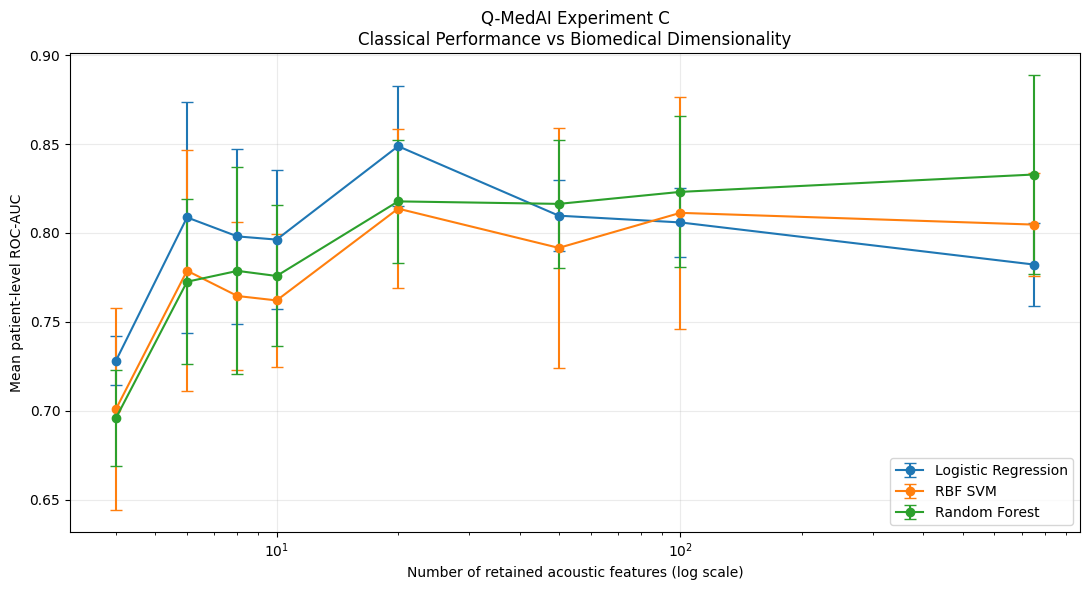


EXPERIMENT C — CLASSICAL PHASE COMPLETE
Fold results   : /kaggle/working/Q-MedAI-Parkinson/results/experiment_c/classical_dimension_cv_folds.csv
Summary results: /kaggle/working/Q-MedAI-Parkinson/results/experiment_c/classical_dimension_cv_summary.csv
ROC-AUC plot   : /kaggle/working/Q-MedAI-Parkinson/results/experiment_c/classical_roc_auc_vs_dimension.png

IMPORTANT: EXPC_SPLITS is now LOCKED.
The next quantum cell must reuse these exact patient-level folds.


In [23]:
# ============================================================
# CELL 17 — EXPERIMENT C
# QUANTUM READINESS / CLASSICAL DIMENSIONALITY STUDY
# ============================================================
#
# PURPOSE
# -------
# Measure how much predictive information is retained as the
# high-dimensional Parkinson representation is compressed.
#
# IMPORTANT:
# - patient-level data only
# - preprocessing fitted inside each CV training fold
# - no held-out fold information enters imputation/scaling/
#   variance filtering/feature selection
# - these SAME folds will be reused by the quantum study
# - this is NOT hyperparameter tuning on the old test set
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif,
)
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
)

# ------------------------------------------------------------
# LOCKED EXPERIMENT-C CONFIGURATION
# ------------------------------------------------------------

EXPC_RANDOM_SEED = 42

# 3-fold rather than 5-fold because the SAME folds will later
# be used for expensive 4/6/8-qubit quantum-kernel experiments.
EXPC_N_SPLITS = 3

EXPC_CLASSICAL_DIMENSIONS = [
    752,
    100,
    50,
    20,
    10,
    8,
    6,
    4,
]

# ------------------------------------------------------------
# PATIENT-LEVEL DATA
#
# X_subject / y_subject already contain one row per subject.
# ------------------------------------------------------------

X_expc = (
    X_subject
    .reset_index(drop=True)
    .copy()
)

y_expc = (
    y_subject
    .reset_index(drop=True)
    .astype(int)
    .copy()
)

subject_ids_expc = (
    subject_identity
    .reset_index(drop=True)
    .astype(str)
    .copy()
)

assert len(X_expc) == len(y_expc)
assert len(X_expc) == len(subject_ids_expc)

# Critical safety assertion:
# one row = one independent person.
assert (
    subject_ids_expc.nunique()
    == len(subject_ids_expc)
), (
    "Experiment C requires exactly one row per subject."
)

assert set(
    y_expc.unique()
) == {0, 1}

print("=" * 88)
print("Q-MedAI — EXPERIMENT C")
print("QUANTUM READINESS / CLASSICAL DIMENSIONALITY STUDY")
print("=" * 88)

print("Independent subjects :", len(X_expc))
print("Original predictors  :", X_expc.shape[1])
print(
    "Class distribution   :",
    y_expc.value_counts()
    .sort_index()
    .to_dict(),
)
print("Cross-validation     :", f"{EXPC_N_SPLITS}-fold stratified")
print("Random seed          :", EXPC_RANDOM_SEED)
print(
    "Dimensions tested    :",
    EXPC_CLASSICAL_DIMENSIONS,
)

# ------------------------------------------------------------
# CREATE AND LOCK THE CV SPLITS
#
# Save them globally because the quantum experiment MUST reuse
# exactly these folds.
# ------------------------------------------------------------

expc_cv = StratifiedKFold(
    n_splits=EXPC_N_SPLITS,
    shuffle=True,
    random_state=EXPC_RANDOM_SEED,
)

EXPC_SPLITS = list(
    expc_cv.split(
        X_expc,
        y_expc,
    )
)

# ------------------------------------------------------------
# VERIFY EVERY CV FOLD IS PATIENT-DISJOINT
# ------------------------------------------------------------

for fold_number, (
    train_idx,
    test_idx,
) in enumerate(
    EXPC_SPLITS,
    start=1,
):

    train_ids = set(
        subject_ids_expc.iloc[
            train_idx
        ]
    )

    test_ids = set(
        subject_ids_expc.iloc[
            test_idx
        ]
    )

    overlap = (
        train_ids
        .intersection(
            test_ids
        )
    )

    assert len(overlap) == 0

    print(
        f"Fold {fold_number}: "
        f"train={len(train_idx)}, "
        f"test={len(test_idx)}, "
        f"overlap={len(overlap)}, "
        f"train classes="
        f"{y_expc.iloc[train_idx].value_counts().sort_index().to_dict()}, "
        f"test classes="
        f"{y_expc.iloc[test_idx].value_counts().sort_index().to_dict()}"
    )

print()
print("PATIENT-LEVEL CV SAFETY CHECK PASSED")

# ------------------------------------------------------------
# MODELS
# ------------------------------------------------------------

def make_expc_classical_models():

    return {

        "Logistic Regression":
            LogisticRegression(
                max_iter=5000,
                random_state=EXPC_RANDOM_SEED,
            ),

        "RBF SVM":
            SVC(
                kernel="rbf",
                probability=False,
                random_state=EXPC_RANDOM_SEED,
            ),

        "Random Forest":
            RandomForestClassifier(
                n_estimators=300,
                random_state=EXPC_RANDOM_SEED,
                n_jobs=-1,
            ),
    }


# ------------------------------------------------------------
# CONTINUOUS SCORE FOR ROC-AUC / PR-AUC
# ------------------------------------------------------------

def get_continuous_score(
    model,
    X,
):

    if hasattr(
        model,
        "predict_proba",
    ):

        return (
            model
            .predict_proba(X)[:, 1]
        )

    return (
        model
        .decision_function(X)
    )


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

def expc_metrics(
    y_true,
    y_pred,
    y_score,
):

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )

    tn, fp, fn, tp = (
        cm.ravel()
    )

    specificity = (
        tn / (tn + fp)
        if (
            tn + fp
        ) > 0
        else np.nan
    )

    return {

        "ROC-AUC":
            roc_auc_score(
                y_true,
                y_score,
            ),

        "PR-AUC":
            average_precision_score(
                y_true,
                y_score,
            ),

        "Sensitivity":
            recall_score(
                y_true,
                y_pred,
                zero_division=0,
            ),

        "Specificity":
            specificity,

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            ),

        "False Negatives":
            int(fn),

        "False Positives":
            int(fp),
    }


# ------------------------------------------------------------
# RUN DIMENSIONALITY STUDY
# ------------------------------------------------------------

expc_classical_rows = []

for requested_dimension in (
    EXPC_CLASSICAL_DIMENSIONS
):

    print()
    print("=" * 88)
    print(
        f"REQUESTED DIMENSION: "
        f"{requested_dimension}"
    )
    print("=" * 88)

    for fold_number, (
        train_idx,
        test_idx,
    ) in enumerate(
        EXPC_SPLITS,
        start=1,
    ):

        X_fold_train_raw = (
            X_expc.iloc[
                train_idx
            ]
        )

        X_fold_test_raw = (
            X_expc.iloc[
                test_idx
            ]
        )

        y_fold_train = (
            y_expc.iloc[
                train_idx
            ]
            .to_numpy(
                dtype=int
            )
        )

        y_fold_test = (
            y_expc.iloc[
                test_idx
            ]
            .to_numpy(
                dtype=int
            )
        )

        # ----------------------------------------------------
        # TRAIN-FOLD-ONLY PREPROCESSING
        # ----------------------------------------------------

        preprocessing_start = (
            time.perf_counter()
        )

        imputer = SimpleImputer(
            strategy="median"
        )

        X_train_imp = (
            imputer.fit_transform(
                X_fold_train_raw
            )
        )

        X_test_imp = (
            imputer.transform(
                X_fold_test_raw
            )
        )

        variance_filter = (
            VarianceThreshold(
                threshold=0.0
            )
        )

        X_train_var = (
            variance_filter
            .fit_transform(
                X_train_imp
            )
        )

        X_test_var = (
            variance_filter
            .transform(
                X_test_imp
            )
        )

        available_features = (
            X_train_var.shape[1]
        )

        actual_dimension = min(
            requested_dimension,
            available_features,
        )

        scaler = StandardScaler()

        X_train_scaled = (
            scaler.fit_transform(
                X_train_var
            )
        )

        X_test_scaled = (
            scaler.transform(
                X_test_var
            )
        )

        # ----------------------------------------------------
        # FEATURE SELECTION
        #
        # Fit only on the training fold.
        # ----------------------------------------------------

        selector = SelectKBest(
            score_func=f_classif,
            k=actual_dimension,
        )

        X_train_reduced = (
            selector.fit_transform(
                X_train_scaled,
                y_fold_train,
            )
        )

        X_test_reduced = (
            selector.transform(
                X_test_scaled
            )
        )

        preprocessing_seconds = (
            time.perf_counter()
            - preprocessing_start
        )

        assert (
            X_train_reduced.shape[1]
            == actual_dimension
        )

        assert (
            X_test_reduced.shape[1]
            == actual_dimension
        )

        # ----------------------------------------------------
        # CLASSICAL MODELS
        # ----------------------------------------------------

        models = (
            make_expc_classical_models()
        )

        for model_name, model in (
            models.items()
        ):

            model_start = (
                time.perf_counter()
            )

            model.fit(
                X_train_reduced,
                y_fold_train,
            )

            y_pred = model.predict(
                X_test_reduced
            )

            y_score = (
                get_continuous_score(
                    model,
                    X_test_reduced,
                )
            )

            model_seconds = (
                time.perf_counter()
                - model_start
            )

            # Continuous-score safety check.
            assert len(
                np.unique(
                    np.round(
                        y_score,
                        12,
                    )
                )
            ) > 2

            metrics = expc_metrics(
                y_fold_test,
                y_pred,
                y_score,
            )

            row = {

                "Model":
                    model_name,

                "Requested Features":
                    requested_dimension,

                "Actual Features":
                    actual_dimension,

                "Fold":
                    fold_number,

                "Train Subjects":
                    len(train_idx),

                "Test Subjects":
                    len(test_idx),

                "ROC-AUC":
                    metrics[
                        "ROC-AUC"
                    ],

                "PR-AUC":
                    metrics[
                        "PR-AUC"
                    ],

                "Sensitivity":
                    metrics[
                        "Sensitivity"
                    ],

                "Specificity":
                    metrics[
                        "Specificity"
                    ],

                "F1":
                    metrics[
                        "F1"
                    ],

                "Balanced Accuracy":
                    metrics[
                        "Balanced Accuracy"
                    ],

                "False Negatives":
                    metrics[
                        "False Negatives"
                    ],

                "False Positives":
                    metrics[
                        "False Positives"
                    ],

                "Preprocessing Time (s)":
                    preprocessing_seconds,

                "Model Time (s)":
                    model_seconds,

                "End-to-End Time (s)":
                    (
                        preprocessing_seconds
                        + model_seconds
                    ),
            }

            expc_classical_rows.append(
                row
            )

            print(
                f"Fold {fold_number} | "
                f"{model_name:20s} | "
                f"k={actual_dimension:3d} | "
                f"AUC={metrics['ROC-AUC']:.4f} | "
                f"PR={metrics['PR-AUC']:.4f} | "
                f"Sens={metrics['Sensitivity']:.4f} | "
                f"Spec={metrics['Specificity']:.4f}"
            )


# ------------------------------------------------------------
# RAW FOLD RESULTS
# ------------------------------------------------------------

expc_classical_folds = (
    pd.DataFrame(
        expc_classical_rows
    )
)

# ------------------------------------------------------------
# MEAN ± STD SUMMARY
# ------------------------------------------------------------

metric_columns = [

    "ROC-AUC",
    "PR-AUC",
    "Sensitivity",
    "Specificity",
    "F1",
    "Balanced Accuracy",
    "End-to-End Time (s)",
]

summary_rows = []

for (
    model_name,
    requested_features,
), group in (
    expc_classical_folds.groupby(
        [
            "Model",
            "Requested Features",
        ]
    )
):

    summary_row = {

        "Model":
            model_name,

        "Requested Features":
            int(
                requested_features
            ),

        "Actual Features":
            int(
                group[
                    "Actual Features"
                ]
                .median()
            ),
    }

    for metric in (
        metric_columns
    ):

        summary_row[
            f"{metric} Mean"
        ] = (
            group[
                metric
            ]
            .mean()
        )

        summary_row[
            f"{metric} Std"
        ] = (
            group[
                metric
            ]
            .std(
                ddof=1
            )
        )

    summary_rows.append(
        summary_row
    )

expc_classical_summary = (
    pd.DataFrame(
        summary_rows
    )
    .sort_values(
        [
            "Model",
            "Requested Features",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)

print()
print("=" * 88)
print(
    "EXPERIMENT C — CLASSICAL "
    "DIMENSIONALITY SUMMARY"
)
print("=" * 88)

display(
    expc_classical_summary.round(
        4
    )
)

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

EXPC_RESULTS_DIR = (
    RESULTS_DIR
    / "experiment_c"
)

EXPC_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

fold_path = (
    EXPC_RESULTS_DIR
    / "classical_dimension_cv_folds.csv"
)

summary_path = (
    EXPC_RESULTS_DIR
    / "classical_dimension_cv_summary.csv"
)

expc_classical_folds.to_csv(
    fold_path,
    index=False,
)

expc_classical_summary.to_csv(
    summary_path,
    index=False,
)

# ------------------------------------------------------------
# PLOT — ROC-AUC VS DIMENSIONALITY
# ------------------------------------------------------------

plt.figure(
    figsize=(11, 6)
)

for model_name in (
    expc_classical_summary[
        "Model"
    ]
    .unique()
):

    model_data = (
        expc_classical_summary[
            expc_classical_summary[
                "Model"
            ]
            == model_name
        ]
        .sort_values(
            "Actual Features"
        )
    )

    plt.errorbar(
        model_data[
            "Actual Features"
        ],
        model_data[
            "ROC-AUC Mean"
        ],
        yerr=model_data[
            "ROC-AUC Std"
        ],
        marker="o",
        capsize=4,
        label=model_name,
    )

plt.xscale(
    "log"
)

plt.xlabel(
    "Number of retained acoustic features "
    "(log scale)"
)

plt.ylabel(
    "Mean patient-level ROC-AUC"
)

plt.title(
    "Q-MedAI Experiment C\n"
    "Classical Performance vs Biomedical Dimensionality"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plot_path = (
    EXPC_RESULTS_DIR
    / "classical_roc_auc_vs_dimension.png"
)

plt.savefig(
    plot_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

print()
print("=" * 88)
print("EXPERIMENT C — CLASSICAL PHASE COMPLETE")
print("=" * 88)

print(
    "Fold results   :",
    fold_path,
)

print(
    "Summary results:",
    summary_path,
)

print(
    "ROC-AUC plot   :",
    plot_path,
)

print()
print(
    "IMPORTANT: EXPC_SPLITS is now LOCKED."
)

print(
    "The next quantum cell must reuse "
    "these exact patient-level folds."
)

Q-MedAI — EXPERIMENT C
QUANTUM KERNEL READINESS STUDY
Independent subjects : 252
Locked CV folds      : 3
Quantum dimensions   : [4, 6, 8]
Backend              : PennyLane default.qubit
Kernel computation   : exact statevector fidelity

LOCKED PATIENT-LEVEL FOLDS VERIFIED

QUANTUM DIMENSION: 4 QUBITS
Fold 1 | q=4 | AUC=0.6969 | PR=0.8412 | Sens=0.8571 | Spec=0.3810 | BalAcc=0.6190 | KTA=0.1100 | Within=0.4612 | Between=0.2987 | Gap=0.1625 | ERank=6.20 | Time=0.71s
Fold 2 | q=4 | AUC=0.7264 | PR=0.8555 | Sens=0.9365 | Spec=0.3810 | BalAcc=0.6587 | KTA=0.0984 | Within=0.2903 | Between=0.1830 | Gap=0.1072 | ERank=15.97 | Time=0.67s
Fold 3 | q=4 | AUC=0.6855 | PR=0.7971 | Sens=1.0000 | Spec=0.3182 | BalAcc=0.6591 | KTA=0.0825 | Within=0.3685 | Between=0.2654 | Gap=0.1032 | ERank=7.49 | Time=0.68s

QUANTUM DIMENSION: 6 QUBITS
Fold 1 | q=6 | AUC=0.7052 | PR=0.8407 | Sens=0.8730 | Spec=0.4762 | BalAcc=0.6746 | KTA=0.0963 | Within=0.3924 | Between=0.2512 | Gap=0.1412 | ERank=8.72 | Time=0.83s


,Qubits,Fold,ROC-AUC,PR-AUC,Sensitivity,Specificity,F1,Balanced Accuracy,Kernel-Target Alignment,Within-Class Similarity,Between-Class Similarity,Similarity Gap,Effective Rank,End-to-End Time (s)
0,4,1,0.6969,0.8412,0.8571,0.3810,0.8308,0.6190,0.1100,0.4612,0.2987,0.1625,6.1963,0.7128
1,4,2,0.7264,0.8555,0.9365,0.3810,0.8741,0.6587,0.0984,0.2903,0.1830,0.1072,15.9711,0.6735
2,4,3,0.6855,0.7971,1.0000,0.3182,0.8921,0.6591,0.0825,0.3685,0.2654,0.1032,7.4893,0.6788
3,6,1,0.7052,0.8407,0.8730,0.4762,0.8527,0.6746,0.0963,0.3924,0.2512,0.1412,8.7221,0.8276
4,6,2,0.8209,0.9335,0.9524,0.2857,0.8696,0.6190,0.0976,0.1820,0.1068,0.0752,37.7006,0.8495
5,6,3,0.8182,0.9150,0.9516,0.3182,0.8676,0.6349,0.0884,0.1321,0.1100,0.0222,32.7295,0.8811
6,8,1,0.7657,0.8983,0.9048,0.4762,0.8702,0.6905,0.1032,0.2680,0.1346,0.1334,17.2993,1.0792
7,8,2,0.7657,0.8902,0.9841,0.1905,0.8732,0.5873,0.0801,0.0989,0.0600,0.0388,67.5163,1.0801
8,8,3,0.7676,0.9001,0.8871,0.2273,0.8209,0.5572,0.0935,0.0692,0.0496,0.0196,70.3265,1.0956



EXPERIMENT C — QUANTUM KERNEL SUMMARY


,Model,Features,Qubits,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,PR-AUC Std,Sensitivity Mean,Sensitivity Std,Specificity Mean,...,Similarity Gap Mean,Similarity Gap Std,Effective Rank Mean,Effective Rank Std,Off-Diagonal Mean Mean,Off-Diagonal Mean Std,Off-Diagonal Std Mean,Off-Diagonal Std Std,End-to-End Time (s) Mean,End-to-End Time (s) Std
0,Quantum Kernel SVM,4,4,0.7029,0.0211,0.8312,0.0304,0.9312,0.0716,0.360,...,0.1243,0.0331,9.8856,5.3097,0.3259,0.0750,0.3089,0.0452,0.6883,0.0213
1,Quantum Kernel SVM,6,6,0.7814,0.0660,0.8964,0.0491,0.9257,0.0456,0.360,...,0.0795,0.0597,26.3841,15.4964,0.2051,0.1163,0.2404,0.0740,0.8527,0.0269
2,Quantum Kernel SVM,8,8,0.7663,0.0011,0.8962,0.0053,0.9253,0.0517,0.298,...,0.0639,0.0609,51.7140,29.8372,0.1209,0.0839,0.1857,0.0864,1.0850,0.0092



FAIR SAME-DIMENSION CLASSICAL VS QUANTUM


,Model,Features,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,PR-AUC Std,Sensitivity Mean,Sensitivity Std,Specificity Mean,Specificity Std,F1 Mean,F1 Std,Balanced Accuracy Mean,Balanced Accuracy Std
0,Logistic Regression,4,0.7281,0.0138,0.8691,0.0250,0.9524,0.0572,0.3759,0.0554,0.8792,0.0267,0.6641,0.0320
1,Quantum Kernel SVM,4,0.7029,0.0211,0.8312,0.0304,0.9312,0.0716,0.3600,0.0362,0.8656,0.0315,0.6456,0.0230
2,RBF SVM,4,0.7009,0.0570,0.8243,0.0554,0.9577,0.0601,0.3600,0.0362,0.8797,0.0272,0.6589,0.0238
3,Random Forest,4,0.6958,0.0272,0.8364,0.0240,0.9099,0.0748,0.4069,0.0606,0.8606,0.0308,0.6584,0.0075
4,Logistic Regression,6,0.8087,0.0650,0.9193,0.0242,0.9308,0.0486,0.5289,0.1505,0.8906,0.0371,0.7298,0.0854
5,Quantum Kernel SVM,6,0.7814,0.0660,0.8964,0.0491,0.9257,0.0456,0.3600,0.1019,0.8633,0.0092,0.6428,0.0286
6,RBF SVM,6,0.7787,0.0678,0.8957,0.0402,0.9469,0.0509,0.4214,0.0373,0.8830,0.0303,0.6841,0.0427
7,Random Forest,6,0.7725,0.0465,0.8799,0.0196,0.9043,0.0571,0.4841,0.0496,0.8690,0.0248,0.6942,0.0140
8,Logistic Regression,8,0.7981,0.0491,0.9120,0.0234,0.9309,0.0241,0.5606,0.1076,0.8953,0.0182,0.7457,0.0545
9,Quantum Kernel SVM,8,0.7663,0.0011,0.8962,0.0053,0.9253,0.0517,0.2980,0.1554,0.8548,0.0294,0.6117,0.0699


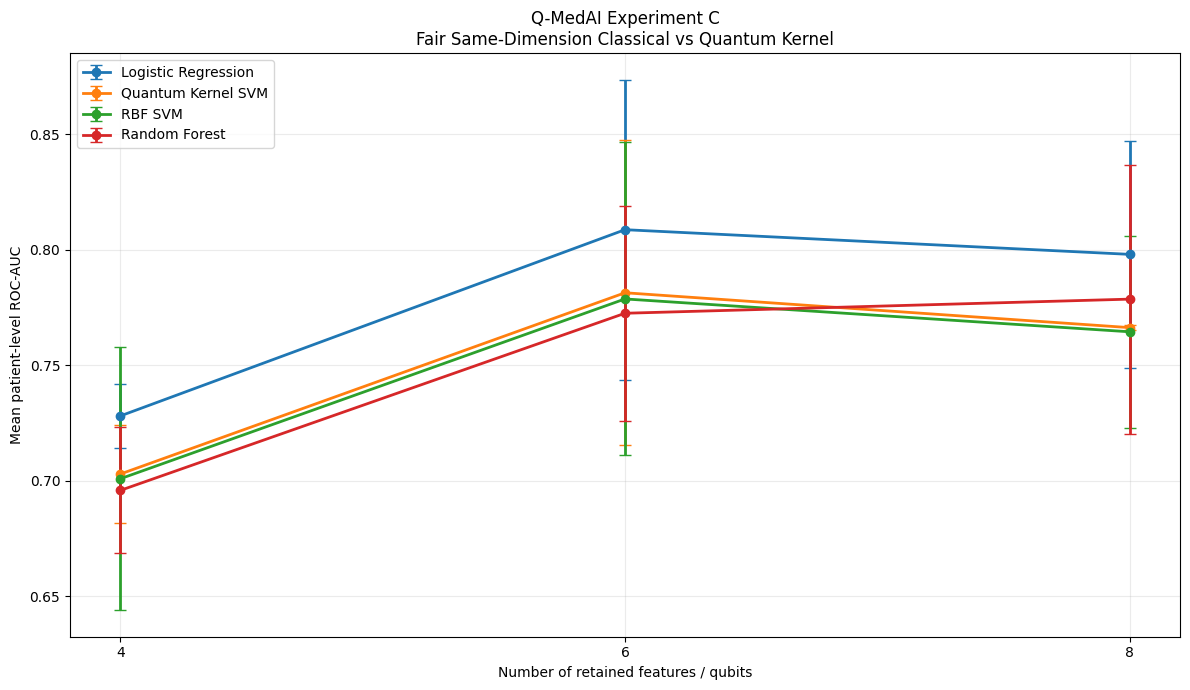

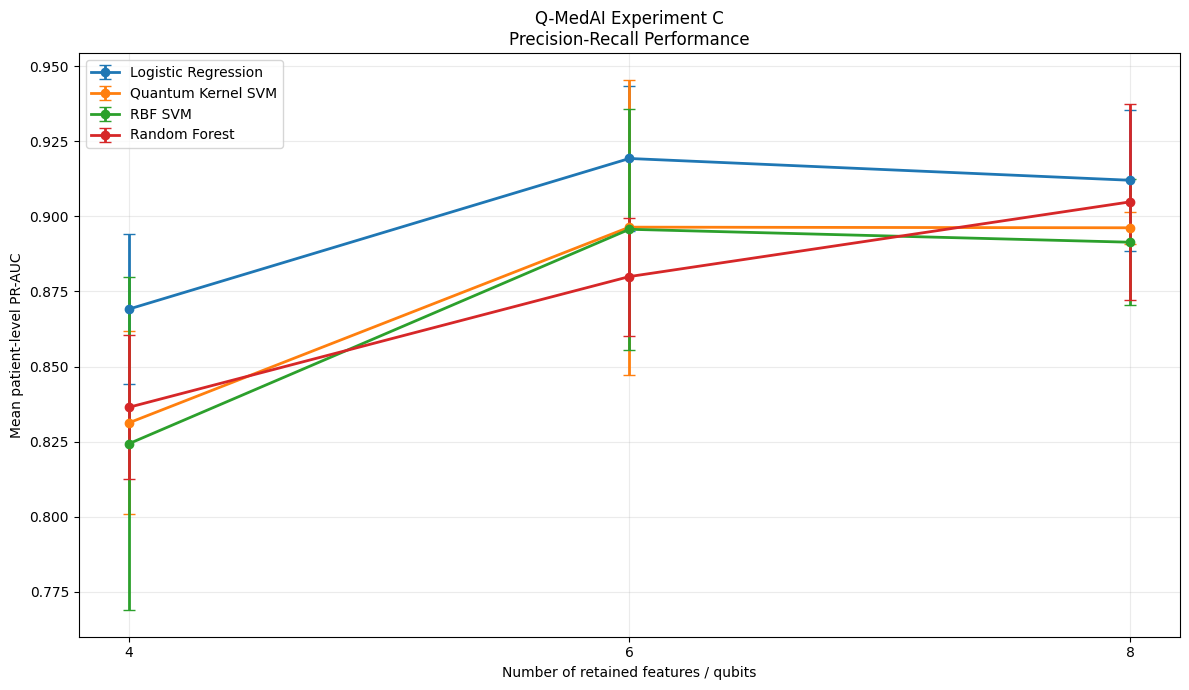

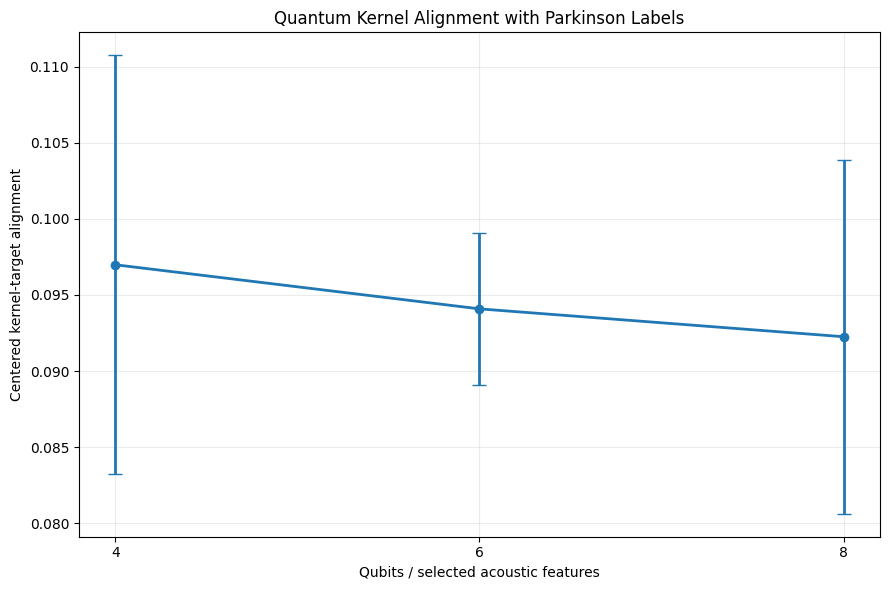

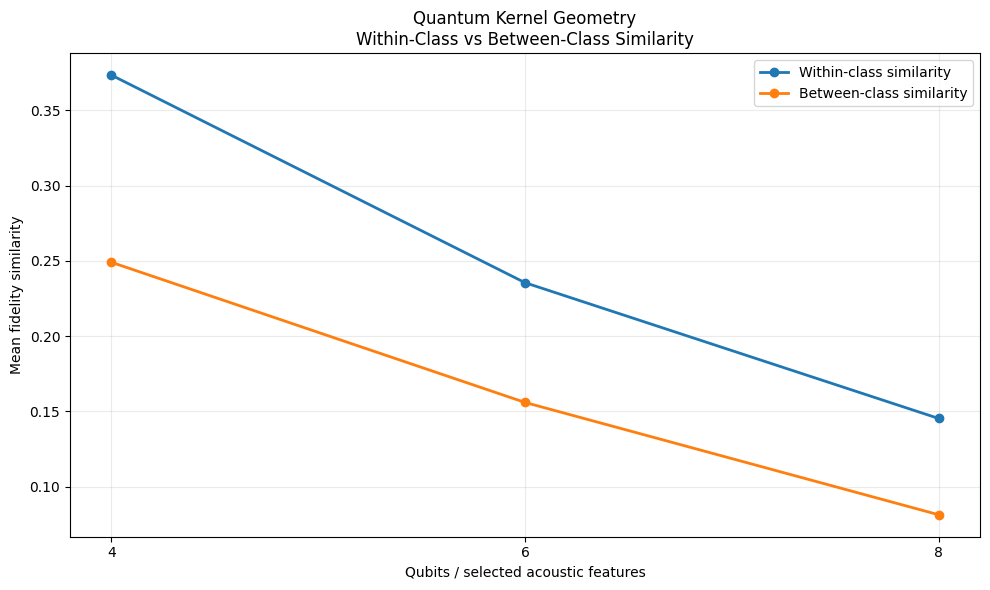

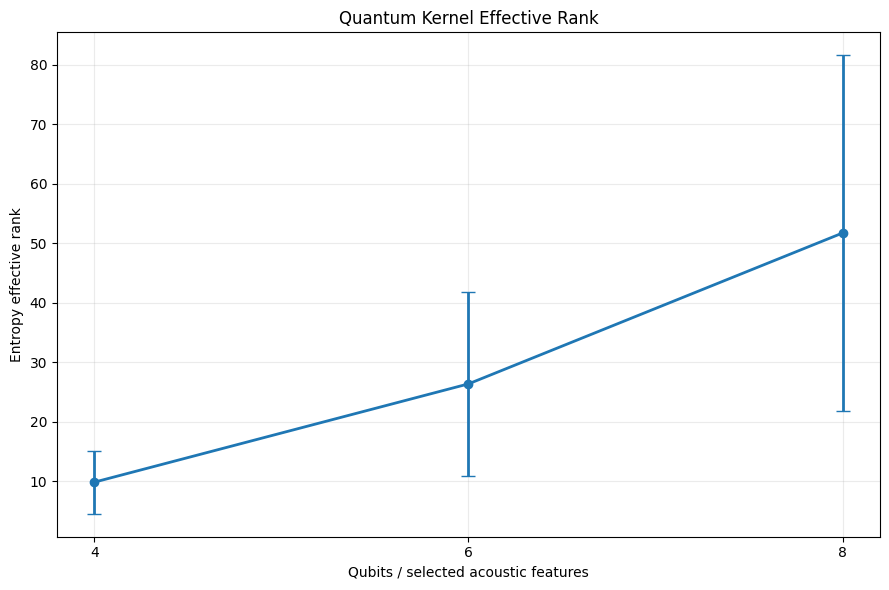

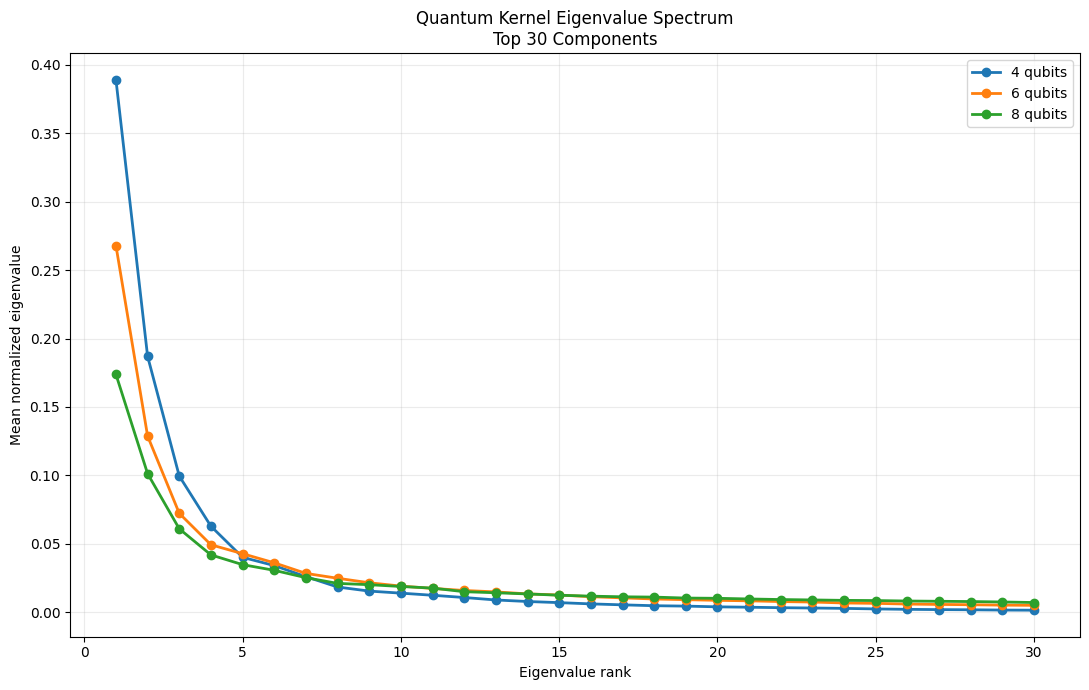


QUANTUM KERNEL GEOMETRY DIAGNOSTIC

4 QUBITS
  ROC-AUC              : 0.7029
  Kernel-target align. : 0.0970
  Within-class sim.    : 0.3733
  Between-class sim.   : 0.2490
  Similarity gap       : 0.1243
  Effective rank       : 9.89
  Mean off-diagonal K  : 0.3259

6 QUBITS
  ROC-AUC              : 0.7814
  Kernel-target align. : 0.0941
  Within-class sim.    : 0.2355
  Between-class sim.   : 0.1560
  Similarity gap       : 0.0795
  Effective rank       : 26.38
  Mean off-diagonal K  : 0.2051

8 QUBITS
  ROC-AUC              : 0.7663
  Kernel-target align. : 0.0923
  Within-class sim.    : 0.1453
  Between-class sim.   : 0.0814
  Similarity gap       : 0.0639
  Effective rank       : 51.71
  Mean off-diagonal K  : 0.1209

EXPERIMENT C — QUANTUM PHASE COMPLETE
Quantum fold results : /kaggle/working/Q-MedAI-Parkinson/results/experiment_c/quantum_kernel_cv_folds.csv
Quantum summary      : /kaggle/working/Q-MedAI-Parkinson/results/experiment_c/quantum_kernel_cv_summary.csv
Classical vs 

In [24]:
# ============================================================
# CELL 18 — EXPERIMENT C
# QUANTUM KERNEL READINESS STUDY
#
# Quantum dimensions:
#     4 qubits
#     6 qubits
#     8 qubits
#
# SAME locked patient-level CV folds as Cell 17.
#
# Measures:
# - ROC-AUC
# - PR-AUC
# - Sensitivity
# - Specificity
# - F1
# - Balanced Accuracy
# - Runtime
#
# Kernel diagnostics:
# - Kernel-target alignment
# - Within-class similarity
# - Between-class similarity
# - Within-vs-between similarity gap
# - Effective rank
# - Eigenvalue spectrum
#
# IMPORTANT:
# This uses exact statevectors from PennyLane default.qubit.
# That is a CLASSICAL SIMULATION of quantum states.
#
# Statevectors are computed once per patient and pairwise
# fidelities are then calculated by linear algebra.
#
# This is mathematically equivalent to the fidelity kernel on
# this noiseless simulator, but its runtime must NOT be claimed
# as real quantum-hardware execution time.
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif,
)
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
)
from sklearn.svm import SVC

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
)

import pennylane as qml


# ============================================================
# 1. LOCKED CONFIGURATION
# ============================================================

EXPC_QUANTUM_DIMENSIONS = [
    4,
    6,
    8,
]

QUANTUM_ANGLE_RANGE = (
    -np.pi,
    np.pi,
)

print("=" * 92)
print("Q-MedAI — EXPERIMENT C")
print("QUANTUM KERNEL READINESS STUDY")
print("=" * 92)

print(
    "Independent subjects :",
    len(X_expc),
)

print(
    "Locked CV folds      :",
    len(EXPC_SPLITS),
)

print(
    "Quantum dimensions   :",
    EXPC_QUANTUM_DIMENSIONS,
)

print(
    "Backend              :",
    "PennyLane default.qubit"
)

print(
    "Kernel computation   :",
    "exact statevector fidelity"
)

print()


# ============================================================
# 2. SAFETY CHECK
# ============================================================

assert (
    subject_ids_expc.nunique()
    == len(subject_ids_expc)
), (
    "Experiment C quantum phase requires "
    "one row per subject."
)

assert len(
    EXPC_SPLITS
) == EXPC_N_SPLITS

for fold_number, (
    train_idx,
    test_idx,
) in enumerate(
    EXPC_SPLITS,
    start=1,
):

    train_ids = set(
        subject_ids_expc.iloc[
            train_idx
        ]
    )

    test_ids = set(
        subject_ids_expc.iloc[
            test_idx
        ]
    )

    overlap = (
        train_ids
        .intersection(
            test_ids
        )
    )

    assert len(
        overlap
    ) == 0


print(
    "LOCKED PATIENT-LEVEL FOLDS VERIFIED"
)


# ============================================================
# 3. TRAIN-FOLD-ONLY QUANTUM PREPROCESSING
# ============================================================

def prepare_quantum_fold(
    X_train_frame,
    X_test_frame,
    y_train_values,
    n_features,
):

    feature_names_original = np.asarray(
        X_train_frame.columns,
        dtype=object,
    )

    # --------------------------------------------------------
    # Imputation
    # --------------------------------------------------------

    imputer = SimpleImputer(
        strategy="median"
    )

    X_train_imp = (
        imputer.fit_transform(
            X_train_frame
        )
    )

    X_test_imp = (
        imputer.transform(
            X_test_frame
        )
    )

    # --------------------------------------------------------
    # Remove constants
    # --------------------------------------------------------

    variance_filter = (
        VarianceThreshold(
            threshold=0.0
        )
    )

    X_train_var = (
        variance_filter
        .fit_transform(
            X_train_imp
        )
    )

    X_test_var = (
        variance_filter
        .transform(
            X_test_imp
        )
    )

    feature_names_variance = (
        feature_names_original[
            variance_filter
            .get_support()
        ]
    )

    assert (
        X_train_var.shape[1]
        >= n_features
    )

    # --------------------------------------------------------
    # Standardization
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = (
        scaler.fit_transform(
            X_train_var
        )
    )

    X_test_scaled = (
        scaler.transform(
            X_test_var
        )
    )

    # --------------------------------------------------------
    # SelectKBest — TRAIN FOLD ONLY
    # --------------------------------------------------------

    selector = SelectKBest(
        score_func=f_classif,
        k=n_features,
    )

    X_train_selected = (
        selector.fit_transform(
            X_train_scaled,
            y_train_values,
        )
    )

    X_test_selected = (
        selector.transform(
            X_test_scaled
        )
    )

    selected_names = (
        feature_names_variance[
            selector.get_support()
        ]
        .tolist()
    )

    # --------------------------------------------------------
    # Quantum angle mapping — TRAIN FOLD ONLY
    # --------------------------------------------------------

    angle_scaler = MinMaxScaler(
        feature_range=QUANTUM_ANGLE_RANGE,
        clip=True,
    )

    X_train_quantum = (
        angle_scaler.fit_transform(
            X_train_selected
        )
    )

    X_test_quantum = (
        angle_scaler.transform(
            X_test_selected
        )
    )

    assert (
        X_train_quantum.shape[1]
        == n_features
    )

    assert (
        X_test_quantum.shape[1]
        == n_features
    )

    return (
        X_train_quantum,
        X_test_quantum,
        selected_names,
    )


# ============================================================
# 4. QUANTUM FEATURE MAP
# ============================================================

def make_quantum_state_circuit(
    n_qubits,
):

    device = qml.device(
        "default.qubit",
        wires=n_qubits,
    )

    @qml.qnode(
        device,
        interface=None,
    )
    def state_circuit(
        x,
    ):

        # ----------------------------------------------------
        # First data encoding
        # ----------------------------------------------------

        for wire in range(
            n_qubits
        ):

            qml.RY(
                x[
                    wire
                ],
                wires=wire,
            )

        # ----------------------------------------------------
        # Entanglement ring
        # ----------------------------------------------------

        for wire in range(
            n_qubits
        ):

            qml.CNOT(
                wires=[
                    wire,
                    (
                        wire + 1
                    )
                    % n_qubits,
                ]
            )

        # ----------------------------------------------------
        # Data re-uploading
        # ----------------------------------------------------

        for wire in range(
            n_qubits
        ):

            next_wire = (
                wire + 1
            ) % n_qubits

            qml.RY(
                0.5
                * x[
                    wire
                ],
                wires=wire,
            )

            qml.RZ(
                0.25
                * x[
                    wire
                ]
                * x[
                    next_wire
                ],
                wires=wire,
            )

        return qml.state()

    return state_circuit


# ============================================================
# 5. COMPUTE QUANTUM STATES
# ============================================================

def compute_quantum_states(
    X,
    state_circuit,
):

    states = []

    for row in np.asarray(
        X,
        dtype=float,
    ):

        state = np.asarray(
            state_circuit(
                row
            ),
            dtype=complex,
        )

        states.append(
            state
        )

    return np.vstack(
        states
    )


# ============================================================
# 6. EXACT FIDELITY KERNEL
# ============================================================

def fidelity_kernel(
    states_a,
    states_b,
):

    # <a|b>
    overlaps = (
        states_a.conj()
        @ states_b.T
    )

    K = (
        np.abs(
            overlaps
        )
        ** 2
    )

    return np.asarray(
        K,
        dtype=float,
    )


# ============================================================
# 7. KERNEL CENTERING
# ============================================================

def center_kernel(
    K,
):

    K = np.asarray(
        K,
        dtype=float,
    )

    n = K.shape[0]

    H = (
        np.eye(
            n
        )
        -
        np.ones(
            (
                n,
                n,
            )
        )
        / n
    )

    return (
        H
        @ K
        @ H
    )


# ============================================================
# 8. KERNEL-TARGET ALIGNMENT
# ============================================================

def kernel_target_alignment(
    K,
    y,
):

    y = np.asarray(
        y,
        dtype=int,
    )

    y_pm = (
        2 * y
        - 1
    ).astype(float)

    target_kernel = (
        np.outer(
            y_pm,
            y_pm,
        )
    )

    K_centered = (
        center_kernel(
            K
        )
    )

    Y_centered = (
        center_kernel(
            target_kernel
        )
    )

    numerator = float(
        np.sum(
            K_centered
            * Y_centered
        )
    )

    denominator = float(
        np.linalg.norm(
            K_centered,
            ord="fro",
        )
        *
        np.linalg.norm(
            Y_centered,
            ord="fro",
        )
    )

    if denominator <= 1e-15:

        return np.nan

    return (
        numerator
        / denominator
    )


# ============================================================
# 9. WITHIN / BETWEEN CLASS SIMILARITY
# ============================================================

def class_similarity_statistics(
    K,
    y,
):

    K = np.asarray(
        K,
        dtype=float,
    )

    y = np.asarray(
        y,
        dtype=int,
    )

    n = len(
        y
    )

    upper_triangle = (
        np.triu(
            np.ones(
                (
                    n,
                    n,
                ),
                dtype=bool,
            ),
            k=1,
        )
    )

    same_class = (
        y[
            :,
            None,
        ]
        ==
        y[
            None,
            :,
        ]
    )

    different_class = (
        ~same_class
    )

    within_values = (
        K[
            upper_triangle
            & same_class
        ]
    )

    between_values = (
        K[
            upper_triangle
            & different_class
        ]
    )

    within_mean = float(
        np.mean(
            within_values
        )
    )

    between_mean = float(
        np.mean(
            between_values
        )
    )

    return {

        "Within-Class Similarity":
            within_mean,

        "Between-Class Similarity":
            between_mean,

        "Similarity Gap":
            (
                within_mean
                - between_mean
            ),
    }


# ============================================================
# 10. EFFECTIVE RANK + EIGENVALUES
# ============================================================

def kernel_spectrum_statistics(
    K,
):

    K = np.asarray(
        K,
        dtype=float,
    )

    # Numerical symmetrization
    K = (
        K
        + K.T
    ) / 2.0

    eigenvalues = (
        np.linalg.eigvalsh(
            K
        )
    )

    eigenvalues = (
        np.clip(
            eigenvalues,
            0.0,
            None,
        )
    )

    eigenvalues = (
        np.sort(
            eigenvalues
        )[
            ::-1
        ]
    )

    total = float(
        np.sum(
            eigenvalues
        )
    )

    if total <= 1e-15:

        normalized = np.zeros_like(
            eigenvalues
        )

        effective_rank = 0.0

    else:

        normalized = (
            eigenvalues
            / total
        )

        nonzero = (
            normalized[
                normalized > 1e-15
            ]
        )

        entropy = -float(
            np.sum(
                nonzero
                * np.log(
                    nonzero
                )
            )
        )

        effective_rank = float(
            np.exp(
                entropy
            )
        )

    return (
        eigenvalues,
        normalized,
        effective_rank,
    )


# ============================================================
# 11. CLASSIFICATION METRICS
# ============================================================

def quantum_expc_metrics(
    y_true,
    y_pred,
    y_score,
):

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[
            0,
            1,
        ],
    )

    tn, fp, fn, tp = (
        cm.ravel()
    )

    specificity = (
        tn
        /
        (
            tn + fp
        )
        if (
            tn + fp
        ) > 0
        else np.nan
    )

    return {

        "ROC-AUC":
            roc_auc_score(
                y_true,
                y_score,
            ),

        "PR-AUC":
            average_precision_score(
                y_true,
                y_score,
            ),

        "Sensitivity":
            recall_score(
                y_true,
                y_pred,
                zero_division=0,
            ),

        "Specificity":
            specificity,

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            ),

        "False Negatives":
            int(
                fn
            ),

        "False Positives":
            int(
                fp
            ),
    }


# ============================================================
# 12. RUN QUANTUM CROSS-VALIDATION
# ============================================================

quantum_rows = []

kernel_eigenvalue_rows = []

selected_feature_rows = []


for n_qubits in (
    EXPC_QUANTUM_DIMENSIONS
):

    print()
    print("=" * 92)

    print(
        f"QUANTUM DIMENSION: "
        f"{n_qubits} QUBITS"
    )

    print("=" * 92)

    state_circuit = (
        make_quantum_state_circuit(
            n_qubits
        )
    )

    for fold_number, (
        train_idx,
        test_idx,
    ) in enumerate(
        EXPC_SPLITS,
        start=1,
    ):

        fold_total_start = (
            time.perf_counter()
        )

        # ----------------------------------------------------
        # RAW FOLD DATA
        # ----------------------------------------------------

        X_fold_train_raw = (
            X_expc.iloc[
                train_idx
            ]
        )

        X_fold_test_raw = (
            X_expc.iloc[
                test_idx
            ]
        )

        y_fold_train = (
            y_expc.iloc[
                train_idx
            ]
            .to_numpy(
                dtype=int
            )
        )

        y_fold_test = (
            y_expc.iloc[
                test_idx
            ]
            .to_numpy(
                dtype=int
            )
        )

        # ----------------------------------------------------
        # PREPROCESSING
        # ----------------------------------------------------

        preprocessing_start = (
            time.perf_counter()
        )

        (
            X_train_quantum,
            X_test_quantum,
            selected_names,
        ) = prepare_quantum_fold(
            X_fold_train_raw,
            X_fold_test_raw,
            y_fold_train,
            n_qubits,
        )

        preprocessing_seconds = (
            time.perf_counter()
            - preprocessing_start
        )

        # ----------------------------------------------------
        # SAVE FEATURE SELECTION PER FOLD
        # ----------------------------------------------------

        for rank, feature_name in enumerate(
            selected_names,
            start=1,
        ):

            selected_feature_rows.append(
                {
                    "Qubits":
                        n_qubits,

                    "Fold":
                        fold_number,

                    "Feature Rank":
                        rank,

                    "Feature":
                        feature_name,
                }
            )

        # ----------------------------------------------------
        # TRAIN QUANTUM STATES
        # ----------------------------------------------------

        state_train_start = (
            time.perf_counter()
        )

        train_states = (
            compute_quantum_states(
                X_train_quantum,
                state_circuit,
            )
        )

        train_state_seconds = (
            time.perf_counter()
            - state_train_start
        )

        # ----------------------------------------------------
        # TRAIN KERNEL
        # ----------------------------------------------------

        kernel_train_start = (
            time.perf_counter()
        )

        K_train = (
            fidelity_kernel(
                train_states,
                train_states,
            )
        )

        # Numerical protection
        K_train = (
            K_train
            + K_train.T
        ) / 2.0

        np.fill_diagonal(
            K_train,
            1.0,
        )

        kernel_train_seconds = (
            time.perf_counter()
            - kernel_train_start
        )

        assert (
            K_train.shape
            ==
            (
                len(train_idx),
                len(train_idx),
            )
        )

        assert np.allclose(
            K_train,
            K_train.T,
            atol=1e-9,
        )

        assert np.allclose(
            np.diag(
                K_train
            ),
            1.0,
            atol=1e-8,
        )

        # ----------------------------------------------------
        # KERNEL GEOMETRY — TRAIN ONLY
        # ----------------------------------------------------

        alignment = (
            kernel_target_alignment(
                K_train,
                y_fold_train,
            )
        )

        similarity_stats = (
            class_similarity_statistics(
                K_train,
                y_fold_train,
            )
        )

        (
            eigenvalues,
            normalized_eigenvalues,
            effective_rank,
        ) = kernel_spectrum_statistics(
            K_train
        )

        # Off-diagonal distribution
        upper_mask = np.triu(
            np.ones_like(
                K_train,
                dtype=bool,
            ),
            k=1,
        )

        off_diagonal = (
            K_train[
                upper_mask
            ]
        )

        off_diag_mean = float(
            np.mean(
                off_diagonal
            )
        )

        off_diag_std = float(
            np.std(
                off_diagonal
            )
        )

        off_diag_min = float(
            np.min(
                off_diagonal
            )
        )

        off_diag_max = float(
            np.max(
                off_diagonal
            )
        )

        for eigen_rank, (
            eigenvalue,
            normalized_eigenvalue,
        ) in enumerate(
            zip(
                eigenvalues,
                normalized_eigenvalues,
            ),
            start=1,
        ):

            kernel_eigenvalue_rows.append(
                {
                    "Qubits":
                        n_qubits,

                    "Fold":
                        fold_number,

                    "Eigen Rank":
                        eigen_rank,

                    "Eigenvalue":
                        float(
                            eigenvalue
                        ),

                    "Normalized Eigenvalue":
                        float(
                            normalized_eigenvalue
                        ),
                }
            )

        # ----------------------------------------------------
        # PRECOMPUTED QSVM
        # ----------------------------------------------------

        svm = SVC(
            kernel="precomputed",
            random_state=EXPC_RANDOM_SEED,
        )

        svm_train_start = (
            time.perf_counter()
        )

        svm.fit(
            K_train,
            y_fold_train,
        )

        svm_train_seconds = (
            time.perf_counter()
            - svm_train_start
        )

        # ----------------------------------------------------
        # TEST STATES
        # ----------------------------------------------------

        state_test_start = (
            time.perf_counter()
        )

        test_states = (
            compute_quantum_states(
                X_test_quantum,
                state_circuit,
            )
        )

        test_state_seconds = (
            time.perf_counter()
            - state_test_start
        )

        # ----------------------------------------------------
        # TEST × TRAIN KERNEL
        #
        # NO test × test kernel is used.
        # ----------------------------------------------------

        kernel_test_start = (
            time.perf_counter()
        )

        K_test = (
            fidelity_kernel(
                test_states,
                train_states,
            )
        )

        kernel_test_seconds = (
            time.perf_counter()
            - kernel_test_start
        )

        assert (
            K_test.shape
            ==
            (
                len(test_idx),
                len(train_idx),
            )
        )

        # ----------------------------------------------------
        # INFERENCE
        # ----------------------------------------------------

        inference_start = (
            time.perf_counter()
        )

        y_pred = (
            svm.predict(
                K_test
            )
        )

        y_score = (
            svm.decision_function(
                K_test
            )
        )

        inference_seconds = (
            time.perf_counter()
            - inference_start
        )

        y_score = np.asarray(
            y_score,
            dtype=float,
        )

        assert len(
            np.unique(
                np.round(
                    y_score,
                    12,
                )
            )
        ) > 2

        metrics = (
            quantum_expc_metrics(
                y_fold_test,
                y_pred,
                y_score,
            )
        )

        total_seconds = (
            time.perf_counter()
            - fold_total_start
        )

        # ----------------------------------------------------
        # RESULT ROW
        # ----------------------------------------------------

        row = {

            "Model":
                "Quantum Kernel SVM",

            "Qubits":
                n_qubits,

            "Features":
                n_qubits,

            "Fold":
                fold_number,

            "Train Subjects":
                len(train_idx),

            "Test Subjects":
                len(test_idx),

            "ROC-AUC":
                metrics[
                    "ROC-AUC"
                ],

            "PR-AUC":
                metrics[
                    "PR-AUC"
                ],

            "Sensitivity":
                metrics[
                    "Sensitivity"
                ],

            "Specificity":
                metrics[
                    "Specificity"
                ],

            "F1":
                metrics[
                    "F1"
                ],

            "Balanced Accuracy":
                metrics[
                    "Balanced Accuracy"
                ],

            "False Negatives":
                metrics[
                    "False Negatives"
                ],

            "False Positives":
                metrics[
                    "False Positives"
                ],

            "Kernel-Target Alignment":
                alignment,

            "Within-Class Similarity":
                similarity_stats[
                    "Within-Class Similarity"
                ],

            "Between-Class Similarity":
                similarity_stats[
                    "Between-Class Similarity"
                ],

            "Similarity Gap":
                similarity_stats[
                    "Similarity Gap"
                ],

            "Effective Rank":
                effective_rank,

            "Off-Diagonal Mean":
                off_diag_mean,

            "Off-Diagonal Std":
                off_diag_std,

            "Off-Diagonal Min":
                off_diag_min,

            "Off-Diagonal Max":
                off_diag_max,

            "Preprocessing Time (s)":
                preprocessing_seconds,

            "Train State Time (s)":
                train_state_seconds,

            "Train Kernel Time (s)":
                kernel_train_seconds,

            "SVM Fit Time (s)":
                svm_train_seconds,

            "Test State Time (s)":
                test_state_seconds,

            "Test Kernel Time (s)":
                kernel_test_seconds,

            "Inference Time (s)":
                inference_seconds,

            "End-to-End Time (s)":
                total_seconds,
        }

        quantum_rows.append(
            row
        )

        print(
            f"Fold {fold_number} | "
            f"q={n_qubits} | "
            f"AUC={metrics['ROC-AUC']:.4f} | "
            f"PR={metrics['PR-AUC']:.4f} | "
            f"Sens={metrics['Sensitivity']:.4f} | "
            f"Spec={metrics['Specificity']:.4f} | "
            f"BalAcc={metrics['Balanced Accuracy']:.4f} | "
            f"KTA={alignment:.4f} | "
            f"Within={similarity_stats['Within-Class Similarity']:.4f} | "
            f"Between={similarity_stats['Between-Class Similarity']:.4f} | "
            f"Gap={similarity_stats['Similarity Gap']:.4f} | "
            f"ERank={effective_rank:.2f} | "
            f"Time={total_seconds:.2f}s"
        )


# ============================================================
# 13. FOLD RESULTS
# ============================================================

expc_quantum_folds = pd.DataFrame(
    quantum_rows
)

print()
print("=" * 92)
print(
    "QUANTUM FOLD RESULTS"
)
print("=" * 92)

display(
    expc_quantum_folds[
        [
            "Qubits",
            "Fold",
            "ROC-AUC",
            "PR-AUC",
            "Sensitivity",
            "Specificity",
            "F1",
            "Balanced Accuracy",
            "Kernel-Target Alignment",
            "Within-Class Similarity",
            "Between-Class Similarity",
            "Similarity Gap",
            "Effective Rank",
            "End-to-End Time (s)",
        ]
    ].round(
        4
    )
)


# ============================================================
# 14. MEAN ± STD QUANTUM SUMMARY
# ============================================================

summary_metrics = [

    "ROC-AUC",
    "PR-AUC",
    "Sensitivity",
    "Specificity",
    "F1",
    "Balanced Accuracy",

    "Kernel-Target Alignment",

    "Within-Class Similarity",
    "Between-Class Similarity",
    "Similarity Gap",

    "Effective Rank",

    "Off-Diagonal Mean",
    "Off-Diagonal Std",

    "End-to-End Time (s)",
]

quantum_summary_rows = []

for qubits, group in (
    expc_quantum_folds
    .groupby(
        "Qubits"
    )
):

    row = {

        "Model":
            "Quantum Kernel SVM",

        "Features":
            int(
                qubits
            ),

        "Qubits":
            int(
                qubits
            ),
    }

    for metric in (
        summary_metrics
    ):

        row[
            f"{metric} Mean"
        ] = float(
            group[
                metric
            ]
            .mean()
        )

        row[
            f"{metric} Std"
        ] = float(
            group[
                metric
            ]
            .std(
                ddof=1
            )
        )

    quantum_summary_rows.append(
        row
    )


expc_quantum_summary = (
    pd.DataFrame(
        quantum_summary_rows
    )
    .sort_values(
        "Qubits"
    )
    .reset_index(
        drop=True
    )
)


print()
print("=" * 92)

print(
    "EXPERIMENT C — "
    "QUANTUM KERNEL SUMMARY"
)

print("=" * 92)

display(
    expc_quantum_summary.round(
        4
    )
)


# ============================================================
# 15. DIRECT SAME-DIMENSION CLASSICAL VS QUANTUM TABLE
# ============================================================

classical_small = (
    expc_classical_summary[
        expc_classical_summary[
            "Requested Features"
        ]
        .isin(
            EXPC_QUANTUM_DIMENSIONS
        )
    ]
    .copy()
)

classical_compare = pd.DataFrame(
    {
        "Model":
            classical_small[
                "Model"
            ],

        "Features":
            classical_small[
                "Actual Features"
            ],

        "ROC-AUC Mean":
            classical_small[
                "ROC-AUC Mean"
            ],

        "ROC-AUC Std":
            classical_small[
                "ROC-AUC Std"
            ],

        "PR-AUC Mean":
            classical_small[
                "PR-AUC Mean"
            ],

        "PR-AUC Std":
            classical_small[
                "PR-AUC Std"
            ],

        "Sensitivity Mean":
            classical_small[
                "Sensitivity Mean"
            ],

        "Sensitivity Std":
            classical_small[
                "Sensitivity Std"
            ],

        "Specificity Mean":
            classical_small[
                "Specificity Mean"
            ],

        "Specificity Std":
            classical_small[
                "Specificity Std"
            ],

        "F1 Mean":
            classical_small[
                "F1 Mean"
            ],

        "F1 Std":
            classical_small[
                "F1 Std"
            ],

        "Balanced Accuracy Mean":
            classical_small[
                "Balanced Accuracy Mean"
            ],

        "Balanced Accuracy Std":
            classical_small[
                "Balanced Accuracy Std"
            ],
    }
)


quantum_compare = pd.DataFrame(
    {
        "Model":
            expc_quantum_summary[
                "Model"
            ],

        "Features":
            expc_quantum_summary[
                "Features"
            ],

        "ROC-AUC Mean":
            expc_quantum_summary[
                "ROC-AUC Mean"
            ],

        "ROC-AUC Std":
            expc_quantum_summary[
                "ROC-AUC Std"
            ],

        "PR-AUC Mean":
            expc_quantum_summary[
                "PR-AUC Mean"
            ],

        "PR-AUC Std":
            expc_quantum_summary[
                "PR-AUC Std"
            ],

        "Sensitivity Mean":
            expc_quantum_summary[
                "Sensitivity Mean"
            ],

        "Sensitivity Std":
            expc_quantum_summary[
                "Sensitivity Std"
            ],

        "Specificity Mean":
            expc_quantum_summary[
                "Specificity Mean"
            ],

        "Specificity Std":
            expc_quantum_summary[
                "Specificity Std"
            ],

        "F1 Mean":
            expc_quantum_summary[
                "F1 Mean"
            ],

        "F1 Std":
            expc_quantum_summary[
                "F1 Std"
            ],

        "Balanced Accuracy Mean":
            expc_quantum_summary[
                "Balanced Accuracy Mean"
            ],

        "Balanced Accuracy Std":
            expc_quantum_summary[
                "Balanced Accuracy Std"
            ],
    }
)


expc_same_dimension_comparison = (
    pd.concat(
        [
            classical_compare,
            quantum_compare,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "Features",
            "Model",
        ]
    )
    .reset_index(
        drop=True
    )
)


print()
print("=" * 92)
print(
    "FAIR SAME-DIMENSION "
    "CLASSICAL VS QUANTUM"
)
print("=" * 92)

display(
    expc_same_dimension_comparison
    .round(
        4
    )
)


# ============================================================
# 16. SAVE STRUCTURED RESULTS
# ============================================================

EXPC_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

quantum_fold_path = (
    EXPC_RESULTS_DIR
    / "quantum_kernel_cv_folds.csv"
)

quantum_summary_path = (
    EXPC_RESULTS_DIR
    / "quantum_kernel_cv_summary.csv"
)

comparison_path = (
    EXPC_RESULTS_DIR
    / "same_dimension_classical_vs_quantum.csv"
)

eigenvalue_path = (
    EXPC_RESULTS_DIR
    / "quantum_kernel_eigenvalues.csv"
)

feature_path = (
    EXPC_RESULTS_DIR
    / "quantum_selected_features_by_fold.csv"
)


expc_quantum_folds.to_csv(
    quantum_fold_path,
    index=False,
)

expc_quantum_summary.to_csv(
    quantum_summary_path,
    index=False,
)

expc_same_dimension_comparison.to_csv(
    comparison_path,
    index=False,
)

pd.DataFrame(
    kernel_eigenvalue_rows
).to_csv(
    eigenvalue_path,
    index=False,
)

pd.DataFrame(
    selected_feature_rows
).to_csv(
    feature_path,
    index=False,
)


# ============================================================
# 17. PLOT — SAME-DIMENSION ROC-AUC
# ============================================================

plt.figure(
    figsize=(12, 7)
)

for model_name in (
    expc_same_dimension_comparison[
        "Model"
    ]
    .unique()
):

    model_data = (
        expc_same_dimension_comparison[
            expc_same_dimension_comparison[
                "Model"
            ]
            == model_name
        ]
        .sort_values(
            "Features"
        )
    )

    plt.errorbar(
        model_data[
            "Features"
        ],
        model_data[
            "ROC-AUC Mean"
        ],
        yerr=model_data[
            "ROC-AUC Std"
        ],
        marker="o",
        capsize=4,
        linewidth=2,
        label=model_name,
    )


plt.xlabel(
    "Number of retained features / qubits"
)

plt.ylabel(
    "Mean patient-level ROC-AUC"
)

plt.title(
    "Q-MedAI Experiment C\n"
    "Fair Same-Dimension Classical vs Quantum Kernel"
)

plt.xticks(
    EXPC_QUANTUM_DIMENSIONS
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


roc_compare_path = (
    EXPC_RESULTS_DIR
    / "same_dimension_roc_auc.png"
)

plt.savefig(
    roc_compare_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 18. PLOT — PR-AUC
# ============================================================

plt.figure(
    figsize=(12, 7)
)

for model_name in (
    expc_same_dimension_comparison[
        "Model"
    ]
    .unique()
):

    model_data = (
        expc_same_dimension_comparison[
            expc_same_dimension_comparison[
                "Model"
            ]
            == model_name
        ]
        .sort_values(
            "Features"
        )
    )

    plt.errorbar(
        model_data[
            "Features"
        ],
        model_data[
            "PR-AUC Mean"
        ],
        yerr=model_data[
            "PR-AUC Std"
        ],
        marker="o",
        capsize=4,
        linewidth=2,
        label=model_name,
    )


plt.xlabel(
    "Number of retained features / qubits"
)

plt.ylabel(
    "Mean patient-level PR-AUC"
)

plt.title(
    "Q-MedAI Experiment C\n"
    "Precision-Recall Performance"
)

plt.xticks(
    EXPC_QUANTUM_DIMENSIONS
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


pr_compare_path = (
    EXPC_RESULTS_DIR
    / "same_dimension_pr_auc.png"
)

plt.savefig(
    pr_compare_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 19. PLOT — KERNEL-TARGET ALIGNMENT
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.errorbar(
    expc_quantum_summary[
        "Qubits"
    ],
    expc_quantum_summary[
        "Kernel-Target Alignment Mean"
    ],
    yerr=expc_quantum_summary[
        "Kernel-Target Alignment Std"
    ],
    marker="o",
    capsize=5,
    linewidth=2,
)

plt.xlabel(
    "Qubits / selected acoustic features"
)

plt.ylabel(
    "Centered kernel-target alignment"
)

plt.title(
    "Quantum Kernel Alignment with Parkinson Labels"
)

plt.xticks(
    EXPC_QUANTUM_DIMENSIONS
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


alignment_plot_path = (
    EXPC_RESULTS_DIR
    / "quantum_kernel_target_alignment.png"
)

plt.savefig(
    alignment_plot_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 20. PLOT — WITHIN VS BETWEEN SIMILARITY
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    expc_quantum_summary[
        "Qubits"
    ],
    expc_quantum_summary[
        "Within-Class Similarity Mean"
    ],
    marker="o",
    linewidth=2,
    label="Within-class similarity",
)

plt.plot(
    expc_quantum_summary[
        "Qubits"
    ],
    expc_quantum_summary[
        "Between-Class Similarity Mean"
    ],
    marker="o",
    linewidth=2,
    label="Between-class similarity",
)

plt.xlabel(
    "Qubits / selected acoustic features"
)

plt.ylabel(
    "Mean fidelity similarity"
)

plt.title(
    "Quantum Kernel Geometry\n"
    "Within-Class vs Between-Class Similarity"
)

plt.xticks(
    EXPC_QUANTUM_DIMENSIONS
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


similarity_plot_path = (
    EXPC_RESULTS_DIR
    / "quantum_within_between_similarity.png"
)

plt.savefig(
    similarity_plot_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 21. PLOT — EFFECTIVE RANK
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.errorbar(
    expc_quantum_summary[
        "Qubits"
    ],
    expc_quantum_summary[
        "Effective Rank Mean"
    ],
    yerr=expc_quantum_summary[
        "Effective Rank Std"
    ],
    marker="o",
    capsize=5,
    linewidth=2,
)

plt.xlabel(
    "Qubits / selected acoustic features"
)

plt.ylabel(
    "Entropy effective rank"
)

plt.title(
    "Quantum Kernel Effective Rank"
)

plt.xticks(
    EXPC_QUANTUM_DIMENSIONS
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


rank_plot_path = (
    EXPC_RESULTS_DIR
    / "quantum_kernel_effective_rank.png"
)

plt.savefig(
    rank_plot_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 22. PLOT — EIGENVALUE SPECTRUM
# ============================================================

eigen_df = pd.DataFrame(
    kernel_eigenvalue_rows
)

eigen_summary = (
    eigen_df
    .groupby(
        [
            "Qubits",
            "Eigen Rank",
        ]
    )[
        "Normalized Eigenvalue"
    ]
    .mean()
    .reset_index()
)


plt.figure(
    figsize=(11, 7)
)

MAX_EIGEN_RANK_TO_PLOT = 30

for qubits in (
    EXPC_QUANTUM_DIMENSIONS
):

    plot_data = (
        eigen_summary[
            (
                eigen_summary[
                    "Qubits"
                ]
                == qubits
            )
            &
            (
                eigen_summary[
                    "Eigen Rank"
                ]
                <= MAX_EIGEN_RANK_TO_PLOT
            )
        ]
    )

    plt.plot(
        plot_data[
            "Eigen Rank"
        ],
        plot_data[
            "Normalized Eigenvalue"
        ],
        marker="o",
        linewidth=2,
        label=f"{qubits} qubits",
    )


plt.xlabel(
    "Eigenvalue rank"
)

plt.ylabel(
    "Mean normalized eigenvalue"
)

plt.title(
    "Quantum Kernel Eigenvalue Spectrum\n"
    "Top 30 Components"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


eigen_plot_path = (
    EXPC_RESULTS_DIR
    / "quantum_kernel_eigenvalue_spectrum.png"
)

plt.savefig(
    eigen_plot_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 23. AUTOMATIC DIAGNOSTIC INTERPRETATION
# ============================================================

print()
print("=" * 92)
print(
    "QUANTUM KERNEL GEOMETRY DIAGNOSTIC"
)
print("=" * 92)


for _, row in (
    expc_quantum_summary.iterrows()
):

    q = int(
        row[
            "Qubits"
        ]
    )

    auc = row[
        "ROC-AUC Mean"
    ]

    alignment = row[
        "Kernel-Target Alignment Mean"
    ]

    within = row[
        "Within-Class Similarity Mean"
    ]

    between = row[
        "Between-Class Similarity Mean"
    ]

    gap = row[
        "Similarity Gap Mean"
    ]

    erank = row[
        "Effective Rank Mean"
    ]

    offdiag = row[
        "Off-Diagonal Mean Mean"
    ]

    print()
    print(
        f"{q} QUBITS"
    )

    print(
        f"  ROC-AUC              : "
        f"{auc:.4f}"
    )

    print(
        f"  Kernel-target align. : "
        f"{alignment:.4f}"
    )

    print(
        f"  Within-class sim.    : "
        f"{within:.4f}"
    )

    print(
        f"  Between-class sim.   : "
        f"{between:.4f}"
    )

    print(
        f"  Similarity gap       : "
        f"{gap:.4f}"
    )

    print(
        f"  Effective rank       : "
        f"{erank:.2f}"
    )

    print(
        f"  Mean off-diagonal K  : "
        f"{offdiag:.4f}"
    )

    if offdiag < 0.05:

        print(
            "  WARNING: Kernel is highly sparse / "
            "near-orthogonal."
        )

        print(
            "           Feature-map concentration "
            "may be hurting generalization."
        )

    if abs(
        gap
    ) < 0.02:

        print(
            "  WARNING: Within-class and between-class "
            "similarities are very close."
        )

        print(
            "           Kernel geometry shows weak "
            "class separation."
        )


# ============================================================
# 24. FINAL ARTIFACT REPORT
# ============================================================

print()
print("=" * 92)
print(
    "EXPERIMENT C — QUANTUM PHASE COMPLETE"
)
print("=" * 92)

print(
    "Quantum fold results :",
    quantum_fold_path,
)

print(
    "Quantum summary      :",
    quantum_summary_path,
)

print(
    "Classical vs quantum :",
    comparison_path,
)

print(
    "Kernel eigenvalues   :",
    eigenvalue_path,
)

print(
    "Selected features    :",
    feature_path,
)

print()
print(
    "Plots:"
)

print(
    " -",
    roc_compare_path,
)

print(
    " -",
    pr_compare_path,
)

print(
    " -",
    alignment_plot_path,
)

print(
    " -",
    similarity_plot_path,
)

print(
    " -",
    rank_plot_path,
)

print(
    " -",
    eigen_plot_path,
)

print()
print(
    "Scientific interpretation:"
)

print(
    "A higher quantum ROC-AUC alone is NOT proof "
    "of quantum advantage."
)

print(
    "Kernel-target alignment and geometry help explain "
    "whether the quantum feature map represents useful "
    "class structure."
)

print(
    "Runtime is exact default.qubit statevector-simulator "
    "runtime, NOT quantum-hardware runtime."
)

print(
    "No clinical or quantum-advantage claim is made."
)

Q-MedAI — EXPERIMENT D
QUANTUM ENCODING SCALE ABLATION
Fixed quantum dimension : 6
Independent subjects    : 252
Locked CV folds         : 3
Encoding magnitudes     : ['pi/4', 'pi/2', '3pi/4', 'pi']


ANGLE RANGE: [-pi/4, +pi/4]
Fold 1 | AUC=0.6636 | PR=0.8008 | Sens=0.9048 | Spec=0.2857 | KTA=0.2170 | Gap=0.1494 | ERank=1.80 | OffDiag=0.8241
Fold 2 | AUC=0.7687 | PR=0.8868 | Sens=0.9841 | Spec=0.3810 | KTA=0.3078 | Gap=0.1550 | ERank=2.43 | OffDiag=0.7852
Fold 3 | AUC=0.8548 | PR=0.9369 | Sens=1.0000 | Spec=0.3636 | KTA=0.2086 | Gap=0.0962 | ERank=2.62 | OffDiag=0.7240

ANGLE RANGE: [-pi/2, +pi/2]
Fold 1 | AUC=0.6939 | PR=0.8554 | Sens=0.8889 | Spec=0.3810 | KTA=0.1613 | Gap=0.2006 | ERank=3.36 | OffDiag=0.5987
Fold 2 | AUC=0.7717 | PR=0.9036 | Sens=0.9841 | Spec=0.3810 | KTA=0.2324 | Gap=0.2155 | ERank=6.50 | OffDiag=0.5256
Fold 3 | AUC=0.8490 | PR=0.9311 | Sens=0.9677 | Spec=0.4545 | KTA=0.1455 | Gap=0.0841 | ERank=7.66 | OffDiag=0.3828

ANGLE RANGE: [-3pi/4, +3pi/4]
Fold 1 | AUC=0.

,Angle Scale,Fold,ROC-AUC,PR-AUC,Sensitivity,Specificity,Balanced Accuracy,Kernel-Target Alignment,Within-Class Similarity,Between-Class Similarity,Similarity Gap,Effective Rank,Off-Diagonal Mean
0,pi/4,1,0.6636,0.8008,0.9048,0.2857,0.5952,0.2170,0.8813,0.7319,0.1494,1.8030,0.8241
1,pi/4,2,0.7687,0.8868,0.9841,0.3810,0.6825,0.3078,0.8446,0.6895,0.1550,2.4307,0.7852
2,pi/4,3,0.8548,0.9369,1.0000,0.3636,0.6818,0.2086,0.7603,0.6641,0.0962,2.6153,0.7240
3,pi/2,1,0.6939,0.8554,0.8889,0.3810,0.6349,0.1613,0.6756,0.4750,0.2006,3.3627,0.5987
4,pi/2,2,0.7717,0.9036,0.9841,0.3810,0.6825,0.2324,0.6082,0.3927,0.2155,6.5015,0.5256
5,pi/2,3,0.8490,0.9311,0.9677,0.4545,0.7111,0.1455,0.4145,0.3304,0.0841,7.6559,0.3828
6,3pi/4,1,0.7188,0.8734,0.8571,0.3810,0.6190,0.1300,0.5315,0.3425,0.1890,5.4125,0.4591
7,3pi/4,2,0.8050,0.9224,0.9841,0.3810,0.6825,0.1648,0.3759,0.2156,0.1604,16.6348,0.3145
8,3pi/4,3,0.8292,0.9164,0.9677,0.5455,0.7566,0.1072,0.2221,0.1767,0.0454,17.4434,0.2050
9,pi,1,0.7052,0.8407,0.8730,0.4762,0.6746,0.0963,0.3924,0.2512,0.1412,8.7221,0.3383



EXPERIMENT D — ENCODING SCALE SUMMARY


,Angle Scale,Angle Magnitude,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,PR-AUC Std,Sensitivity Mean,Sensitivity Std,Specificity Mean,Specificity Std,...,Between-Class Similarity Mean,Between-Class Similarity Std,Similarity Gap Mean,Similarity Gap Std,Effective Rank Mean,Effective Rank Std,Off-Diagonal Mean Mean,Off-Diagonal Mean Std,Runtime (s) Mean,Runtime (s) Std
0,pi/4,0.7854,0.7624,0.0958,0.8748,0.0688,0.9630,0.0510,0.3434,0.0507,...,0.6952,0.0343,0.1336,0.0325,2.2830,0.4258,0.7777,0.0504,0.7782,0.0038
1,pi/2,1.5708,0.7715,0.0775,0.8967,0.0383,0.9469,0.0509,0.4055,0.0425,...,0.3994,0.0725,0.1667,0.0720,5.8400,2.2217,0.5024,0.1098,0.8023,0.0226
2,3pi/4,2.3562,0.7843,0.0580,0.9040,0.0267,0.9363,0.0691,0.4358,0.0950,...,0.2449,0.0867,0.1316,0.0760,13.1636,6.7248,0.3262,0.1275,0.7853,0.0220
3,pi,3.1416,0.7814,0.0660,0.8964,0.0491,0.9257,0.0456,0.3600,0.1019,...,0.1560,0.0825,0.0795,0.0597,26.3841,15.4964,0.2051,0.1163,0.8375,0.0193



REFERENCE — 6-FEATURE CLASSICAL MODELS


,Model,ROC-AUC Mean,PR-AUC Mean,Sensitivity Mean,Specificity Mean,Balanced Accuracy Mean
4,Logistic Regression,0.8087,0.9193,0.9308,0.5289,0.7298
5,Quantum Kernel SVM,0.7814,0.8964,0.9257,0.3600,0.6428
6,RBF SVM,0.7787,0.8957,0.9469,0.4214,0.6841
7,Random Forest,0.7725,0.8799,0.9043,0.4841,0.6942


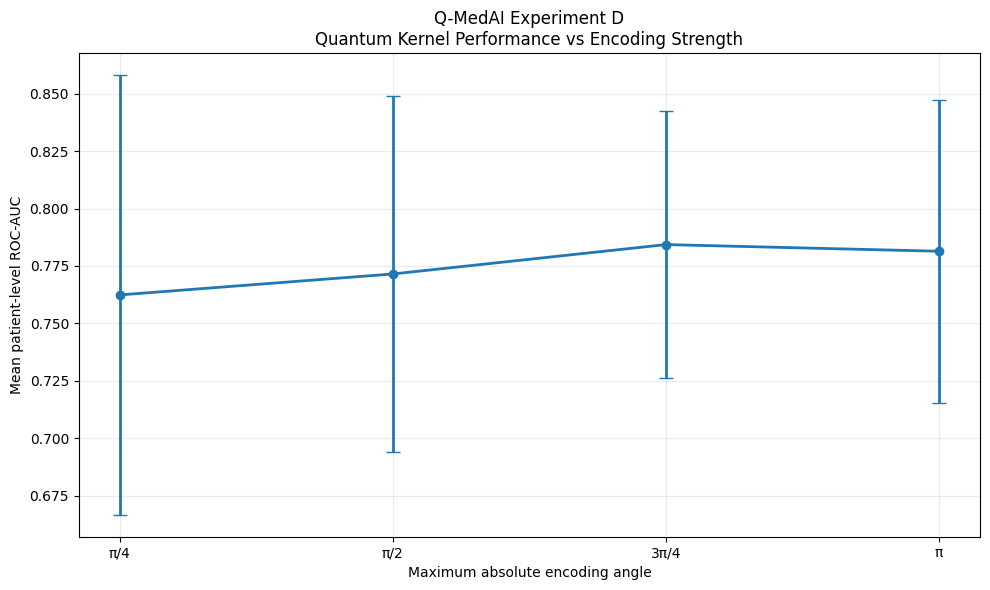

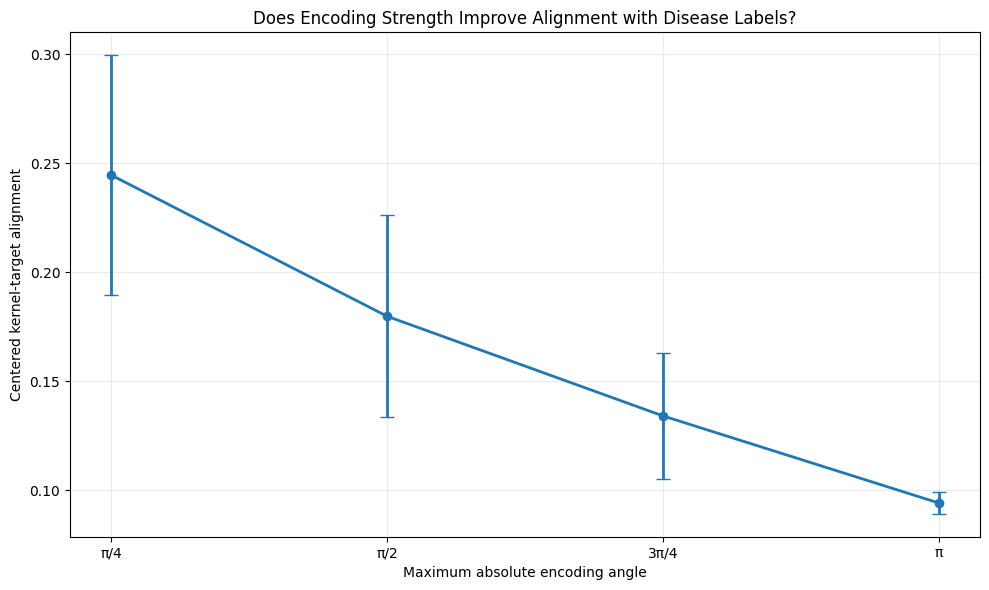

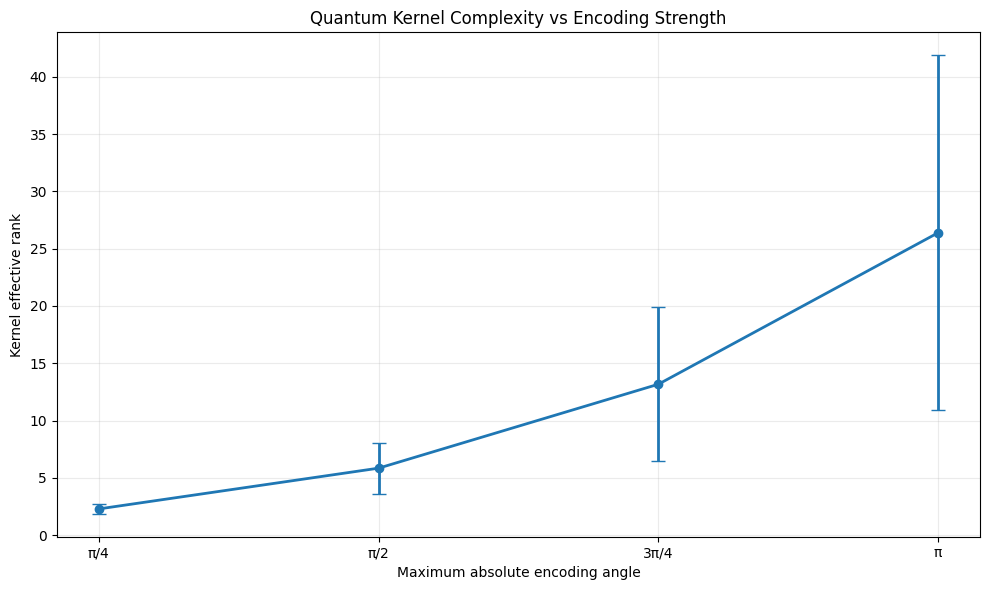

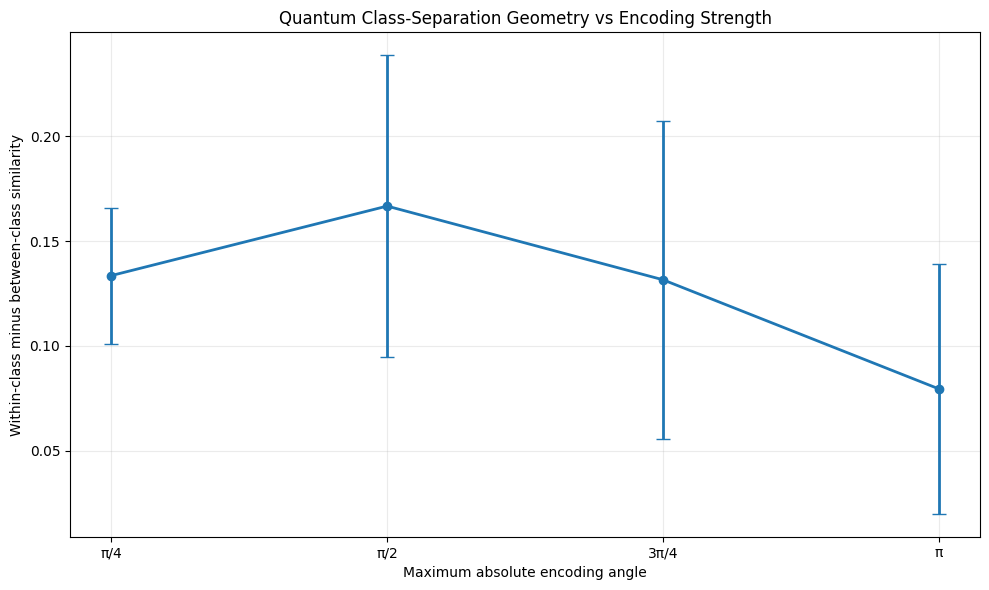


ENCODING SCALE DIAGNOSTIC

Range ±pi/4
  ROC-AUC       : 0.7624 ± 0.0958
  PR-AUC        : 0.8748
  KTA           : 0.2445
  Similarity gap: 0.1336
  Effective rank: 2.28
  Off-diagonal K: 0.7777

Range ±pi/2
  ROC-AUC       : 0.7715 ± 0.0775
  PR-AUC        : 0.8967
  KTA           : 0.1797
  Similarity gap: 0.1667
  Effective rank: 5.84
  Off-diagonal K: 0.5024

Range ±3pi/4
  ROC-AUC       : 0.7843 ± 0.0580
  PR-AUC        : 0.9040
  KTA           : 0.1340
  Similarity gap: 0.1316
  Effective rank: 13.16
  Off-diagonal K: 0.3262

Range ±pi
  ROC-AUC       : 0.7814 ± 0.0660
  PR-AUC        : 0.8964
  KTA           : 0.0941
  Similarity gap: 0.0795
  Effective rank: 26.38
  Off-diagonal K: 0.2051

EXPERIMENT D COMPLETE
Fold results : /kaggle/working/Q-MedAI-Parkinson/results/experiment_d/encoding_scale_cv_folds.csv
Summary      : /kaggle/working/Q-MedAI-Parkinson/results/experiment_d/encoding_scale_cv_summary.csv

IMPORTANT SCIENTIFIC RULE:
This experiment is exploratory feature-map 

In [25]:
# ============================================================
# CELL 19 — EXPERIMENT D
# QUANTUM ENCODING SCALE ABLATION
#
# WHY THIS EXPERIMENT?
# --------------------
# Experiment C showed:
#
# 4 qubits:
#   ROC-AUC ~0.703
#   effective rank ~9.9
#   similarity gap ~0.124
#
# 6 qubits:
#   ROC-AUC ~0.781
#   effective rank ~26.4
#   similarity gap ~0.080
#
# 8 qubits:
#   ROC-AUC ~0.766
#   effective rank ~51.7
#   similarity gap ~0.064
#
# As dimension increases, states become increasingly dispersed
# while class separation does not improve.
#
# Hypothesis:
# Mapping every selected feature across the full [-pi, pi]
# interval may be over-encoding the data.
#
# This cell keeps EVERYTHING fixed except encoding strength.
#
# IMPORTANT:
# This is an EXPLORATORY ABLATION.
# We must NOT choose the best range here and then pretend its
# CV score is an independent final-test result.
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif,
)
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
)
from sklearn.svm import SVC


# ============================================================
# 1. LOCK DIMENSION
# ============================================================

EXPD_QUBITS = 6

# Only the quantum angle magnitude changes.
EXPD_ANGLE_SCALES = {

    "pi/4":
        np.pi / 4,

    "pi/2":
        np.pi / 2,

    "3pi/4":
        3 * np.pi / 4,

    "pi":
        np.pi,
}


print("=" * 92)
print("Q-MedAI — EXPERIMENT D")
print("QUANTUM ENCODING SCALE ABLATION")
print("=" * 92)

print(
    "Fixed quantum dimension :",
    EXPD_QUBITS,
)

print(
    "Independent subjects    :",
    len(X_expc),
)

print(
    "Locked CV folds         :",
    len(EXPC_SPLITS),
)

print(
    "Encoding magnitudes     :",
    list(
        EXPD_ANGLE_SCALES.keys()
    ),
)

print()


# ============================================================
# 2. TRAIN-FOLD-ONLY PREPROCESSING WITH VARIABLE ANGLE RANGE
# ============================================================

def prepare_quantum_fold_with_scale(
    X_train_frame,
    X_test_frame,
    y_train_values,
    n_features,
    angle_magnitude,
):

    original_names = np.asarray(
        X_train_frame.columns,
        dtype=object,
    )

    # --------------------------------------------------------
    # IMPUTATION
    # --------------------------------------------------------

    imputer = SimpleImputer(
        strategy="median"
    )

    X_train_imp = (
        imputer.fit_transform(
            X_train_frame
        )
    )

    X_test_imp = (
        imputer.transform(
            X_test_frame
        )
    )

    # --------------------------------------------------------
    # REMOVE CONSTANTS
    # --------------------------------------------------------

    variance_filter = VarianceThreshold(
        threshold=0.0
    )

    X_train_var = (
        variance_filter.fit_transform(
            X_train_imp
        )
    )

    X_test_var = (
        variance_filter.transform(
            X_test_imp
        )
    )

    variance_names = (
        original_names[
            variance_filter.get_support()
        ]
    )

    # --------------------------------------------------------
    # STANDARDIZE
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = (
        scaler.fit_transform(
            X_train_var
        )
    )

    X_test_scaled = (
        scaler.transform(
            X_test_var
        )
    )

    # --------------------------------------------------------
    # SAME FEATURE-SELECTION METHOD AS EXPERIMENT C
    # --------------------------------------------------------

    selector = SelectKBest(
        score_func=f_classif,
        k=n_features,
    )

    X_train_selected = (
        selector.fit_transform(
            X_train_scaled,
            y_train_values,
        )
    )

    X_test_selected = (
        selector.transform(
            X_test_scaled
        )
    )

    selected_names = (
        variance_names[
            selector.get_support()
        ]
        .tolist()
    )

    # --------------------------------------------------------
    # THE ONLY VARIABLE UNDER STUDY
    # --------------------------------------------------------

    angle_scaler = MinMaxScaler(
        feature_range=(
            -angle_magnitude,
            angle_magnitude,
        ),
        clip=True,
    )

    X_train_quantum = (
        angle_scaler.fit_transform(
            X_train_selected
        )
    )

    X_test_quantum = (
        angle_scaler.transform(
            X_test_selected
        )
    )

    return (
        X_train_quantum,
        X_test_quantum,
        selected_names,
    )


# ============================================================
# 3. FIX THE CIRCUIT
# ============================================================

expd_state_circuit = (
    make_quantum_state_circuit(
        EXPD_QUBITS
    )
)


# ============================================================
# 4. RUN ABLATION
# ============================================================

expd_rows = []


for scale_name, magnitude in (
    EXPD_ANGLE_SCALES.items()
):

    print()
    print("=" * 92)

    print(
        f"ANGLE RANGE: "
        f"[-{scale_name}, +{scale_name}]"
    )

    print("=" * 92)

    for fold_number, (
        train_idx,
        test_idx,
    ) in enumerate(
        EXPC_SPLITS,
        start=1,
    ):

        total_start = (
            time.perf_counter()
        )

        # ----------------------------------------------------
        # PATIENT-LEVEL FOLD
        # ----------------------------------------------------

        X_train_fold = (
            X_expc.iloc[
                train_idx
            ]
        )

        X_test_fold = (
            X_expc.iloc[
                test_idx
            ]
        )

        y_train_fold = (
            y_expc.iloc[
                train_idx
            ]
            .to_numpy(
                dtype=int
            )
        )

        y_test_fold = (
            y_expc.iloc[
                test_idx
            ]
            .to_numpy(
                dtype=int
            )
        )

        # ----------------------------------------------------
        # PREPROCESS
        # ----------------------------------------------------

        (
            X_train_q,
            X_test_q,
            selected_names,
        ) = prepare_quantum_fold_with_scale(
            X_train_fold,
            X_test_fold,
            y_train_fold,
            EXPD_QUBITS,
            magnitude,
        )

        # ----------------------------------------------------
        # QUANTUM STATES
        # ----------------------------------------------------

        train_states = (
            compute_quantum_states(
                X_train_q,
                expd_state_circuit,
            )
        )

        test_states = (
            compute_quantum_states(
                X_test_q,
                expd_state_circuit,
            )
        )

        # ----------------------------------------------------
        # FIDELITY MATRICES
        # ----------------------------------------------------

        K_train = (
            fidelity_kernel(
                train_states,
                train_states,
            )
        )

        K_train = (
            K_train
            + K_train.T
        ) / 2.0

        np.fill_diagonal(
            K_train,
            1.0,
        )

        K_test = (
            fidelity_kernel(
                test_states,
                train_states,
            )
        )

        # ----------------------------------------------------
        # KERNEL DIAGNOSTICS — TRAIN DATA ONLY
        # ----------------------------------------------------

        kta = (
            kernel_target_alignment(
                K_train,
                y_train_fold,
            )
        )

        similarity = (
            class_similarity_statistics(
                K_train,
                y_train_fold,
            )
        )

        (
            eigenvalues,
            normalized_eigenvalues,
            effective_rank,
        ) = (
            kernel_spectrum_statistics(
                K_train
            )
        )

        upper_mask = (
            np.triu(
                np.ones_like(
                    K_train,
                    dtype=bool,
                ),
                k=1,
            )
        )

        off_diagonal = (
            K_train[
                upper_mask
            ]
        )

        offdiag_mean = float(
            np.mean(
                off_diagonal
            )
        )

        offdiag_std = float(
            np.std(
                off_diagonal
            )
        )

        # ----------------------------------------------------
        # QSVM
        # ----------------------------------------------------

        model = SVC(
            kernel="precomputed",
            random_state=EXPC_RANDOM_SEED,
        )

        model.fit(
            K_train,
            y_train_fold,
        )

        y_pred = (
            model.predict(
                K_test
            )
        )

        y_score = (
            model.decision_function(
                K_test
            )
        )

        y_score = np.asarray(
            y_score,
            dtype=float,
        )

        metrics = (
            quantum_expc_metrics(
                y_test_fold,
                y_pred,
                y_score,
            )
        )

        total_seconds = (
            time.perf_counter()
            - total_start
        )

        expd_rows.append(
            {

                "Angle Scale":
                    scale_name,

                "Angle Magnitude":
                    float(
                        magnitude
                    ),

                "Qubits":
                    EXPD_QUBITS,

                "Fold":
                    fold_number,

                "ROC-AUC":
                    metrics[
                        "ROC-AUC"
                    ],

                "PR-AUC":
                    metrics[
                        "PR-AUC"
                    ],

                "Sensitivity":
                    metrics[
                        "Sensitivity"
                    ],

                "Specificity":
                    metrics[
                        "Specificity"
                    ],

                "F1":
                    metrics[
                        "F1"
                    ],

                "Balanced Accuracy":
                    metrics[
                        "Balanced Accuracy"
                    ],

                "False Negatives":
                    metrics[
                        "False Negatives"
                    ],

                "False Positives":
                    metrics[
                        "False Positives"
                    ],

                "Kernel-Target Alignment":
                    kta,

                "Within-Class Similarity":
                    similarity[
                        "Within-Class Similarity"
                    ],

                "Between-Class Similarity":
                    similarity[
                        "Between-Class Similarity"
                    ],

                "Similarity Gap":
                    similarity[
                        "Similarity Gap"
                    ],

                "Effective Rank":
                    effective_rank,

                "Off-Diagonal Mean":
                    offdiag_mean,

                "Off-Diagonal Std":
                    offdiag_std,

                "Runtime (s)":
                    total_seconds,
            }
        )

        print(
            f"Fold {fold_number} | "
            f"AUC={metrics['ROC-AUC']:.4f} | "
            f"PR={metrics['PR-AUC']:.4f} | "
            f"Sens={metrics['Sensitivity']:.4f} | "
            f"Spec={metrics['Specificity']:.4f} | "
            f"KTA={kta:.4f} | "
            f"Gap={similarity['Similarity Gap']:.4f} | "
            f"ERank={effective_rank:.2f} | "
            f"OffDiag={offdiag_mean:.4f}"
        )


# ============================================================
# 5. RAW RESULTS
# ============================================================

expd_folds = pd.DataFrame(
    expd_rows
)


print()
print("=" * 92)
print("EXPERIMENT D — FOLD RESULTS")
print("=" * 92)


display(
    expd_folds[
        [
            "Angle Scale",
            "Fold",
            "ROC-AUC",
            "PR-AUC",
            "Sensitivity",
            "Specificity",
            "Balanced Accuracy",
            "Kernel-Target Alignment",
            "Within-Class Similarity",
            "Between-Class Similarity",
            "Similarity Gap",
            "Effective Rank",
            "Off-Diagonal Mean",
        ]
    ].round(
        4
    )
)


# ============================================================
# 6. MEAN ± STD SUMMARY
# ============================================================

metrics_to_summarize = [

    "ROC-AUC",
    "PR-AUC",
    "Sensitivity",
    "Specificity",
    "F1",
    "Balanced Accuracy",

    "Kernel-Target Alignment",

    "Within-Class Similarity",
    "Between-Class Similarity",
    "Similarity Gap",

    "Effective Rank",

    "Off-Diagonal Mean",

    "Runtime (s)",
]


summary_rows = []


for (
    scale_name,
    angle_magnitude,
), group in (
    expd_folds.groupby(
        [
            "Angle Scale",
            "Angle Magnitude",
        ],
        sort=False,
    )
):

    row = {

        "Angle Scale":
            scale_name,

        "Angle Magnitude":
            angle_magnitude,
    }

    for metric in (
        metrics_to_summarize
    ):

        row[
            f"{metric} Mean"
        ] = float(
            group[
                metric
            ]
            .mean()
        )

        row[
            f"{metric} Std"
        ] = float(
            group[
                metric
            ]
            .std(
                ddof=1
            )
        )

    summary_rows.append(
        row
    )


expd_summary = (
    pd.DataFrame(
        summary_rows
    )
    .sort_values(
        "Angle Magnitude"
    )
    .reset_index(
        drop=True
    )
)


print()
print("=" * 92)
print(
    "EXPERIMENT D — "
    "ENCODING SCALE SUMMARY"
)
print("=" * 92)


display(
    expd_summary.round(
        4
    )
)


# ============================================================
# 7. BASELINE FROM EXPERIMENT C
# ============================================================

baseline_6 = (
    expc_same_dimension_comparison[
        expc_same_dimension_comparison[
            "Features"
        ] == 6
    ]
    .copy()
)


print()
print("=" * 92)
print("REFERENCE — 6-FEATURE CLASSICAL MODELS")
print("=" * 92)


display(
    baseline_6[
        [
            "Model",
            "ROC-AUC Mean",
            "PR-AUC Mean",
            "Sensitivity Mean",
            "Specificity Mean",
            "Balanced Accuracy Mean",
        ]
    ].round(
        4
    )
)


# ============================================================
# 8. PLOT — ROC-AUC VS ENCODING STRENGTH
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.errorbar(
    expd_summary[
        "Angle Magnitude"
    ],
    expd_summary[
        "ROC-AUC Mean"
    ],
    yerr=expd_summary[
        "ROC-AUC Std"
    ],
    marker="o",
    capsize=5,
    linewidth=2,
)

plt.xticks(
    [
        np.pi / 4,
        np.pi / 2,
        3 * np.pi / 4,
        np.pi,
    ],
    [
        "π/4",
        "π/2",
        "3π/4",
        "π",
    ],
)

plt.xlabel(
    "Maximum absolute encoding angle"
)

plt.ylabel(
    "Mean patient-level ROC-AUC"
)

plt.title(
    "Q-MedAI Experiment D\n"
    "Quantum Kernel Performance vs Encoding Strength"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


EXPD_RESULTS_DIR = (
    RESULTS_DIR
    / "experiment_d"
)

EXPD_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


auc_plot_path = (
    EXPD_RESULTS_DIR
    / "encoding_scale_roc_auc.png"
)

plt.savefig(
    auc_plot_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 9. PLOT — KERNEL-TARGET ALIGNMENT
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.errorbar(
    expd_summary[
        "Angle Magnitude"
    ],
    expd_summary[
        "Kernel-Target Alignment Mean"
    ],
    yerr=expd_summary[
        "Kernel-Target Alignment Std"
    ],
    marker="o",
    capsize=5,
    linewidth=2,
)

plt.xticks(
    [
        np.pi / 4,
        np.pi / 2,
        3 * np.pi / 4,
        np.pi,
    ],
    [
        "π/4",
        "π/2",
        "3π/4",
        "π",
    ],
)

plt.xlabel(
    "Maximum absolute encoding angle"
)

plt.ylabel(
    "Centered kernel-target alignment"
)

plt.title(
    "Does Encoding Strength Improve "
    "Alignment with Disease Labels?"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


kta_plot_path = (
    EXPD_RESULTS_DIR
    / "encoding_scale_kta.png"
)

plt.savefig(
    kta_plot_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 10. PLOT — EFFECTIVE RANK
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.errorbar(
    expd_summary[
        "Angle Magnitude"
    ],
    expd_summary[
        "Effective Rank Mean"
    ],
    yerr=expd_summary[
        "Effective Rank Std"
    ],
    marker="o",
    capsize=5,
    linewidth=2,
)

plt.xticks(
    [
        np.pi / 4,
        np.pi / 2,
        3 * np.pi / 4,
        np.pi,
    ],
    [
        "π/4",
        "π/2",
        "3π/4",
        "π",
    ],
)

plt.xlabel(
    "Maximum absolute encoding angle"
)

plt.ylabel(
    "Kernel effective rank"
)

plt.title(
    "Quantum Kernel Complexity vs Encoding Strength"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


rank_plot_path = (
    EXPD_RESULTS_DIR
    / "encoding_scale_effective_rank.png"
)

plt.savefig(
    rank_plot_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 11. PLOT — SIMILARITY GAP
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.errorbar(
    expd_summary[
        "Angle Magnitude"
    ],
    expd_summary[
        "Similarity Gap Mean"
    ],
    yerr=expd_summary[
        "Similarity Gap Std"
    ],
    marker="o",
    capsize=5,
    linewidth=2,
)

plt.xticks(
    [
        np.pi / 4,
        np.pi / 2,
        3 * np.pi / 4,
        np.pi,
    ],
    [
        "π/4",
        "π/2",
        "3π/4",
        "π",
    ],
)

plt.xlabel(
    "Maximum absolute encoding angle"
)

plt.ylabel(
    "Within-class minus between-class similarity"
)

plt.title(
    "Quantum Class-Separation Geometry "
    "vs Encoding Strength"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


gap_plot_path = (
    EXPD_RESULTS_DIR
    / "encoding_scale_similarity_gap.png"
)

plt.savefig(
    gap_plot_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 12. SAVE
# ============================================================

fold_path = (
    EXPD_RESULTS_DIR
    / "encoding_scale_cv_folds.csv"
)

summary_path = (
    EXPD_RESULTS_DIR
    / "encoding_scale_cv_summary.csv"
)


expd_folds.to_csv(
    fold_path,
    index=False,
)

expd_summary.to_csv(
    summary_path,
    index=False,
)


# ============================================================
# 13. AUTOMATIC EXPLORATORY DIAGNOSTIC
# ============================================================

print()
print("=" * 92)
print("ENCODING SCALE DIAGNOSTIC")
print("=" * 92)


for _, row in (
    expd_summary.iterrows()
):

    print()

    print(
        f"Range ±{row['Angle Scale']}"
    )

    print(
        "  ROC-AUC       : "
        f"{row['ROC-AUC Mean']:.4f} "
        f"± "
        f"{row['ROC-AUC Std']:.4f}"
    )

    print(
        "  PR-AUC        : "
        f"{row['PR-AUC Mean']:.4f}"
    )

    print(
        "  KTA           : "
        f"{row['Kernel-Target Alignment Mean']:.4f}"
    )

    print(
        "  Similarity gap: "
        f"{row['Similarity Gap Mean']:.4f}"
    )

    print(
        "  Effective rank: "
        f"{row['Effective Rank Mean']:.2f}"
    )

    print(
        "  Off-diagonal K: "
        f"{row['Off-Diagonal Mean Mean']:.4f}"
    )


print()
print("=" * 92)
print("EXPERIMENT D COMPLETE")
print("=" * 92)

print(
    "Fold results :",
    fold_path,
)

print(
    "Summary      :",
    summary_path,
)

print()
print(
    "IMPORTANT SCIENTIFIC RULE:"
)

print(
    "This experiment is exploratory feature-map analysis."
)

print(
    "If one angle scale looks best, that scale must later "
    "be validated using nested CV or a separate locked test "
    "set before being presented as an improved model."
)